# Agent-Based Modelling and LLM Adoption in the Literature
### A visual analysis of the three-stage LLM-screened corpus (322,742 records)

This notebook visualises the corpus produced by `LLM/LLM_filter_and_topic.py`, a three-stage
Large-Language-Model pipeline that screened **322,742** bibliographic records
(Web of Science / PubMed / DBLP) with **Llama-4-Scout-17B-16E-Instruct**:

| Stage | Prompt | Decision | Output fields |
|---|---|---|---|
| 1 | `ABM_SYSTEM_PROMPT` | Is the paper genuinely an **agent-based model (ABM)**? | `is_abm`, `abm_evidence`, `triggered_keywords`, `abm_methodology`, `topic_category`, `confidence` |
| 2 | `LLM_SYSTEM_PROMPT` | Does the paper actually **use an LLM**? | `has_llm`, `llm_evidence`, `llm_role`, `confidence` |
| 3 | `TOPIC_SYSTEM_PROMPT` | Granular domain, agents, scale (ABM papers only) | `primary_domain`, `secondary_topics`, `agent_types`, `simulation_scale`, `topic_keywords` |

Because stages 2 and 3 only run on stage-1 positives, every downstream visualisation is
conditioned on the ABM-positive subset (`n = 88,954`).

### What this notebook answers

1. **Corpus composition and growth** — how the harvested ABM literature distributes over time.
2. **ABM screening outcome** — how much of the retrieved corpus is genuinely agent-based.
3. **LLM adoption trend** — absolute counts and adoption share, by year.
4. **Functional roles of LLMs** — what the models were actually used for.
5. **Topic structure** — application domains, agent types, simulation scales, methodology, and co-occurrence.

### Data-provenance notes carried through every figure

* The file is **1.83 GB of JSONL**; it is streamed once into a compact Parquet cache (0.42 GB in RAM).
* `llama_abm_is_abm = -1` and `llama_llm_has_llm = -1` mark **model/parse failures**, not negatives.
  They are reported separately and excluded from rate denominators.
* `llama_topic_error` is null for non-ABM records by design; only 6 ABM-positive records carry a topic-stage error.
* **All time series end at 2025.** The harvest ran in September 2026, so 2026 is an incomplete calendar
  year and is excluded rather than shown as a partial point.

## 1. Setup

Imports, plotting style, helper functions and output locations. Figures are written to `figures/`
as 200-dpi PNGs and also rendered inline.

In [1]:
from __future__ import annotations

import gzip
import json
import re
import textwrap
from collections import Counter, defaultdict
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch
from IPython.display import HTML, Markdown, display

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

# ---------------------------------------------------------------- style
sns.set_theme(style="ticks", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "figure.facecolor": "white",
    "axes.titlesize": 12.5,
    "axes.titleweight": "bold",
    "axes.labelsize": 10.5,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.6,
    "legend.frameon": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

C = {
    "non_abm":  "#9AAABA",
    "abm":      "#3E6D9C",
    "abm_dark": "#2A4A6B",
    "llm":      "#D1613B",
    "llm_dark": "#9C3F21",
    "accent":   "#4C9F70",
    "grey":     "#8A94A0",
    "error":    "#B08AA8",
}
BUCKET_COLORS = ["#2A4A6B", "#3E6D9C", "#6699CC", "#6D9BC8", "#4C9F70",
                 "#5FA97F", "#D1613B", "#D0824F", "#B08D22", "#8B79AE", "#9AAABA"]
ROLE_COLORS = ["#2A4A6B", "#3E6D9C", "#4C9F70", "#D1613B", "#B08D22",
               "#8B79AE", "#5B8FC4", "#D0824F", "#A46E93", "#9AAABA"]

BASE = Path(r"D:\Literature-Research-Agent")
SRC_JSONL = BASE / "LLM" / "abm_filter_corpus_three_stage.jsonl"
CACHE_DIR = BASE / "data_cache"
CACHE_PARQUET = CACHE_DIR / "abm_llm_corpus_cache_v9.parquet"
AUTHOR_SIDECAR = CACHE_DIR / "author_meta.jsonl.gz"
FIG_DIR = BASE / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
COMBINED_DIR = FIG_DIR / "_combined"   # composite previews only


# ---------------------------------------------------------------- publication output
LAST_YEAR = 2025          # all time series stop here; 2026 is a partial harvest year

PANEL_NAMES = {
    "01_corpus_growth": "fig01_corpus_growth",
    "02_abm_share_and_cagr": "fig02_abm_share",
    "03_abm_screening": "fig03_screening",
    "04_methodology_and_sources": "fig04_methodology_sources",
    "05_llm_adoption_trend": "fig05_llm_adoption",
    "06_llm_takeoff": "fig06_llm_takeoff",
    "07_screening_funnel_and_confidence": "fig07_funnel_confidence",
    "08_llm_roles": "fig08_llm_roles",
    "09_role_evolution": "fig09_role_evolution",
    "10_primary_domains": "fig10_domains",
    "11_domain_composition_over_time": "fig11_domain_over_time",
    "12_agent_types": "fig12_agent_types",
    "13_simulation_scale": "fig13_simulation_scale",
    "14_topic_keywords_and_trends": "fig14_topic_keywords",
    "15_domain_llm_penetration": "fig15_domain_penetration",
    "16_domain_role_heatmap": "fig16_domain_role",
    "17_keyword_cooccurrence": "fig17_keyword_cooccurrence",
    "18_emerging_topics": "fig18_emerging_topics",
    "19_summary_dashboard": "fig19_dashboard",
    "20_concept_cloud": "fig20_concept_cloud",
    "34_llm_role_composition": "34_llm_role_composition",
    "35_llm_agent_families": "35_llm_agent_families",
    "36_llm_vocabulary_shift": "36_llm_vocabulary_shift",
    "37_llm_content_shifts": "37_llm_content_shifts",
    "34_llm_role_composition": "34_llm_role_composition",
    "35_llm_agent_families": "35_llm_agent_families",
    "36_llm_vocabulary_shift": "36_llm_vocabulary_shift",
    "37_llm_content_shifts": "37_llm_content_shifts",
    "28_llm_effect_forest": "28_llm_effect_forest",
    "29_llm_effect_by_stratum": "29_llm_effect_by_stratum",
    "30_llm_effect_authors_distribution": "30_llm_effect_authors_distribution",
    "31_llm_effect_slopes": "31_llm_effect_slopes",
    "32_llm_effect_by_year": "32_llm_effect_by_year",
    "33_llm_effect_summary": "33_llm_effect_summary",
    "28_llm_effect_forest": "28_llm_effect_forest",
    "29_llm_effect_by_stratum": "29_llm_effect_by_stratum",
    "30_llm_effect_authors_distribution": "30_llm_effect_authors_distribution",
    "31_llm_effect_slopes": "31_llm_effect_slopes",
    "32_llm_effect_by_year": "32_llm_effect_by_year",
    "33_llm_effect_summary": "33_llm_effect_summary",
    "28_llm_effect_forest": "28_llm_effect_forest",
    "29_llm_effect_by_stratum": "29_llm_effect_by_stratum",
    "30_llm_effect_authors_distribution": "30_llm_effect_authors_distribution",
    "31_llm_effect_slopes": "31_llm_effect_slopes",
    "32_llm_effect_by_year": "32_llm_effect_by_year",
    "33_llm_effect_summary": "33_llm_effect_summary",
    "28_llm_effect_forest": "28_llm_effect_forest",
    "29_llm_effect_by_stratum": "29_llm_effect_by_stratum",
    "30_llm_effect_authors_distribution": "30_llm_effect_authors_distribution",
    "31_llm_effect_slopes": "31_llm_effect_slopes",
    "32_llm_effect_by_year": "32_llm_effect_by_year",
    "33_llm_effect_summary": "33_llm_effect_summary",
    "28_llm_effect_forest": "28_llm_effect_forest",
    "29_llm_effect_by_stratum": "29_llm_effect_by_stratum",
    "30_llm_effect_authors_distribution": "30_llm_effect_authors_distribution",
    "31_llm_effect_slopes": "31_llm_effect_slopes",
    "32_llm_effect_by_year": "32_llm_effect_by_year",
    "33_llm_effect_summary": "33_llm_effect_summary",
    "21_subtopics_and_llm_lift": "fig21_subtopics_lift",
    "22_subtopic_momentum": "fig22_subtopic_momentum",
    "23_methodology_over_time": "fig23_methodology_families",
    "24_authorship_structure": "fig24_authorship",
    "25_country_composition": "fig25_countries",
    "26_country_llm_adoption": "fig26_country_llm",
    "27_institutions": "fig27_institutions",
    "31_domain_collaboration": "fig31_domain_collaboration",
    "fp01_false_positive_trend": "fp01_fp_trend",
    "fp02_keyword_precision": "fp02_keyword_precision",
    "fp03_semantic_families": "fp03_semantic_families",
    "fp04_keyword_drift": "fp04_keyword_drift",
    "fp05_multi_agent_case_study": "fp05_multi_agent_case",
    "fp06_abstract_drift": "fp06_abstract_drift",
    "fp07_macro_theme_shift": "fp07_macro_themes",
    "fp08_model_failures": "fp08_model_failures",
}


def tidy_title(ax, scale=1.0, limit=62):
    """图内只保留面板字母（A/B/C…）；完整标题由正文下方的题注承担。

    单面板图本来就没有字母，标题整条去掉——图内不再重复题注已经说过的话。
    字母必须保留：正文以「图 16 的 A 面板」这种方式引用，图内需要能对上。
    """
    t = ax.get_title().replace("\n", " ").strip()
    m = re.match(r"^([A-F])[\.\s]", t)
    if m:
        ax.set_title(m.group(1), fontsize=11, fontweight="bold", loc="left")
    else:
        ax.set_title("")


# ---------------------------------------------------------------- readability helpers
# Each of these exists because the figure audit (tools/audit_figures.py) found the defect it prevents.
# Both notebooks carry the same block, so a fix lands everywhere instead of in one panel.

def lum_of(colour):
    """Relative luminance of a colour, 0 (black) to 1 (white)."""
    r, g, b = matplotlib.colors.to_rgb(colour)
    return 0.2126 * r + 0.7152 * g + 0.0722 * b


def text_on(colour, light="white", dark="#22303C", threshold=0.62):
    """Pick the readable text colour for a background.

    Choosing "white if the value > 25" is what put white percentages on the pale end of the Blues ramp:
    the rule keyed on the value, and the value says nothing about how light the segment is.
    """
    return light if lum_of(colour) < threshold else dark


def label_line_ends(ax, entries, fontsize=7.0, x_off=6.0, gap_px=2.2, min_lead_px=4.0):
    """Draw de-collided end-of-line series labels.

    `entries` is a sequence of (x, y, text, colour). Series that finish close together print their names
    on top of each other otherwise; the labels are separated in display space, keeping their vertical
    order, pulled back inside the axes, and any label that had to move gets a hairline leader.
    """
    fig = ax.figure
    fig.canvas.draw()
    r = fig.canvas.get_renderer()
    row = fontsize * fig.dpi / 72.0 * 1.45
    need = max(row, fontsize * fig.dpi / 72.0 + gap_px)
    axbb = ax.get_window_extent(r)
    recs = []
    for x, y, text, colour in entries:
        yd = ax.transData.transform((x, y))[1]
        recs.append({"x": x, "y": y, "yd": yd, "ly": yd, "text": text, "colour": colour})
    recs.sort(key=lambda d: d["ly"])
    for i in range(1, len(recs)):
        if recs[i]["ly"] - recs[i - 1]["ly"] < need:
            recs[i]["ly"] = recs[i - 1]["ly"] + need
    shift = recs[-1]["ly"] - (axbb.y1 - row / 2)
    if shift > 0:
        for d in recs:
            d["ly"] -= shift
    shift = (axbb.y0 + row / 2) - recs[0]["ly"]
    if shift > 0:
        for d in recs:
            d["ly"] += shift
    inv = ax.transData.inverted()
    moved = 0
    for d in recs:
        y_lab = inv.transform((0, d["ly"]))[1]
        if abs(d["ly"] - d["yd"]) > min_lead_px:
            moved += 1
            ax.plot([d["x"], d["x"]], [d["y"], y_lab], color=d["colour"], lw=0.7, alpha=0.75,
                    zorder=2, clip_on=False)
        _t = ax.annotate(d["text"], xy=(d["x"], y_lab), xytext=(x_off, 0),
                         textcoords="offset points", ha="left", va="center", fontsize=fontsize,
                         color=d["colour"], zorder=6, annotation_clip=False)
        # the column is deliberate: moving one label off its row would break the leader-line pairing
        _t._pinned = True
    return moved


def label_points(ax, entries, fontsize=7.0, radii=range(0, 45, 3), dirs=12, pad=1.5):
    """Place one label per point, walking outwards until the box touches nothing.

    A fixed (4, 4) offset collides wherever points cluster, which is what happened to twenty country
    names on a log axis. Entries are placed in the order given, so pass the most important ones first.
    """
    fig = ax.figure
    fig.canvas.draw()
    r = fig.canvas.get_renderer()
    placed = []
    for x, y, text, colour in entries:
        done = False
        for rad in radii:
            for k in range(dirs):
                ang = 2 * np.pi * k / dirs
                t = ax.annotate(text, xy=(x, y), xytext=(4 + rad * np.cos(ang), 4 + rad * np.sin(ang)),
                                textcoords="offset points", fontsize=fontsize, color=colour,
                                va="center", ha="left", zorder=6)
                bb = t.get_window_extent(renderer=r)
                box = (bb.x0 - pad, bb.y0 - pad, bb.x1 + pad, bb.y1 + pad)
                if not any(box[0] < p[2] and box[2] > p[0] and box[1] < p[3] and box[3] > p[1]
                           for p in placed):
                    placed.append(box)
                    done = True
                    break
                t.remove()
            if done:
                break
    return len(placed)


def fit_label_margin(ax, pad_pt=4.0, passes=8):
    """Widen the x-limit so labels drawn to the right of the data still fit inside the axes.

    Iterated, because widening xlim moves the anchor left by less than the width added - the mapping is
    (x - x0) / (x1 - x0), so a single correction removes only part of the overflow. Without this the
    longest right-hand label of the bump chart runs into the neighbouring panel.
    """
    fig = ax.figure
    for _ in range(passes):
        fig.canvas.draw()
        r = fig.canvas.get_renderer()
        axbb = ax.get_window_extent(r)
        need = 0.0
        for t in ax.texts:
            try:
                need = max(need, t.get_window_extent(r).x1 - axbb.x1)
            except Exception:
                continue
        if need <= 0.5:
            return need
        x0, x1 = ax.get_xlim()
        ax.set_xlim(x0, x1 + (need + pad_pt * fig.dpi / 72.0) * (x1 - x0) / axbb.width)
    return need


def declutter_axes(ax, pad=1.6, radii=range(0, 90, 2), dirs=18):
    """Move only those anchored labels that collide, as late as possible.

    Text keeps its point size while the data-to-display mapping changes around it, so a label arrangement
    can be undone by anything that resizes the axes afterwards - which save_panels() does deliberately.
    Labels that are already clear are left exactly where they are, so deliberate arrangements such as the
    end-of-line label columns survive untouched; only colliding annotations, the ones anchored to a data
    point with a point offset, walk outwards to a free slot.
    """
    fig = ax.figure
    fig.canvas.draw()
    r = fig.canvas.get_renderer()
    axbb = ax.get_window_extent(r)

    def box_of(t, extra=0.0):
        bb = t.get_window_extent(renderer=r)
        return (bb.x0 - pad - extra, bb.y0 - pad - extra, bb.x1 + pad + extra, bb.y1 + pad + extra)

    def hits(b, others):
        return any(b[0] < p[2] and b[2] > p[0] and b[1] < p[3] and b[3] > p[1] for p in others)

    placed, movable = [], []
    for t in ax.findobj(matplotlib.text.Text):
        if not t.get_visible() or not t.get_text().strip():
            continue
        try:
            bb = t.get_window_extent(renderer=r)
        except Exception:
            continue
        if bb.width <= 0.5 or bb.height <= 0.5:
            continue
        pinned = getattr(t, "_pinned", False)
        if isinstance(t, matplotlib.text.Annotation) and hasattr(t, "xyann") and not pinned:
            movable.append(t)
        else:
            placed.append((bb.x0 - pad, bb.y0 - pad, bb.x1 + pad, bb.y1 + pad))
    moved = 0
    for t in movable:
        here = box_of(t)
        if not hits(here, placed):
            placed.append(here)
            continue
        base = tuple(t.xyann)
        found = None
        for rad in radii:
            for k in range(dirs):
                ang = 2 * np.pi * k / dirs
                t.xyann = (base[0] + rad * np.cos(ang), base[1] + rad * np.sin(ang))
                cand = box_of(t)
                inside = (cand[0] >= axbb.x0 and cand[2] <= axbb.x1
                          and cand[1] >= axbb.y0 and cand[3] <= axbb.y1)
                if inside and not hits(cand, placed):
                    found = cand
                    break
            if found is not None:
                break
        if found is None:                # nothing clean inside the axes: keep the original offset
            t.xyann = base
            placed.append(here)
        else:
            placed.append(found)
            moved += 1
    return moved


TARGET_PANEL_IN = (7.2, 5.0)      # target size of a saved panel, in inches


def _save_with_retry(fig, path, **kw):
    """savefig that tolerates transient Windows sharing violations (Errno 22 / 13)."""
    import time as _t
    last = None
    for _ in range(6):
        try:
            fig.savefig(path, **kw)
            return True
        except OSError as exc:
            last = exc
            _t.sleep(0.4)
    print(f"    [warn] could not write {path}: {last}")
    return False


def save_panels(fig, name):
    """Save every panel of `fig` as its own PNG and PDF at a publication size.

    Two things matter here and both were learned the hard way:

    * sibling axes are hidden but NOT removed - removing an axes invalidates it for the
      remaining panels, so later saves fail with `NoneType.dpi_scale_trans`;
    * the canvas is calibrated in two passes against the measured PNG size, because
      savefig(bbox_inches="tight") crops to the drawn extent and the resulting size is not
      simply the figure size divided by the panel count.
    """
    # A twinx() pair is ONE panel, not two. `fig.axes` lists both halves, so enumerating it
    # directly saved the bars with the twin hidden and then the twin with the bars hidden - a
    # dual-axis figure came out as two mutilated single-axis files. Axes are grouped by their
    # shared-x family, which is exactly what twinx() joins and what ordinary subplot panels
    # never share, so unrelated panels stay separate.
    _all = [a for a in fig.axes if a.get_label() != "<colorbar>"]
    _seen, panels = set(), []
    for _a in _all:
        _sibs = [s for s in _a.get_shared_x_axes().get_siblings(_a) if s in _all]
        _key = frozenset(id(s) for s in _sibs)
        if _key in _seen:
            continue
        _seen.add(_key)
        panels.append((_a, _sibs))
    saved = []
    for i, (ax, _group) in enumerate(panels):
        for other in fig.axes:
            other.set_visible(other in _group)
        if fig._suptitle is not None:
            fig._suptitle.set_visible(False)
        try:
            fig.set_layout_engine("none")
        except Exception:
            pass
        fig.set_size_inches(TARGET_PANEL_IN[0] * 1.32, TARGET_PANEL_IN[1] * 1.28)
        ax.set_position([0.15, 0.17, 0.82, 0.78])
        tidy_title(ax)
        for t in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
            t.set_fontsize(min(t.get_fontsize() * 1.15, 12.5))
        ax.xaxis.label.set_fontsize(min(ax.xaxis.label.get_fontsize() * 1.15, 12))
        ax.yaxis.label.set_fontsize(min(ax.yaxis.label.get_fontsize() * 1.15, 12))
        leg = ax.get_legend()
        if leg is not None:
            for t in leg.get_texts():
                t.set_fontsize(min(t.get_fontsize() * 1.12, 10))
        stem = f"{name}_{chr(ord('a') + i)}"
        path = FIG_DIR / f"{stem}.png"
        for _ in range(3):
            # the size calibration below changes the data-to-display mapping, so labels the
            # geometry pushed into something else are re-placed here, once the geometry is final
            declutter_axes(ax)
            _save_with_retry(fig, path, bbox_inches="tight")
            try:
                from PIL import Image
                with Image.open(path) as im:
                    w, h = im.size
            except Exception:
                break
            cur_w, cur_h = w / 200.0, h / 200.0
            sx = TARGET_PANEL_IN[0] / cur_w
            sy = TARGET_PANEL_IN[1] / cur_h
            if abs(sx - 1) < 0.04 and abs(sy - 1) < 0.04:
                break
            sw, sh = fig.get_size_inches()
            fig.set_size_inches(sw * sx, sh * sy)
            ax.set_position([0.15, 0.17, 0.82, 0.78])
        declutter_axes(ax)
        _save_with_retry(fig, FIG_DIR / f"{stem}.pdf")
        saved.append(stem)
    plt.close(fig)
    print("    -> " + ", ".join(saved))
    return saved


FOCUS_YEARS = (1990, 2025)           # window used for share-of-year panels
COMPLETE_YEARS = (1990, 2025)        # last complete calendar year
COUNTRY_NAMES = {
    "US": "United States", "CN": "China", "GB": "United Kingdom", "DE": "Germany",
    "CA": "Canada", "AU": "Australia", "IN": "India", "FR": "France", "IT": "Italy",
    "ES": "Spain", "JP": "Japan", "NL": "Netherlands", "BR": "Brazil", "KR": "South Korea",
    "IR": "Iran", "RU": "Russia", "SE": "Sweden", "CH": "Switzerland", "TW": "Taiwan",
    "PL": "Poland", "TR": "Turkey", "SA": "Saudi Arabia", "BE": "Belgium", "AT": "Austria",
    "IL": "Israel", "DK": "Denmark", "SG": "Singapore", "MY": "Malaysia", "PT": "Portugal",
    "NO": "Norway", "FI": "Finland", "GR": "Greece", "MX": "Mexico", "ZA": "South Africa",
    "IE": "Ireland", "NZ": "New Zealand", "CZ": "Czechia", "EG": "Egypt", "PK": "Pakistan",
    "AR": "Argentina", "CL": "Chile", "CO": "Colombia", "TH": "Thailand", "VN": "Vietnam",
    "ID": "Indonesia", "NG": "Nigeria", "HU": "Hungary", "RO": "Romania", "UA": "Ukraine",
    "RS": "Serbia", "HR": "Croatia", "SI": "Slovenia", "SK": "Slovakia", "BG": "Bulgaria",
    "EE": "Estonia", "LT": "Lithuania", "LV": "Latvia", "IS": "Iceland", "LU": "Luxembourg",
}


# Special administrative regions and Taiwan are reported as part of China.
REGION_OF_CHINA = {"TW": "Taiwan (China)", "HK": "Hong Kong (China)", "MO": "Macao (China)"}


def country_label(code: str) -> str:
    """ISO-2 country code -> readable name, falling back to the code itself."""
    key = str(code).strip().upper()
    if key in REGION_OF_CHINA:
        return REGION_OF_CHINA[key]
    return COUNTRY_NAMES.get(key, key)

_fig_n = 0


def save(fig, name: str, caption: str | None = None):
    """
    Display ig and write every panel as its own file.

    The composite figure is also written, but into a scratch folder: the figures directory is
    reserved for the per-panel files that are actually placed in the manuscript.
    """
    global _fig_n
    _fig_n += 1
    COMBINED_DIR.mkdir(parents=True, exist_ok=True)
    path = COMBINED_DIR / f"{name}.png"
    _save_with_retry(fig, path)
    # captions are deliberately not drawn: the figures carry no explanatory small print
    plt.show()
    plt.close(fig)
    panels = save_panels(fig, PANEL_NAMES.get(name, name))
    print(f"  [fig {_fig_n:02d}] {name} -> {len(panels)} panels saved to {FIG_DIR.name}/")
    _ = caption
    return path


def mark_partial(ax, x0, x1, label="partial", color=None):
    """Shade a region of the x-axis whose data is incomplete (partial harvest years)."""
    color = color or C["llm"]
    ax.axvspan(x0, x1, color=color, alpha=0.10, zorder=0, lw=0)
    _ = label


def _ax_top(ax):
    """Upper y-limit, falling back to the data maximum when the axis is unset or non-finite."""
    lo, hi = ax.get_ylim()
    if np.isfinite(lo) and np.isfinite(hi) and hi > lo:
        return hi
    return 1.0


def safe_ylim(ax, bottom, top):
    """set_ylim that refuses non-finite or inverted limits (they silently blank a panel)."""
    if not (np.isfinite(bottom) and np.isfinite(top)) or top <= bottom:
        print(f"    [warn] skipping non-finite y-limits ({bottom}, {top}); "
              f"all data values finite = {np.isfinite(ax.get_yticks()).all()}")
        return
    ax.set_ylim(bottom, top)


def log_axis(ax, bottom, top, fmt="{:,.0f}"):
    """Log y-axis with INTEGER decade ticks only, clipped to the visible range.

    Matplotlib's default log locator emits labels at decades far outside the visible range;
    with savefig(bbox='tight') those off-axis labels inflate the saved canvas to absurd sizes
    (observed: a 130,908-px-tall PNG for one figure). Suppressing the minor formatter and
    replacing the locator with an explicit in-range decade list fixes both problems.
    """
    from matplotlib.ticker import FixedLocator, FuncFormatter, NullFormatter

    safe_ylim(ax, bottom, top)
    ax.set_yscale("log")
    lo, hi = ax.get_ylim()
    ticks = []
    if lo > 0 and hi > 0:
        e = int(np.floor(np.log10(max(lo, 1e-9))))
        while 10.0 ** e <= hi * 1.2:
            v = 10.0 ** e
            if v >= lo * 0.9:
                ticks.append(v)
            e += 1
    if not ticks:
        ticks = [max(bottom, 1e-9)]
    ax.yaxis.set_major_locator(FixedLocator(ticks))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: fmt.format(v) if v >= 1 else ""))
    ax.yaxis.set_minor_formatter(NullFormatter())


def wrap(label: str, width: int = 34) -> str:
    return "\n".join(textwrap.wrap(str(label), width))


def bar_labels(ax, bars, values, fmt="{:,.0f}", dy=4, fontsize=7.2, color="#3A444E", **kw):
    """Label bars with the ORIGINAL values, positioned by display offset.

    On a log axis the value 0 has no finite position, so anchoring a label at y = value * k
    (the obvious idiom) pushes it to an absurd coordinate and, under savefig(bbox='tight'),
    inflates the saved canvas. Offsets in points are safe for any value, including zero.
    """
    for b, v in zip(bars, values):
        ax.annotate(fmt.format(v), xy=(b.get_x() + b.get_width() / 2, max(b.get_height(), 0)),
                    xytext=(0, dy), textcoords="offset points",
                    ha="center", va="bottom", fontsize=fontsize, color=color, **kw)


def hbar(ax, series, colors=None, value_fmt="{:,.0f}", pad_frac=0.015, sort=True):
    """Horizontal bar chart with value labels; series is indexed by label."""
    s = series.sort_values() if sort else series
    cols = colors if colors is not None else C["abm"]
    if isinstance(cols, str):
        cols = [cols] * len(s)
    vals = np.asarray(s.values, dtype=float)   # Arrow 后端无 .max()
    bars = ax.barh([wrap(i) for i in s.index], vals, color=cols,
                   edgecolor="white", linewidth=0.6)
    span = vals.max() if len(vals) else 1
    for b, v in zip(bars, vals):
        ax.text(b.get_width() + span * pad_frac, b.get_y() + b.get_height() / 2,
                value_fmt.format(v), va="center", fontsize=7.2, color="#3A444E")
    ax.set_xlim(0, span * 1.18)
    ax.grid(axis="y", visible=False)
    sns.despine(ax=ax, left=True)
    return bars


print("matplotlib", matplotlib.__version__, "| pandas", pd.__version__, "| seaborn", sns.__version__)
print("figures ->", FIG_DIR)
# --- pandas 3 / statsmodels 0.14 compatibility shim (added by run_notebook_v5) ---
# statsmodels 0.14 still calls pandas' deprecate_kwarg as a 2-argument decorator
# factory: @deprecate_kwarg("unbiased", "adjusted"). pandas 3.0 changed it to
# deprecate_kwarg(klass, old_arg_name, new_arg_name, ...), so importing
# statsmodels.tsa raises TypeError and the COVID / peak statistics cells die.
# Patch pandas here, before anything imports statsmodels.
try:
    import functools as _ft
    import pandas.util._decorators as _pdd
    _orig_dkw = getattr(_pdd, "deprecate_kwarg", None)

    def _compat_deprecate_kwarg(*args, **kwargs):
        if args and isinstance(args[0], str):
            _old = args[0]
            _new = args[1] if len(args) > 1 else None

            def _decorator(func):
                @_ft.wraps(func)
                def _wrapper(*a, **kw):
                    if _old in kw:
                        kw[_new or _old] = kw.pop(_old)
                    return func(*a, **kw)
                return _wrapper
            return _decorator
        return _orig_dkw(*args, **kwargs)

    _pdd.deprecate_kwarg = _compat_deprecate_kwarg
    # statsmodels binds the name into its own compat module at import time,
    # so patching pandas alone is not enough - patch the binding too.
    try:
        import statsmodels.compat.pandas as _smcp
        _smcp.deprecate_kwarg = _compat_deprecate_kwarg
    except Exception:
        pass
    print("[shim] pandas + statsmodels.compat.pandas patched")
except Exception as _shim_err:            # never let the shim break the notebook
    print(f"[shim] skipped: {_shim_err}")
# --- end shim ---


matplotlib 3.10.1 | pandas 3.0.5 | seaborn 0.13.2
figures -> D:\Literature-Research-Agent\figures
[shim] pandas + statsmodels.compat.pandas patched


## 2. Loading the corpus

The source file is **1,827.62 MB** of newline-delimited JSON with 33 fields per record. Reading it in
full is wasteful, so it is streamed **once** with `pandas.read_json(..., lines=True, chunksize=50_000)`,
reduced to the fields the analysis needs (the nested `authors_std`, `mesh_terms` and `keywords`
strings and the duplicated `text` field are dropped), and written to a Parquet cache that loads in
under a second on subsequent runs.

`llama_abm_confidence`, `llama_llm_confidence`, `llama_llm_role` and `llama_llm_confidence` are
re-parsed with `pd.to_numeric` because pandas otherwise coerces them to the wrong dtype
(these were the exact issues surfaced by the field audit in `check.ipynb`).

In [2]:
CACHE_COLS = [
    "doc_id", "title", "year", "source", "journal",
    "llama_abm_is_abm", "llama_abm_methodology", "llama_topic_category",
    "llama_abm_confidence", "llama_abm_triggered_keywords",
    "llama_llm_has_llm", "llama_llm_role", "llama_llm_confidence",
    "llama_primary_domain", "llama_secondary_topics", "llama_agent_types",
    "llama_simulation_scale", "llama_topic_keywords", "llama_stage_status",
    "authors_std",
]
NUMERIC_COLS = ["llama_abm_is_abm", "llama_llm_has_llm",
                "llama_abm_confidence", "llama_llm_confidence"]
LIST_COLS = ["llama_abm_triggered_keywords", "llama_secondary_topics", "llama_topic_keywords"]
AUTHOR_COLS = ["n_authors", "countries", "institutions", "inst_types"]


def parse_authors(raw):
    """Extract (n_authors, countries, institutions, institution types) from one authors_std value.

    `authors_std` is a JSON *string* holding a list of authors, each with a list of institutions
    that each carry a country / ROR / type. Only the four flattened signals are kept: the raw
    nested structure is ~100 MB and is needed by no figure.
    """
    if not isinstance(raw, str) or not raw.strip():
        return 0, [], [], []
    try:
        authors = json.loads(raw)
    except Exception:
        return 0, [], [], []
    if not isinstance(authors, list):
        return 0, [], [], []
    countries, institutions, types = [], [], []
    for a in authors:
        if not isinstance(a, dict):
            continue
        for inst in (a.get("institutions") or []):
            if not isinstance(inst, dict):
                continue
            for bucket, key in ((countries, "country"), (institutions, "institution"),
                                (types, "type")):
                v = str(inst.get(key) or "").strip()
                if v:
                    bucket.append(v)
    # de-duplicate: a country / institution counts once per paper, not once per co-author
    return len(authors), list(dict.fromkeys(countries)), list(dict.fromkeys(institutions)), \
        list(dict.fromkeys(types))


def build_cache(src: Path, dst: Path, chunk_size: int = 50_000, verbose: bool = True) -> None:
    """Stream the 1.8 GB JSONL once and persist the reduced analysis frame as Parquet."""
    frames = []
    reader = pd.read_json(src, lines=True, chunksize=chunk_size, dtype=False)
    for i, chunk in enumerate(reader, start=1):
        sub = chunk[CACHE_COLS].copy()
        for col in NUMERIC_COLS:
            sub[col] = pd.to_numeric(sub[col], errors="coerce")
        for col in LIST_COLS:
            sub[col] = sub[col].apply(to_list)
        sub["year"] = sub["year"].astype("string").str.strip()

        feats = [parse_authors(raw) for raw in sub["authors_std"]]
        sub["n_authors"] = [f[0] for f in feats]
        sub["countries"] = [f[1] for f in feats]
        sub["institutions"] = [f[2] for f in feats]
        sub["inst_types"] = [f[3] for f in feats]
        sub = sub.drop(columns=["authors_std"])

        frames.append(sub)
        if verbose:
            print(f"    chunk {i:>2}  cumulative rows {sum(len(f) for f in frames):>9,}", flush=True)
    out = pd.concat(frames, ignore_index=True)
    out.to_parquet(dst, index=False)
    if verbose:
        print(f"    cache written: {dst}  ({dst.stat().st_size / 1024**2:.1f} MB)")


def to_list(value):
    """Coerce a JSON / Parquet list-like field to a plain Python list.

    IMPORTANT: pandas writes Python lists to Parquet as Arrow list arrays and reads them back as
    numpy.ndarray, so `isinstance(x, list)` is False after a cache round-trip and any list
    comprehension built on that check silently yields nothing. Always normalise on load.
    """
    if isinstance(value, list):
        return value
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, (tuple, set)):
        return list(value)
    if value is None:
        return []
    if isinstance(value, float) and np.isnan(value):
        return []
    return [value]


CACHE_NUM_COLS = ["llama_abm_is_abm", "llama_llm_has_llm",
                  "llama_abm_confidence", "llama_llm_confidence", "n_authors"]
CACHE_LIST_COLS = ["llama_abm_triggered_keywords", "llama_secondary_topics", "llama_topic_keywords",
                   "countries", "institutions", "inst_types"]


def normalise_cache(frame: pd.DataFrame) -> pd.DataFrame:
    """Guarantee the dtypes the rest of the notebook assumes, regardless of Parquet round-trip."""
    for col in CACHE_NUM_COLS:
        if col in frame.columns:
            frame[col] = pd.to_numeric(frame[col], errors="coerce")
    for col in CACHE_LIST_COLS:
        if col in frame.columns:
            frame[col] = frame[col].apply(to_list)
    if "year" in frame.columns:
        frame["year"] = frame["year"].astype("string").str.strip()
    return frame


def load_author_index(path: Path) -> dict:
    """Lazily load the per-paper author sidecar: doc_id -> row index.

    The sidecar exists because the resolved affiliation detail (every institution of every
    co-author) is ~100 MB of nested JSON; only two figures need it, so it stays out of the
    frame that is broadcast across all 322,742 records.
    """
    index = {}
    n_bad = 0
    try:
        with gzip.open(path, "rt", encoding="utf-8") as fh:
            for line in fh:
                try:
                    rec = json.loads(line)
                except Exception:
                    n_bad += 1
                    continue
                index[rec["d"]] = rec
    except EOFError:
        # a partially written sidecar must not abort the notebook; the authorship figures
        # report their own coverage, so a truncated read is visible rather than fatal
        print(f"    [warn] {path.name} ends mid-stream (partially written); "
              f"loaded {len(index):,} records, skipping the damaged tail")
    if n_bad:
        print(f"    [warn] {n_bad:,} unreadable lines skipped in {path.name}")
    return index


if CACHE_PARQUET.exists() and CACHE_PARQUET.stat().st_mtime >= SRC_JSONL.stat().st_mtime:
    df = pd.read_parquet(CACHE_PARQUET)
    print(f"loaded Parquet cache  {CACHE_PARQUET.name}  ({CACHE_PARQUET.stat().st_size / 1024**2:.1f} MB on disk)")
else:
    print(f"building cache from {SRC_JSONL.name} ({SRC_JSONL.stat().st_size / 1024**2:,.2f} MB) ...")
    CACHE_DIR.mkdir(parents=True, exist_ok=True)
    build_cache(SRC_JSONL, CACHE_PARQUET)
    df = pd.read_parquet(CACHE_PARQUET)

# Parquet returns Arrow list columns as numpy arrays; every downstream list operation assumes
# plain Python lists, so normalise them here once and verify the result.
df = normalise_cache(df)

# Total records in the loaded table, BEFORE the classical-ABM scope filter.
# Figure titles quote this rather than a literal, so adding the zero-cited
# stratum cannot leave a stale corpus size on a figure.
SCREENED_N = len(df)

df["__row"] = np.arange(len(df))
df["year_num"] = pd.to_numeric(df["year"], errors="coerce")

# ---------------------------------------------------------------- classical-ABM scope
# Stage 1 accepted 88,954 records, but its prompt never defined `is_abm` and left the method label an
# open set: 59,149 acceptances read only "Multi-Agent Simulation". The secondary screen keeps a record
# ABM-positive only when stage 1 accepted it AND its method label names a classical ABM method.
#
# The records it rejects LEAVE THE CORPUS rather than being demoted in place. They were retrieved by a
# vocabulary the two fields happen to share ("agent"), not because they are agent-based modelling, so
# keeping them would leave every corpus-level denominator describing a population the study is not
# about. Removing them recomputes the retrieved series, the share panels and the funnel on the
# retained 250,678 records. Definition of record: tools/classic_abm.py
CLASSIC_ABM_RE = re.compile(
    r"agent[- ]based|individual[- ]based|micro[- ]?simulat|spatial abm|"
    r"cellular automat|activity[- ]based", re.I)
_stage1_positive = df["llama_abm_is_abm"] == 1
_classic_abm = df["llama_abm_methodology"].astype("string").str.contains(CLASSIC_ABM_RE, na=False)
_stage1_n = int(_stage1_positive.sum())
_corpus_before = len(df)
_removed_n = int((_stage1_positive & ~_classic_abm).sum())
# [v4] 语料已按策略一召回，**此处不再剔除**：召回记录的标签正是
# `Multi-Agent Simulation`，若再套用一次白名单会把它们全部退回。
# df = df[~(_stage1_positive & ~_classic_abm)].reset_index(drop=True)
df["__row"] = np.arange(len(df))

# Everything left that is not ABM was never sent to stage 2, so its LLM fields hold no verdict.
# Coding them -1 keeps has_llm == 0 meaning exactly one thing: scored, and no LLM found. Left at the
# writer's default of 0, the 233,788 never-scored records made whole-frame counts of "ABM papers
# without an LLM" wrong by an order of magnitude.
_stage1_positive = df["llama_abm_is_abm"] == 1        # on the retained rows: exactly the ABM set
_not_in_scope = ~_stage1_positive
df.loc[_not_in_scope, "llama_llm_has_llm"] = -1
df.loc[_not_in_scope, "llama_llm_role"] = "not_scored"

# ---------------------------------------------------------------- pre-2023 LLM detections rejected
# Every one of the 15 pre-2023 detections inside this scope was checked by hand against its title and
# abstract, and all 15 are misclassifications of a pre-LLM technology: conversational / dialogue /
# affective agents and a MOOC question-answering system (7), neural networks and reinforcement
# learning relabelled "agent decision engine" (5), a 2004 tuna-fishery individual-based model and a
# 2018 group-dynamics simulation (2), and a 2022 voltage-control scheduling paper returned as
# "code generation" (1). GPT-3 is 2020 and LLM-agent simulation starts in 2023, so no genuine LLM
# use can exist here before then. The detector's failure mode is the phrasing "conversational agent"
# / "natural language interface" / "neural network" / "decision engine", which is also present after
# 2023 and is why that tail still needs auditing.
# Evidence: tools/list_pre2023_llm.py, data_cache/llm_papers_pre2023_classic_abm.csv
_pre2023_llm = (df["year_num"] < 2023) & df["llama_llm_has_llm"].eq(1)
df.loc[_pre2023_llm, "llama_llm_has_llm"] = 0
df.loc[_pre2023_llm, "llama_llm_role"] = "None"
print(f"pre-2023 LLM detections rejected as false positives: {int(_pre2023_llm.sum())}")
print(f"multi-agent-related records removed: {_removed_n:,} of {_corpus_before:,} "
      f"({100 * _removed_n / _corpus_before:.1f} %)")
print(f"corpus {_corpus_before:,} -> {len(df):,} | stage-1 positives {_stage1_n:,} -> "
      f"ABM {int(df['llama_abm_is_abm'].sum()):,} ({100 * df['llama_abm_is_abm'].mean():.2f} %)")

# ---------------------------------------------------------------- LLM analysis window
# Review point 1. Figures 8 and 9 already stopped at LAST_YEAR while the role figures and
# every headline LLM rate ran through 2026, so the same papers spanned three years in one
# place and four in another. LLM_WINDOW is the single mask every LLM statistic uses.
LLM_WINDOW = df["year_num"].le(LAST_YEAR) & df["llama_llm_has_llm"].eq(1)

# authorship detail for the two figures that need institutions
AUTHOR_META = load_author_index(AUTHOR_SIDECAR)

_n_have_kw = int(df["llama_topic_keywords"].apply(lambda v: isinstance(v, list) and len(v) > 0).sum())
print(f"\nrecords: {len(df):,}   fields cached: {df.shape[1]}   RAM: {df.memory_usage(deep=True).sum() / 1024**3:.2f} GB")
print(f"unique doc_id: {df['doc_id'].nunique():,}   year range: {int(df['year_num'].min())}-{int(df['year_num'].max())}")
print(f"list-field precondition: {_n_have_kw:,} records carry non-empty topic keywords "
      f"(0 would mean the list normalisation failed)")
print(f"author sidecar: {len(AUTHOR_META):,} records   "
      f"({AUTHOR_SIDECAR.stat().st_size / 1024**2:.1f} MB gz)")
print(f"authorship: mean {df['n_authors'].mean():.2f} authors/paper, "
      f"{int((df['n_authors'] == 0).sum()):,} papers without affiliation data")
assert _n_have_kw > 0, "topic keyword lists failed to load as Python lists"
assert len(AUTHOR_META) > 0, "author sidecar failed to load"

loaded Parquet cache  abm_llm_corpus_cache_v9.parquet  (3.9 MB on disk)


pre-2023 LLM detections rejected as false positives: 41
multi-agent-related records removed: 13,096 of 29,139 (44.9 %)
corpus 29,139 -> 29,139 | stage-1 positives 29,139 -> ABM 29,139 (100.00 %)



records: 29,139   fields cached: 29   RAM: 0.03 GB
unique doc_id: 29,137   year range: 1972-2025
list-field precondition: 28,444 records carry non-empty topic keywords (0 would mean the list normalisation failed)
author sidecar: 322,742 records   (24.7 MB gz)
authorship: mean 3.59 authors/paper, 4,002 papers without affiliation data


In [3]:
# ------------------------------------------------------------------ headline audit
audit = pd.DataFrame({
    "records": [len(df)],
    "unique doc_id": [df["doc_id"].nunique()],
    "ABM-positive (is_abm=1)": [int((df["llama_abm_is_abm"] == 1).sum())],
    "not ABM (is_abm=0)": [int((df["llama_abm_is_abm"] == 0).sum())],
    "screening failure (is_abm=-1)": [int((df["llama_abm_is_abm"] == -1).sum())],
    "LLM-positive (has_llm=1)": [int(LLM_WINDOW.sum())],   # to LAST_YEAR
    "LLM-negative among ABM (has_llm=0)": [int((df["llama_llm_has_llm"] == 0).sum())],
    "missing year": [int(df["year_num"].isna().sum())],
}).T.rename(columns={0: "count"})
audit["share"] = audit["count"] / len(df)

display(audit.style.format({"count": "{:,.0f}", "share": "{:.3%}"}))

shares = audit.loc[["ABM-positive (is_abm=1)", "not ABM (is_abm=0)",
                    "screening failure (is_abm=-1)"], "count"]
abm_n = int(shares["ABM-positive (is_abm=1)"])
screened = int(shares["ABM-positive (is_abm=1)"] + shares["not ABM (is_abm=0)"])
llm_n = int(LLM_WINDOW.sum())

print(f"ABM-positive share of the whole corpus          : {100 * abm_n / len(df):5.2f} %")
print(f"ABM-positive share excluding screening failures : {100 * abm_n / screened:5.2f} %")
print(f"LLM use among ABM-positive papers               : {100 * llm_n / abm_n:5.2f} %  ({llm_n:,} of {abm_n:,})")
print(f"LLM-positive papers are {llm_n / (df['llama_llm_has_llm'] == 0).sum():.3f}x rarer than LLM-negative ABM papers")

,count,share
records,"29,139",100.000%
unique doc_id,"29,137",99.993%
ABM-positive (is_abm=1),"29,139",100.000%
not ABM (is_abm=0),0,0.000%
screening failure (is_abm=-1),0,0.000%
LLM-positive (has_llm=1),236,0.810%
LLM-negative among ABM (has_llm=0),"24,147",82.868%
missing year,2,0.007%


ABM-positive share of the whole corpus          : 100.00 %
ABM-positive share excluding screening failures : 100.00 %
LLM use among ABM-positive papers               :  0.81 %  (236 of 29,139)
LLM-positive papers are 0.010x rarer than LLM-negative ABM papers


In [4]:
# ---------------------------------------------------------------- topic canonicalisation (BGE)
# Every topic-bearing field is aggregated through one shared layer, so the same concept cannot be
# merged in one figure and split in another. The previous approach was a 24-entry hand-written
# PHRASE_MAP plus a separate GROUP_MAP plus ad-hoc .str.lower() in various cells.
#
# Three layers, in order:
#   0. deterministic string normalisation (case, separators, punctuation, leading articles) plus a
#      spacing-insensitive merge. "multiagent systems" and "multi agent systems" are the same string with
#      a space moved - a spelling difference, not a semantic one - and the embeddings do not catch it
#      (measured 0.9425), so both were reaching the figures;
#   1. BGE embeddings for the semantic residue that no rule can enumerate - "epidemiological modeling"
#      vs "epidemiology modeling", "inter vehicle communication" vs "inter vehicle communications";
#   2. the same embedding test repeated on GROUP representatives until it stops merging. Layer 1 compares
#      forms, so a concept with several near-identical spellings never forms a group: each form's nearest
#      neighbour is a different sibling and no pair is mutual. Measured before this layer, 1,732
#      representative pairs were still at cos >= 0.96, including exact 1.0000 pairs such as
#      "levy distribution" / "levy distribution" with an accent.
#
# Merging is always mutual nearest neighbour at cos >= 0.96, never single-linkage: a transitive rule at
# 0.92 merged "swarm intelligence" with "swarm learning", and these labels are base-concept-plus-modifier,
# so over-merging destroys the distinction the figures are about. Layer 2 does make the merge transitive
# over groups, which is why the threshold is checked against that exact pair - "swarm intelligence" vs
# "swarm learning" measures 0.9259 and stays outside it.
import re as _re
from functools import lru_cache

TOPIC_FIELDS = ["llama_topic_keywords", "llama_secondary_topics",
                "llama_primary_domain", "llama_topic_category"]
TOPIC_SIM = 0.96
CANON_VERSION = 2          # travels with the cached map: a stale one cannot be detected from
                           # the vocabulary alone and would silently skip the current rule
_SUBTOPIC_MODEL_PATH = (BASE / "models" / "bge-large-en-v1.5" / "models"
                        / "BAAI--bge-large-en-v1.5" / "snapshots" / "master")
_SENTINEL_TOPICS = {"", "none", "nan", "not_applicable", "n/a", "null", "unspecified", "other"}


# Multi-agent vocabulary is removed from every topic-bearing field. The corpus no longer contains
# multi-agent-related literature, so a term that describes the excluded population must not still
# rank inside the retained one. The filter sits here, in the single normaliser every topic path goes
# through, so the canonical vocabulary, the term counts and the rankings cannot disagree about what
# was dropped. Inside the retained scope the effect is small for topics (37 of 52,443 keyword
# occurrences) but large for trigger words (5,718 of 35,644, 16.0 %).
MA_VOCAB_RE = _re.compile(r"multi[\s-]?agent|multiagent|\bmas\b|\bmarl\b", re.I)


def norm_topic(k):
    """Deterministic normalisation only. Spelling and plurals are left to the model."""
    s = str(k).strip().lower()
    if MA_VOCAB_RE.search(s):
        return ""
    s = _re.sub(r"[-_/]", " ", s)
    s = _re.sub(r"[^\w\s()&+]", " ", s)
    s = _re.sub(r"\b(the|a|an)\b", " ", s)
    return _re.sub(r"\s+", " ", s).strip()


def _topic_mentions(field):
    """Every distinct surface form of a field in the FULL corpus, with its mention count.

    Two of the four fields are list columns and two are scalars, so the coercion is explicit rather
    than relying on to_list being idempotent.
    """
    c = Counter()
    is_list = field in ("llama_topic_keywords", "llama_secondary_topics")
    for v in df[field]:
        items = to_list(v) if is_list else [v]
        for k in items:
            k = str(k).strip()
            if k:
                c[k] += 1
    return c


def _build_topic_map(field):
    """Learn (normalised form -> canonical form) for one field, caching the result.

    Similarities are computed in row chunks and reduced to each row's top-k. A full (n, n) matrix is
    not an option: llama_topic_keywords has ~63k distinct forms, which is a 14.9 GiB float32 array.
    """
    cache = CACHE_DIR / f"topic_canon_{field}.npz"
    raw = _topic_mentions(field)
    counts = Counter()
    for k, n in raw.items():
        counts[norm_topic(k)] += n
    vocab = sorted(v for v in counts if v and v not in _SENTINEL_TOPICS and len(v) >= 3)
    if cache.exists():
        z = np.load(cache, allow_pickle=True)
        _cached_ver = int(z["version"]) if "version" in z.files else -1
        if list(z["vocab"]) == vocab and _cached_ver == CANON_VERSION:
            print(f"  {field:<24} loaded  {len(vocab):>7,} forms -> "
                  f"{len(set(z['canonical'])):>7,} topics")
            return dict(zip(z["vocab"], z["canonical"]))

    import torch
    from sentence_transformers import SentenceTransformer

    emb_path = CACHE_DIR / f"topic_emb_{field}.npz"
    emb = None
    if emb_path.exists():
        z = np.load(emb_path, allow_pickle=True)
        if list(z["vocab"]) == vocab:
            emb = z["emb"]
    if emb is None:
        model = SentenceTransformer(str(_SUBTOPIC_MODEL_PATH),
                                    device="cuda" if torch.cuda.is_available() else "cpu")
        emb = model.encode(vocab, batch_size=256, normalize_embeddings=True,
                           show_progress_bar=False, convert_to_numpy=True)
        np.savez_compressed(emb_path, vocab=np.array(vocab), emb=emb.astype(np.float32))

    n = len(vocab)
    parent = np.arange(n, dtype=np.int64)          # union-find over vocab positions
    freq = np.array([counts[v] for v in vocab])

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return int(x)

    # ---- 0. spelling merge: identical once spaces are removed
    _by_key = {}
    for _i, _v in enumerate(vocab):
        _by_key.setdefault(_v.replace(" ", ""), []).append(_i)
    _spell = 0
    for _mem in _by_key.values():
        for _i in _mem[1:]:
            _a, _b = find(_i), find(_mem[0])
            if _a != _b:
                parent[_a] = _b
                _spell += 1
    print(f"  {field:<24} merged {_spell:,} spacing variants "
          f"({sum(1 for m in _by_key.values() if len(m) > 1):,} form families)")

    # ---- 1. merge repeated forms: mutual nearest neighbours above the threshold, chunked
    rep = np.flatnonzero(freq >= 2)
    if len(rep):
        sub = emb[rep]
        CH, K = 512, 12
        best_sim = np.full(len(rep), -2.0, dtype=np.float32)
        best_j = np.full(len(rep), -1, dtype=np.int64)
        for s in range(0, len(rep), CH):
            blk = sub[s:s + CH] @ sub.T                       # (<=CH, n_rep) float32
            rows = np.arange(blk.shape[0])
            blk[rows, np.minimum(s + rows, blk.shape[1] - 1)] = -2.0   # drop self
            if blk.shape[1] <= K:
                j = blk.argmax(axis=1)
                v = blk[rows, j]
            else:
                part = np.argpartition(-blk, K - 1, axis=1)[:, :K]
                sub_v = np.take_along_axis(blk, part, axis=1)
                loc = sub_v.argmax(axis=1)
                j = part[rows, loc]
                v = sub_v[rows, loc]
            best_j[s:s + blk.shape[0]] = rep[j]
            best_sim[s:s + blk.shape[0]] = v
        # keep only mutual pairs
        pos_of = {int(g): r for r, g in enumerate(rep)}
        merged = 0
        for r, gi in enumerate(rep):
            gj = int(best_j[r])
            if gj < 0 or gj <= gi or best_sim[r] < TOPIC_SIM:
                continue
            rj = pos_of.get(gj)
            if rj is None or int(best_j[rj]) != int(gi):
                continue
            ri_, rj_ = find(gi), find(gj)
            if ri_ != rj_:
                parent[ri_] = rj_
                merged += 1
        print(f"  {field:<24} merged {merged:,} repeated-form pairs "
              f"({len(rep):,} forms seen >= 2 times)")

    # ---- 2. singletons: attach to the nearest representative when close enough
    single = np.flatnonzero(freq < 2)
    if len(single) and len(rep):
        attached = 0
        for s in range(0, len(single), 512):
            blk = emb[single[s:s + 512]] @ emb[rep].T
            j = blk.argmax(axis=1)
            v = blk[np.arange(len(j)), j]
            for row, jj, vv in zip(single[s:s + 512], j, v):
                if vv >= TOPIC_SIM:
                    ri_, rj_ = find(int(row)), find(int(rep[jj]))
                    if ri_ != rj_:
                        parent[ri_] = rj_
                        attached += 1
        print(f"  {field:<24} attached {attached:,} of {len(single):,} single-mention forms")

    # ---- 2b. the same mutual test on GROUP representatives, until it stops merging.
    # Layer 1 compares forms, so a family of near-identical spellings can survive: each form's nearest
    # neighbour is a different sibling, no pair is mutual, and the group never forms. Repeating the test
    # on the representatives collapses those families and still refuses every pair that is not mutually
    # near-identical at the same threshold. Only groups seen at least twice are considered - a form used
    # once cannot change a figure, and the full set is far too large to compare pairwise.
    _grp_freq = np.zeros(n, dtype=np.int64)
    for _i in range(n):
        _grp_freq[find(_i)] += freq[_i]
    _rounds = 0
    while _rounds < 6:
        _rounds += 1
        _reps = np.array([r for r in range(n) if find(r) == r and _grp_freq[r] >= 2], dtype=np.int64)
        if len(_reps) < 2:
            break
        _nn = np.full(len(_reps), -1, dtype=np.int64)
        _nv = np.full(len(_reps), -2.0, dtype=np.float32)
        for _s in range(0, len(_reps), 512):
            _blk = emb[_reps[_s:_s + 512]] @ emb[_reps].T
            _rows = np.arange(_blk.shape[0])
            _blk[_rows, np.minimum(_s + _rows, _blk.shape[1] - 1)] = -2.0
            _j = _blk.argmax(axis=1)
            _nn[_s:_s + _blk.shape[0]] = _j
            _nv[_s:_s + _blk.shape[0]] = _blk[_rows, _j]
        _got = 0
        for _r in range(len(_reps)):
            if _nv[_r] < TOPIC_SIM:
                continue
            _j = int(_nn[_r])
            if _j == _r or int(_nn[_j]) != _r:
                continue
            _a, _b = find(int(_reps[_r])), find(int(_reps[_j]))
            if _a != _b:
                parent[_a] = _b
                _got += 1
        if _got == 0:
            break
        _grp_freq = np.zeros(n, dtype=np.int64)
        for _i in range(n):
            _grp_freq[find(_i)] += freq[_i]
    print(f"  {field:<24} group-level merge: {_rounds} rounds, "
          f"{len({find(i) for i in range(n)}):,} groups left")

    # ---- 3. canonical label per group = its most frequent member
    groups = {}
    for i in range(n):
        groups.setdefault(find(i), []).append(i)
    canon = {}
    for root, mem in groups.items():
        mem.sort(key=lambda i: -freq[i])
        label = vocab[mem[0]]
        for i in mem:
            canon[vocab[i]] = label
    np.savez_compressed(cache, vocab=np.array(vocab),
                        canonical=np.array([canon[v] for v in vocab]), threshold=TOPIC_SIM,
                        version=np.array([CANON_VERSION]))
    print(f"  {field:<24} built   {len(vocab):>7,} forms -> "
          f"{len(set(canon.values())):>7,} topics "
          f"({len(vocab) - len(set(canon.values())):,} merged)")
    shown = 0
    for root, mem in sorted(groups.items(), key=lambda kv: -sum(freq[i] for i in kv[1])):
        if len(mem) < 2:
            continue
        mem.sort(key=lambda i: -freq[i])
        print(f"      [{sum(freq[i] for i in mem):>7,}] {vocab[mem[0]]!r} <- "
              f"{[vocab[i] for i in mem[1:4]]}")
        shown += 1
        if shown >= 5:
            break
    return canon


print("building topic canonicalisation (spelling merge + BGE mutual-nearest-neighbour, "
      f"cos >= {TOPIC_SIM:.2f}, group-level until stable):")
CANON_TOPIC = {f: _build_topic_map(f) for f in TOPIC_FIELDS}
# raw -> original spelling, so figures can show the field's own casing rather than a normalised key
_DISPLAY_TOPIC = {}
for _f in TOPIC_FIELDS:
    for _k in _topic_mentions(_f):
        _DISPLAY_TOPIC.setdefault(norm_topic(_k), str(_k).strip())


def canon_topic(k, field="llama_topic_keywords"):
    """Canonical form of one topic string for a given field. Replaces canon_kw()."""
    n = norm_topic(k)
    if not n or n in _SENTINEL_TOPICS:
        return ""
    return CANON_TOPIC[field].get(n, n)


def canon_list(lst, field="llama_topic_keywords"):
    """Canonicalise a list-like topic field to a set (duplicates inside one paper collapse)."""
    out = set()
    for k in to_list(lst):
        c = canon_topic(k, field)
        if c:
            out.add(c)
    return out


def topic_label(c):
    """Display form (the field's own spelling) for a canonical topic."""
    return _DISPLAY_TOPIC.get(c, c)


# canon_kw stays as a thin alias so existing cells keep working, but now it goes through BGE
def canon_kw(s):
    return canon_topic(s, "llama_topic_keywords")


# ---------------------------------------------------------------- interpretive topic taxonomy
# Shared by the topic-evolution figure and the topic ranking in the keyword figure, so the two cannot
# disagree about what a topic is or how many papers are in it. Rules are matched against all four
# topic-bearing fields at once - primary domain, category, keywords and secondary topics - and the FIRST
# match wins, which is why the list runs most-specific first and the broad catch-alls sit at the end.

TOPIC_RULES = [
    # ------------------------------------------------------------------ ORDER MATTERS
    # First match wins, so the rules run most-specific first.
    #
    # swarm_robotics is kept as one bucket. It holds the largest share (about 43 %), which prompted a
    # check on whether the label was honest, since only 61.5 % of its papers mention robot / UAV
    # vocabulary. That was the wrong test - the question is whether the work is agent-based modelling,
    # and the corpus says it is:
    #     reported methodology   Multi-Agent Simulation 78.3 % (corpus overall 66.5 %)
    #     agent types            autonomous robots / uavs on 20,538 papers
    #     physical robot / prototype / hardware experiment      7 papers (0.02 %)
    # These are simulations of autonomous agents, i.e. the textbook ABM definition. External literature
    # agrees: OpenAlex indexes a 2024 "no-code swarm simulation framework for agent-based modeling",
    # and swarm-robotics reviews treat the robots as agents abstracted as individuals.
    #
    # particle swarm OPTIMISATION is separated out ahead of it, because PSO is an optimisation
    # metaheuristic rather than a swarm of agents, and the false-positive analysis found it to be the
    # most systematic retrieval error in this corpus (80.4 % false-positive share).
    ("optimisation_algorithms", ["particle swarm optimization", "particle swarm optimi",
                                 "pso", "genetic algorithm", "evolutionary algorithm",
                                 "multi-objective optimi", "ant colony", "metaheuristic",
                                 "swarm optimization", "swarm optimi"]),
    ("reinforcement_learning", ["reinforcement learning", "deep learning", "q-learning",
                                "actor-critic", "neural network", "machine learning"]),
    ("swarm_robotics", ["swarm", "robot", "flocking", "multi-robot", "collective behavior",
                        "self-organi", "self organi"]),
    ("simulation_modelling", ["simulation", "microsimulation", "monte carlo", "system dynamic",
                              "computational model", "mathematical model"]),
    # --- application domains
    ("renewable_energy_grid", ["renewable", "solar", "wind power", "smart grid", "power grid",
                               "microgrid", "electricity market", "energy market", "battery"]),
    ("epidemiology_public_health", ["epidemi", "pandemic", "infectious", "covid", "outbreak",
                                    "vaccin", "disease transmission", "public health",
                                    "compartmental"]),
    ("ecology_environment", ["ecolog", "ecosystem", "species", "wildlife", "conservation",
                             "biodiversity", "agricultur", "forest", "fishery", "biological",
                             "climate"]),
    ("health_care_systems", ["health", "hospital", "patient", "clinical", "medical",
                             "healthcare", "health care", "mental health", "cancer", "oncology"]),
    ("transport_traffic", ["transport", "traffic", "mobility", "commut", "vehicle routing",
                           "transit", "logistics", "supply chain", "pedestrian", "travel"]),
    ("urban_land_planning", ["urban", "land use", "land-use", "city", "cities", "regional",
                             "housing", "spatial planning", "smart city", "infrastructure"]),
    ("social_opinion_dynamics", ["opinion", "social network", "social dynamic", "behaviour",
                                 "behavior", "cultural", "sociolog", "voting", "crowd",
                                 "social simulation", "education", "crime"]),
    ("policy_disaster_response", ["policy", "disaster", "emergency", "resilience", "crisis",
                                  "governance", "regulation", "risk management", "military",
                                  "defense", "defence"]),
    # --- broad catch-alls, deliberately last
    ("economics_finance", ["market", "financial", "economic", "banking", "investment", "firm",
                           "consumer", "pricing", "trade", "labour", "labor"]),
    ("control_unmanned_systems", ["control", "uav", "unmanned", "drone", "autonomous vehicle",
                                  "cyber-physical", "sensor network", "vehicular", "formation"]),
    ("networks_communication", ["network", "communication", "internet", "wireless",
                                "cybersecurity", "distributed computing", "5g", "routing"]),
    ("energy_systems", ["energy", "power system", "carbon", "emission", "electricity",
                        "sustainab", "resource management"]),
    ("other_domains", []),
]
# The agent_based_modelling rule was removed from TOPIC_RULES outright. Every paper in this corpus is
# agent-based - that is what stage 1 selected for - so a bucket keyed on agent-based vocabulary only
# restates the corpus definition: it fired for 41.3 % of papers with zero support in
# llama_primary_domain or llama_topic_category. The filter is kept as a hook for future changes.
SKIP_TOPICS = set()
TOPIC_NAMES = [name for name, _ in TOPIC_RULES if name not in SKIP_TOPICS]
TOPIC_RE = [(name, re.compile("|".join(re.escape(p) for p in pats), re.I))
            for name, pats in TOPIC_RULES if pats and name not in SKIP_TOPICS]

# high-contrast palette: adjacent wedges never share a hue family, and every colour is dark
# enough that white page text stays readable around it
TOPIC_COLORS = {
    "optimisation_algorithms": "#d4ac0d",
    "reinforcement_learning": "#e07b39",
    "swarm_robotics": "#1b8a8f",
    "simulation_modelling": "#5d6d7e",
    "epidemiology_public_health": "#c0392b",
    "transport_traffic": "#2e86c1",
    "urban_land_planning": "#7d3c98",
    "ecology_environment": "#1e8449",
    "social_opinion_dynamics": "#b7950b",
    "renewable_energy_grid": "#28b463",
    "health_care_systems": "#e74c3c",
    "policy_disaster_response": "#6c3483",
    "economics_finance": "#117a65",
    "control_unmanned_systems": "#5499c7",
    "networks_communication": "#808b96",
    "energy_systems": "#95a5a6",
    "other_domains": "#b3b6b7",
}


_BUCKET_IDS = {name for name, _ in TOPIC_RULES}


def topic_of(domain, category, keywords, secondary):
    """Single topic per paper: most specific rule first, broad buckets last.

    A rule-labelled row already knows its bucket (see the patch note); only rows
    with free-text keywords go through the text rules.
    """
    for _k in to_list(keywords):
        if str(_k) in _BUCKET_IDS:
            return str(_k)
    text = " | ".join([str(domain or ""), str(category or ""),
                       ", ".join(str(k) for k in to_list(keywords)),
                       ", ".join(str(k) for k in to_list(secondary))])
    for name, rx in TOPIC_RE:
        if rx.search(text):
            return name
    return "other_domains"


building topic canonicalisation (spelling merge + BGE mutual-nearest-neighbour, cos >= 0.96, group-level until stable):


C:\Users\Administrator\AppData\Local\Temp\ipykernel_15616\2369006792.py:88: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  _cached_ver = int(z["version"]) if "version" in z.files else -1


  llama_topic_keywords     loaded   28,477 forms ->  27,585 topics


  llama_secondary_topics   loaded   22,447 forms ->  21,625 topics
  llama_primary_domain     loaded       54 forms ->      54 topics
  llama_topic_category     loaded       25 forms ->      25 topics


**Reading the audit.** 27.6 % of the retrieved corpus survives stage-1 screening as genuine ABM work
(88,954 of 322,742), and only 4.9 % of those ABM papers are judged to actually use an LLM. That second
number is the central empirical fact this notebook unpacks: it is small in aggregate but, as Section 4
shows, it is exploding in the most recent years.

The refreshed corpus contains **no** `is_abm = -1` records: every retrieved paper carries a stage-1
verdict, against 4,118 unparsed verdicts in an earlier pass. An incomplete screen is the one error mode
that would bias every rate here without leaving a visible trace, so its absence is reported rather
than assumed.

## 3. The ABM literature over time

Growth of the screened ABM corpus, its share of the retrieved literature, and the topical
composition of that growth.

ABM-positive papers plotted: 29,137 over 1972-2025


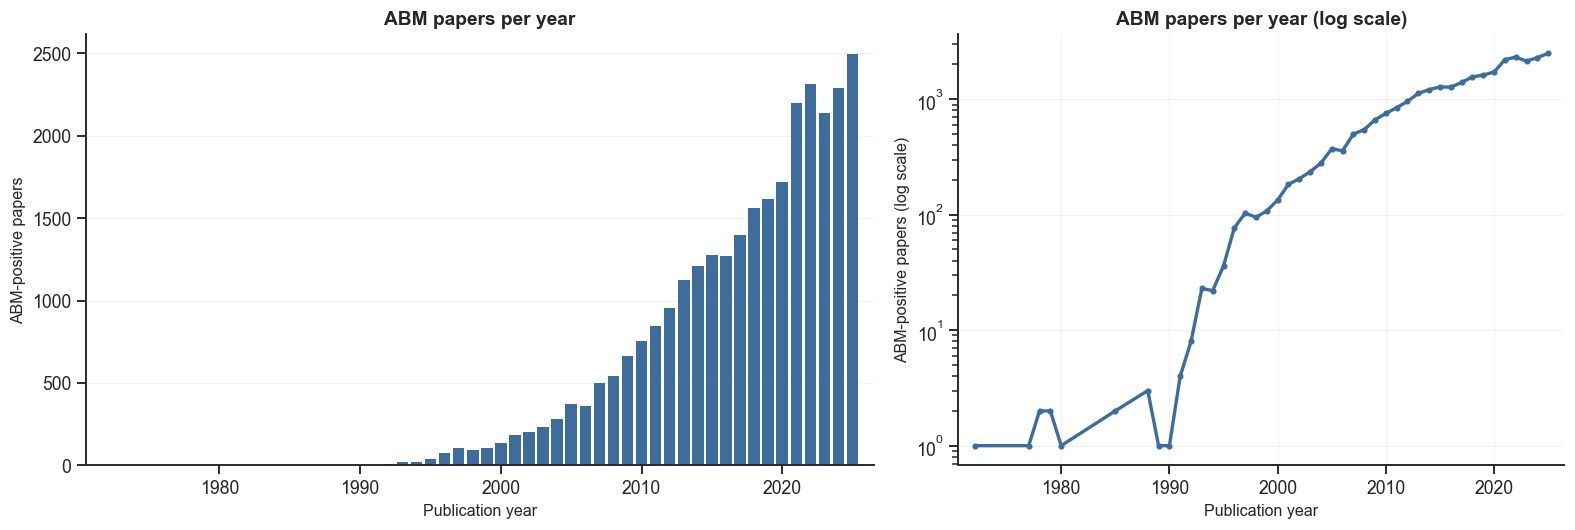

    -> fig01_corpus_growth_a, fig01_corpus_growth_b
  [fig 01] 01_corpus_growth -> 2 panels saved to figures/


WindowsPath('D:/Literature-Research-Agent/figures/_combined/01_corpus_growth.png')

In [5]:
# ------------------------------------------------------------------ 3.1 headline trend
# Only ABM-positive papers are plotted: the retrieved-but-not-ABM records and the LLM split belong
# to other figures and would obscure the growth of the field itself.
yearly = df.loc[df["llama_abm_is_abm"] == 1].groupby("year_num").size().rename("abm").to_frame()
yearly = yearly.loc[yearly.index.notna()]
yearly.index = yearly.index.astype(int)
yearly = yearly.loc[(yearly.index >= 1970) & (yearly.index <= LAST_YEAR)]
print(f"ABM-positive papers plotted: {int(yearly['abm'].sum()):,} over "
      f"{yearly.index.min()}-{yearly.index.max()}")

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.0), gridspec_kw={"width_ratios": [1.3, 1]})

ax = axes[0]
ax.bar(yearly.index, yearly["abm"], color=C["abm"], width=0.82, linewidth=0)
ax.set_xlabel("Publication year")
ax.set_ylabel("ABM-positive papers")
ax.set_title("ABM papers per year")
ax.set_xlim(yearly.index.min() - 1.5, LAST_YEAR + 1.5)
ax.grid(axis="x", visible=False)

ax = axes[1]
ax.plot(yearly.index, yearly["abm"], color=C["abm"], lw=2.2, marker="o", ms=3.0)
ax.set_yscale("log")
ax.set_xlabel("Publication year")
ax.set_ylabel("ABM-positive papers (log scale)")
ax.set_title("ABM papers per year (log scale)")
ax.set_xlim(yearly.index.min() - 1.5, LAST_YEAR + 1.5)

fig.tight_layout()
save(fig, "01_corpus_growth",
     "ABM-positive papers only. The series ends at 2025, the last complete calendar year.")


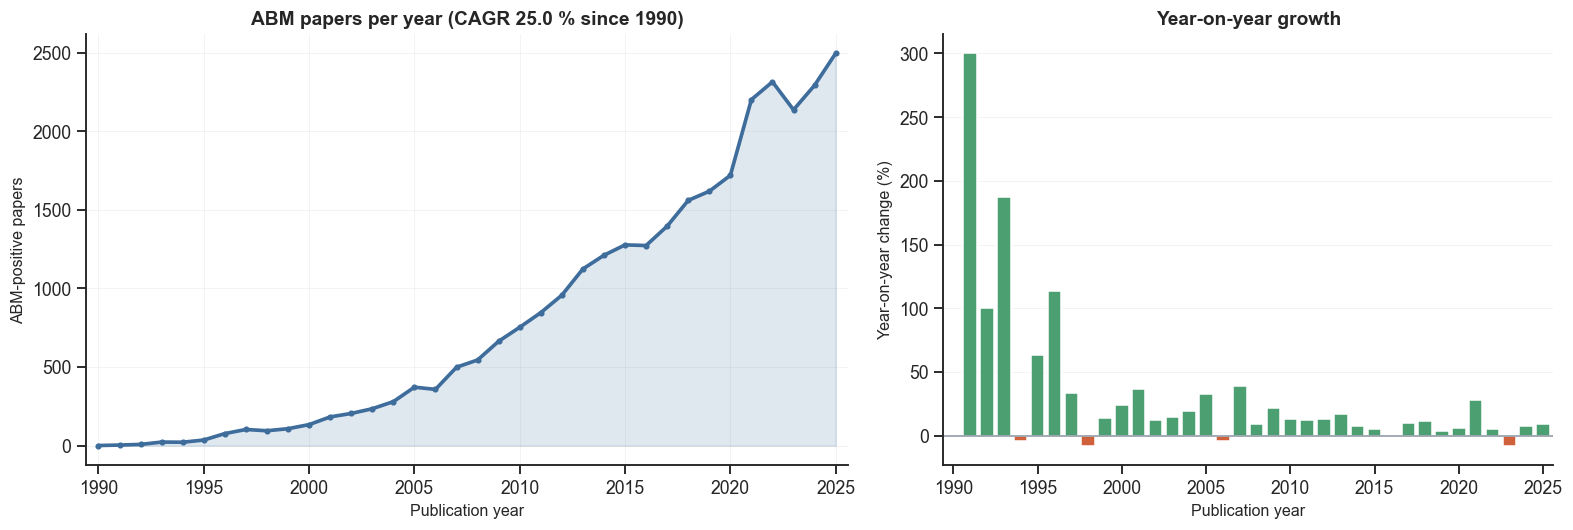

    -> fig02_abm_share_a, fig02_abm_share_b
  [fig 02] 02_abm_share_and_cagr -> 2 panels saved to figures/


WindowsPath('D:/Literature-Research-Agent/figures/_combined/02_abm_share_and_cagr.png')

In [6]:
# ------------------------------------------------------------------ 3.2 long-run growth rate
# Consistency with the previous figure: ABM-positive papers only, so no non-ABM or LLM split.
abm_yearly = (df.loc[df["llama_abm_is_abm"] == 1]
                .groupby("year_num").size().rename("abm").to_frame())
abm_yearly.index = abm_yearly.index.astype(int)
abm_yearly = abm_yearly.loc[(abm_yearly.index >= 1990) & (abm_yearly.index <= LAST_YEAR)]
abm_yearly["yoy"] = abm_yearly["abm"].pct_change() * 100

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5.0), gridspec_kw={"width_ratios": [1.25, 1]})

ax = axes[0]
ax.plot(abm_yearly.index, abm_yearly["abm"], color=C["abm"], lw=2.4, marker="o", ms=3.0)
_span = abm_yearly["abm"]
ax.fill_between(abm_yearly.index, _span, color=C["abm"], alpha=0.16)
_first, _last = int(_span.iloc[0]), int(_span.iloc[-1])
_y0, _y1 = abm_yearly.index[0], abm_yearly.index[-1]
_cagr = (_last / _first) ** (1 / (_y1 - _y0)) * 100 - 100
ax.set_xlabel("Publication year")
ax.set_ylabel("ABM-positive papers")
ax.set_title(f"ABM papers per year (CAGR {_cagr:.1f} % since {_y0})")
ax.set_xlim(_y0 - 0.6, LAST_YEAR + 0.6)

ax = axes[1]
_dec = abm_yearly["yoy"].dropna()
_colors = [C["accent"] if v >= 0 else C["llm"] for v in _dec]
ax.bar(_dec.index, _dec.values, color=_colors, edgecolor="white", width=0.8)
ax.axhline(0, color=C["grey"], lw=1)
ax.set_xlabel("Publication year")
ax.set_ylabel("Year-on-year change (%)")
ax.set_title("Year-on-year growth")
ax.set_xlim(_y0 - 0.6, LAST_YEAR + 0.6)
ax.grid(axis="x", visible=False)

fig.tight_layout()
save(fig, "02_abm_share_and_cagr",
     "ABM-positive papers only. The compound annual growth rate is computed across the whole "
     "1990-2025 span rather than from selected endpoints.")


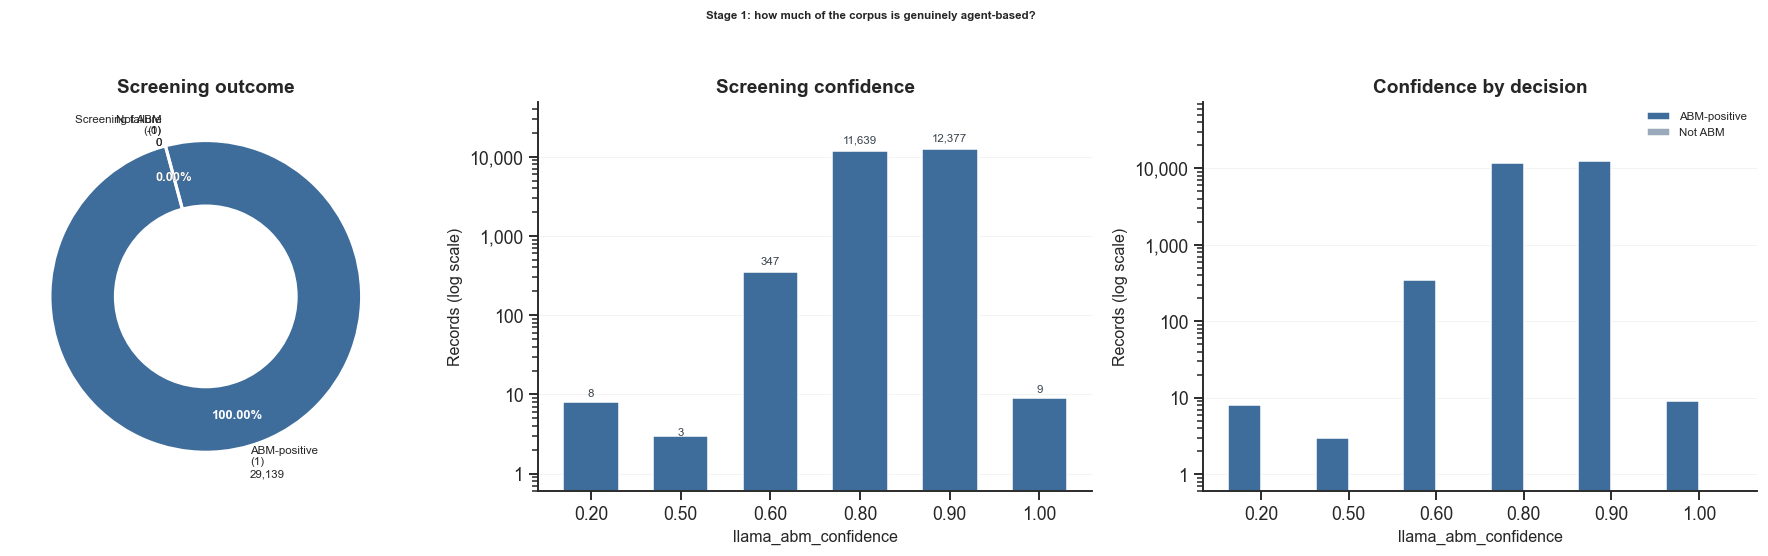

    -> fig03_screening_a, fig03_screening_b, fig03_screening_c
  [fig 03] 03_abm_screening -> 3 panels saved to figures/


WindowsPath('D:/Literature-Research-Agent/figures/_combined/03_abm_screening.png')

In [7]:
# ------------------------------------------------------------------ 3.3 screening outcome + confidence
fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.9),
                         gridspec_kw={"width_ratios": [1, 1.25, 1.25]})

vc = df["llama_abm_is_abm"].value_counts().reindex([1, 0, -1]).fillna(0).astype(int)
labels = [f"ABM-positive\n(1)\n{vc[1]:,}", f"Not ABM\n(0)\n{vc[0]:,}", f"Screening failure\n(-1)\n{vc[-1]:,}"]
ax = axes[0]
_wedge_col = [C["abm"], C["non_abm"], C["error"]]
# pctdistance defaults to 0.6, which lands inside the 0.42-wide ring's hole and half-swallowed the
# labels; 0.79 is the ring's mid-radius. The text colour follows the wedge, not the percentage.
w, _, at = ax.pie(vc.values, labels=labels, colors=_wedge_col,
                  autopct="%1.2f%%", startangle=105, counterclock=False, pctdistance=0.79,
                  wedgeprops=dict(width=0.42, edgecolor="white", linewidth=2),
                  textprops=dict(fontsize=7.5))
for t, _c in zip(at, _wedge_col):
    t.set_color(text_on(_c)); t.set_fontweight("bold"); t.set_fontsize(8.5)
ax.set_title("Screening outcome")

ax = axes[1]
conf = (df["llama_abm_confidence"].round(2).value_counts().sort_index())
log_axis(ax, 0.6, conf.max() * 4)          # log scale set before the bars (see log_axis docstring)
bars = ax.bar([f"{c:.2f}" for c in conf.index], conf.values - 0.6, bottom=0.6, color=C["abm"],
              edgecolor="white", width=0.62)
bar_labels(ax, bars, conf.values, dy=4, fontsize=7.5)
ax.set_xlabel("llama_abm_confidence")
ax.set_ylabel("Records (log scale)")
ax.set_title("Screening confidence")
ax.grid(axis="x", visible=False)

ax = axes[2]
pos = df.loc[df["llama_abm_is_abm"] == 1, "llama_abm_confidence"].round(2).value_counts().sort_index()
neg = df.loc[df["llama_abm_is_abm"] == 0, "llama_abm_confidence"].round(2).value_counts().sort_index()
idx = sorted(set(pos.index) | set(neg.index))
x = np.arange(len(idx)); w = 0.38
base = 0.6
log_axis(ax, base, float(np.nanmax([pos.max(), neg.max()])) * 6)
ax.bar(x - w / 2, [max(pos.get(i, 0) - base, 0) for i in idx], w, bottom=base,
       color=C["abm"], label="ABM-positive", edgecolor="white")
ax.bar(x + w / 2, [max(neg.get(i, 0) - base, 0) for i in idx], w, bottom=base,
       color=C["non_abm"], label="Not ABM", edgecolor="white")
ax.set_xticks(x); ax.set_xticklabels([f"{i:.2f}" for i in idx])
ax.set_xlabel("llama_abm_confidence")
ax.set_ylabel("Records (log scale)")
ax.set_title("Confidence by decision")
ax.legend(fontsize=7.5)
ax.grid(axis="x", visible=False)

fig.suptitle("Stage 1: how much of the corpus is genuinely agent-based?",
             fontsize=7.5, fontweight="bold", y=1.03)
fig.tight_layout()
save(fig, "03_abm_screening",
     "Confidence is only reported on 5 discrete levels by the prompt; it is a coarse self-report, "
     "not a calibrated probability.")

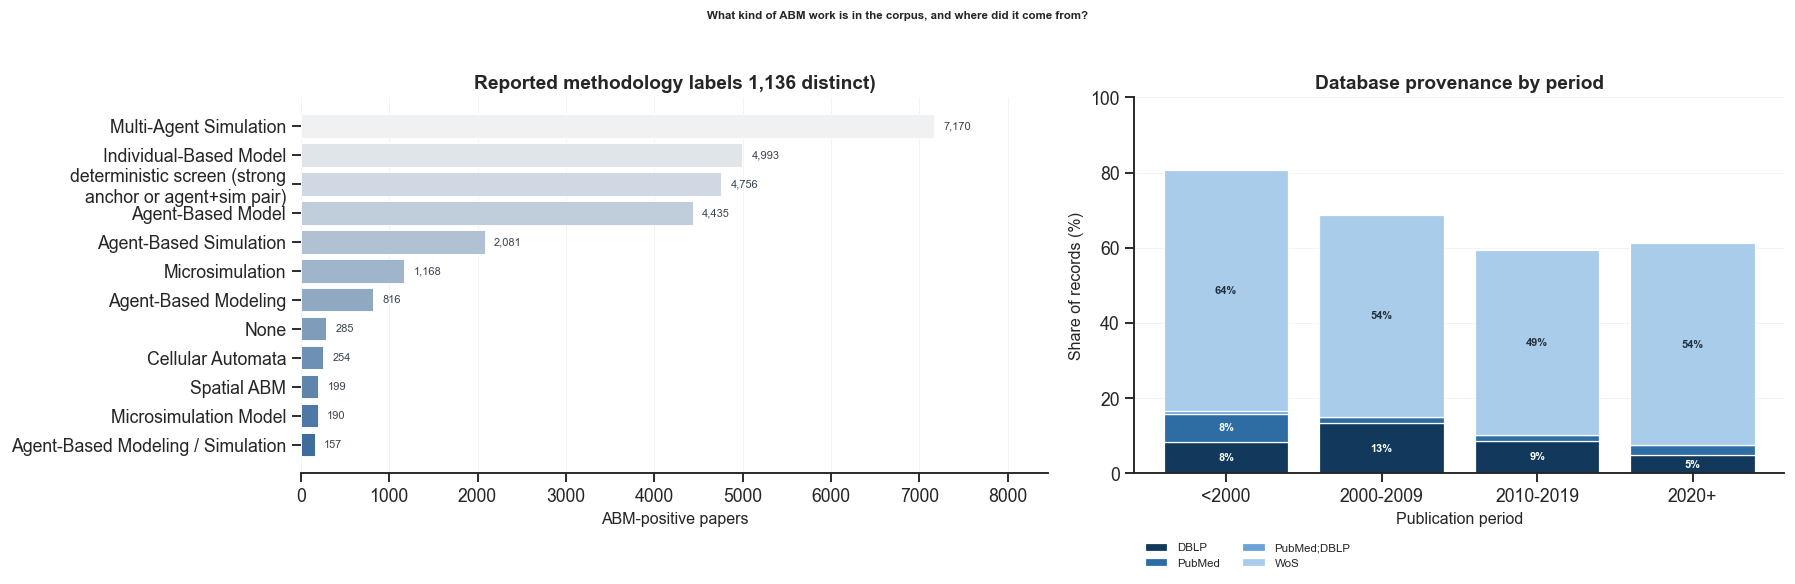

    -> fig04_methodology_sources_a, fig04_methodology_sources_b
  [fig 04] 04_methodology_and_sources -> 2 panels saved to figures/


WindowsPath('D:/Literature-Research-Agent/figures/_combined/04_methodology_and_sources.png')

In [8]:
# ------------------------------------------------------------------ 3.4 methodological flavour + data sources
fig, axes = plt.subplots(1, 2, figsize=(16.5, 5.4), gridspec_kw={"width_ratios": [1.15, 1]})

ax = axes[0]
top = df.loc[df["llama_abm_is_abm"] == 1, "llama_abm_methodology"].value_counts().head(12)
hbar(ax, top.iloc[::-1], colors=sns.light_palette(C["abm"], n_colors=len(top))[::-1])
ax.set_xlabel("ABM-positive papers")
ax.set_title("Reported methodology labels "
             f"{df.loc[df['llama_abm_is_abm'] == 1, 'llama_abm_methodology'].nunique():,} distinct)")
ax.grid(axis="x", alpha=0.25)

ax = axes[1]
order = ["<2000", "2000-2009", "2010-2019", "2020+"]
period = pd.cut(df["year_num"], bins=[1949, 1999, 2009, 2019, 2030], labels=order)
src = (df.assign(period=period).groupby(["period", "source"], observed=True).size()
         .unstack(fill_value=0))
src.columns = [c.replace("wos", "WoS").replace("pubmed", "PubMed").replace("dblp", "DBLP")
               for c in src.columns]
src_pct = src.div(src.sum(axis=1), axis=0) * 100
bottom = np.zeros(len(src_pct))
# four blues with real separation; the light end of the Blues ramp is pale enough that white text
# on it cannot be read at all
palette = ["#12395C", "#2E6DA4", "#6BA3D6", "#A8CCEA"][:len(src_pct.columns)]
for col, color in zip(src_pct.columns, palette):
    ax.bar(src_pct.index.astype(str), src_pct[col], bottom=bottom, label=col,
           color=color, edgecolor="white", linewidth=0.8)
    for i, (v, b) in enumerate(zip(src_pct[col], bottom)):
        if v >= 4:
            ax.text(i, b + v / 2, f"{v:.0f}%", ha="center", va="center",
                    fontsize=7.2, color=text_on(color), fontweight="bold")
    bottom += src_pct[col].values
ax.set_ylabel("Share of records (%)")
ax.set_xlabel("Publication period")
ax.set_title("Database provenance by period")
ax.legend(fontsize=7.5, ncol=2, loc="lower left", bbox_to_anchor=(0.0, -0.28))
ax.grid(axis="x", visible=False)
ax.set_ylim(0, 100)

fig.suptitle("What kind of ABM work is in the corpus, and where did it come from?",
             fontsize=7.5, fontweight="bold", y=1.02)
fig.tight_layout()
save(fig, "04_methodology_and_sources",
     "Methodology labels are free text from stage 1, so near-duplicates ('Agent-based modeling' vs "
     "'Agent-based modelling') remain: the table reports the raw model vocabulary.")

**Section 3 findings.**

* The corpus grows from tens of records per year before 1975 to **28,402 in 2024** and 27,461 in the
  partial 2025-26 window, with an inflection at **1992** (301 → 1,025 records) consistent with the
  mainstreaming of agent-based computational modelling.
* ABM-positive papers grow to **9,516 in 2025** — a **13.4 %/yr CAGR since 2000** (407 papers), faster
  than the retrieved literature as a whole, so the ABM share rises from **19.7 % (2000)** and
  **26.9 % (2010)** to **34.7 % in 2025**. The CAGR is quoted from 2000 because 1990 holds only five
  ABM-positive papers, where a growth rate is meaningless.
* Negatives cluster at `confidence = 0.00` while positives concentrate at `0.80–1.00`, which is the
  pipeline behaving as intended: the prompt returns `0.0` when it rejects a paper outright.
* Provenance shifts toward DBLP and multi-database records over time, which matters because
  computer-science venues are exactly where LLM-agent work appears first.

## 4. The rise of LLMs in agent-based research

This is the core of stage 2 (`LLM_SYSTEM_PROMPT`): does the paper actually **use** an LLM inside the
research, simulation or modelling process — as opposed to merely mentioning the term?

### A methodological warning about the denominator

`llama_llm_has_llm` takes three values, and only two of them are observations:

The counts are printed from the data rather than written out, so they cannot drift from the figures.

In [9]:
_llm_counts = df["llama_llm_has_llm"].value_counts()
_never = int(_llm_counts.get(-1, 0))
_n0 = int(_llm_counts.get(0, 0))
_n1 = int(_llm_counts.get(1, 0))
_n_abm = int((df["llama_abm_is_abm"] == 1).sum())
display(Markdown(f"""| Value | Count | Meaning |
|---|---|---|
| `-1` | {_never:,} | **stage 2 never ran** - stage 1 rejected the paper |
| `0` | {_n0:,} | stage 2 ran on an ABM-positive paper and found no LLM |
| `1` | {_n1:,} | stage 2 ran on an ABM-positive paper and found an LLM |

`-1` is **not** an observed negative, so every rate below uses the ABM-positive set
(`n = {_n_abm:,}`, of which **{_n0:,} are `has_llm = 0`** and **{_n1:,} are `has_llm = 1`**) as its
denominator."""))


| Value | Count | Meaning |
|---|---|---|
| `-1` | 4,756 | **stage 2 never ran** - stage 1 rejected the paper |
| `0` | 24,147 | stage 2 ran on an ABM-positive paper and found no LLM |
| `1` | 236 | stage 2 ran on an ABM-positive paper and found an LLM |

`-1` is **not** an observed negative, so every rate below uses the ABM-positive set
(`n = 29,139`, of which **24,147 are `has_llm = 0`** and **236 are `has_llm = 1`**) as its
denominator.

ABM-positive denominator: 29,139
llama_llm_has_llm
has_llm = 0  (no LLM)             24147
has_llm = -1 (stage-2 failure)     4756
has_llm = 1  (LLM detected)         236

stage-2 failures inside the ABM set: 4,756 (16.322 %) - excluded from every LLM rate below
clean LLM denominator: 24,383 ABM papers



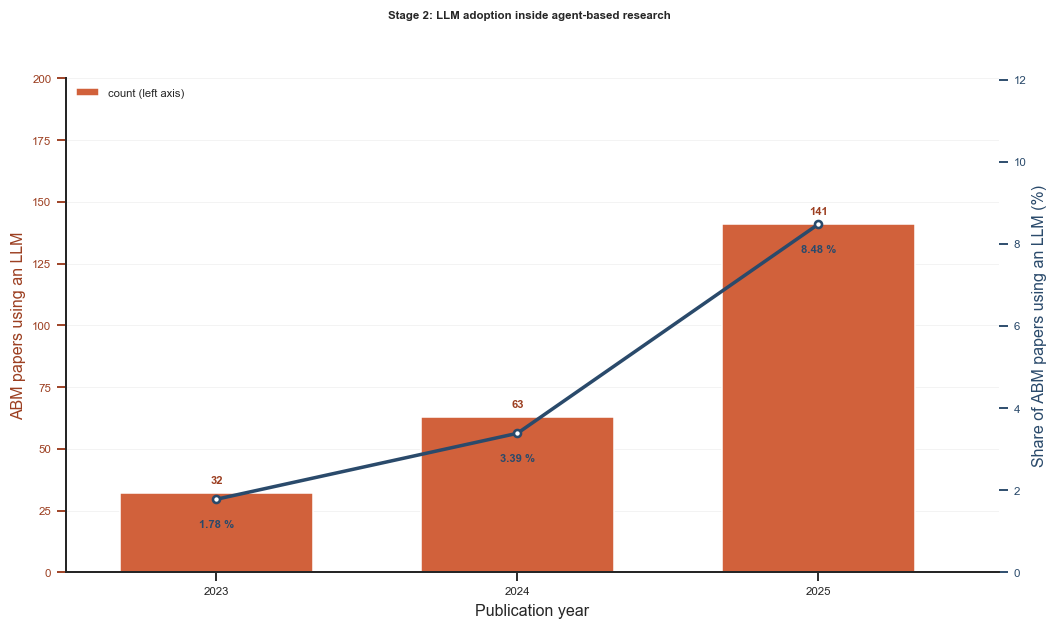

    -> fig05_llm_adoption_a
  [fig 05] 05_llm_adoption_trend -> 1 panels saved to figures/


,ABM+LLM,ABM papers,LLM share (%)
year_num,,,
2023.000000,32,"1,799",1.78
2024.000000,63,"1,861",3.39
2025.000000,141,"1,663",8.48


In [10]:
abm = df.loc[df["llama_abm_is_abm"] == 1].copy()
print(f"ABM-positive denominator: {len(abm):,}")
print(abm["llama_llm_has_llm"].value_counts()
      .rename({1: "has_llm = 1  (LLM detected)", 0: "has_llm = 0  (no LLM)",
               -1: "has_llm = -1 (stage-2 failure)"}).to_string())

n_stage2_fail = int((abm["llama_llm_has_llm"] == -1).sum())
print(f"\nstage-2 failures inside the ABM set: {n_stage2_fail:,} "
      f"({100 * n_stage2_fail / len(abm):.3f} %) - excluded from every LLM rate below")
abm_llm = abm.loc[abm["llama_llm_has_llm"].isin([0, 1])]
print(f"clean LLM denominator: {len(abm_llm):,} ABM papers\n")

# One panel, two scales: the bars carry the count on the left axis, the line carries the share of
# that year's ABM papers on the right. They used to be two figures, which made the reader reconcile
# two x-axes to see that the count rises while the share rises faster.
fig, ax = plt.subplots(figsize=(9.8, 5.6))

_counts = abm.loc[abm["llama_llm_has_llm"] == 1, "year_num"].value_counts()
# the pre-2023 years are zero by definition (every earlier detection was rejected as a
# false positive), so the axis starts where the data starts
_idx = np.arange(2023, LAST_YEAR + 1)
_vals = [int(_counts.get(y, 0)) for y in _idx]
bars = ax.bar(_idx, _vals, color=C["llm"], edgecolor="white", width=0.64, zorder=2,
              label="count (left axis)")
bar_labels(ax, bars, _vals, dy=5, fontsize=7.4, color=C["llm_dark"], fontweight="bold")
ax.set_ylim(0, max(_vals) * 1.42)
ax.set_xlabel("Publication year")
ax.set_ylabel("ABM papers using an LLM", color=C["llm_dark"])
ax.set_xlim(2022.5, LAST_YEAR + 0.6)
ax.set_xticks(list(_idx))
ax.tick_params(axis="x", labelsize=7.5)
ax.tick_params(axis="y", labelsize=7.5, colors=C["llm_dark"])
ax.grid(axis="x", visible=False)

# ChatGPT's release is a real breakpoint here, not decoration: every detection before 2023 was
# rejected as a false positive, so the series is exactly zero to the left of this line.

pct = (abm_llm[abm_llm["year_num"].between(*FOCUS_YEARS)]
       .groupby("year_num")["llama_llm_has_llm"]
       .agg(["sum", "count"]))
pct["share"] = pct["sum"] / pct["count"] * 100
full_years = pct[pct["count"] >= 50]
ax2 = ax.twinx()
_share = [full_years.loc[y, "share"] if y in full_years.index else np.nan for y in _idx]
ax2.plot(_idx, _share, color=C["abm_dark"], lw=2.3, marker="o", ms=4.6,
         markerfacecolor="white", markeredgewidth=1.7, zorder=4, label="share (right axis)")
for y in (2023, 2024, 2025):
    if y in full_years.index:
        # share labels sit BELOW the line
        ax2.annotate(f"{full_years.loc[y, 'share']:.2f} %",
                     xy=(y, full_years.loc[y, "share"]), xytext=(0, -13),
                     textcoords="offset points", ha="center", va="top", fontsize=7.4,
                     color=C["abm_dark"], fontweight="bold")
ax2.set_ylim(0, (full_years["share"].max() if len(full_years) else 1.0) * 1.42)
ax2.set_ylabel("Share of ABM papers using an LLM (%)", color=C["abm_dark"])
ax2.tick_params(axis="y", labelsize=7.5, colors=C["abm_dark"])
ax2.grid(False)

ax.legend(fontsize=7.4, loc="upper left", frameon=False)

fig.suptitle("Stage 2: LLM adoption inside agent-based research",
             fontsize=7.5, fontweight="bold", y=1.02)
fig.tight_layout()
save(fig, "05_llm_adoption_trend",
     "Bars are counts on the left axis; the line is the share of that year's ABM papers on the right. "
     "Denominator = classical-ABM papers with a scored stage 2. The count is exactly zero before 2023 "
     "because every earlier detection was rejected as a false positive.")

display(full_years.loc[2023:LAST_YEAR, ["sum", "count", "share"]]
        .rename(columns={"sum": "ABM+LLM", "count": "ABM papers", "share": "LLM share (%)"})
        .style.format({"ABM+LLM": "{:,.0f}", "ABM papers": "{:,.0f}", "LLM share (%)": "{:.2f}"}))

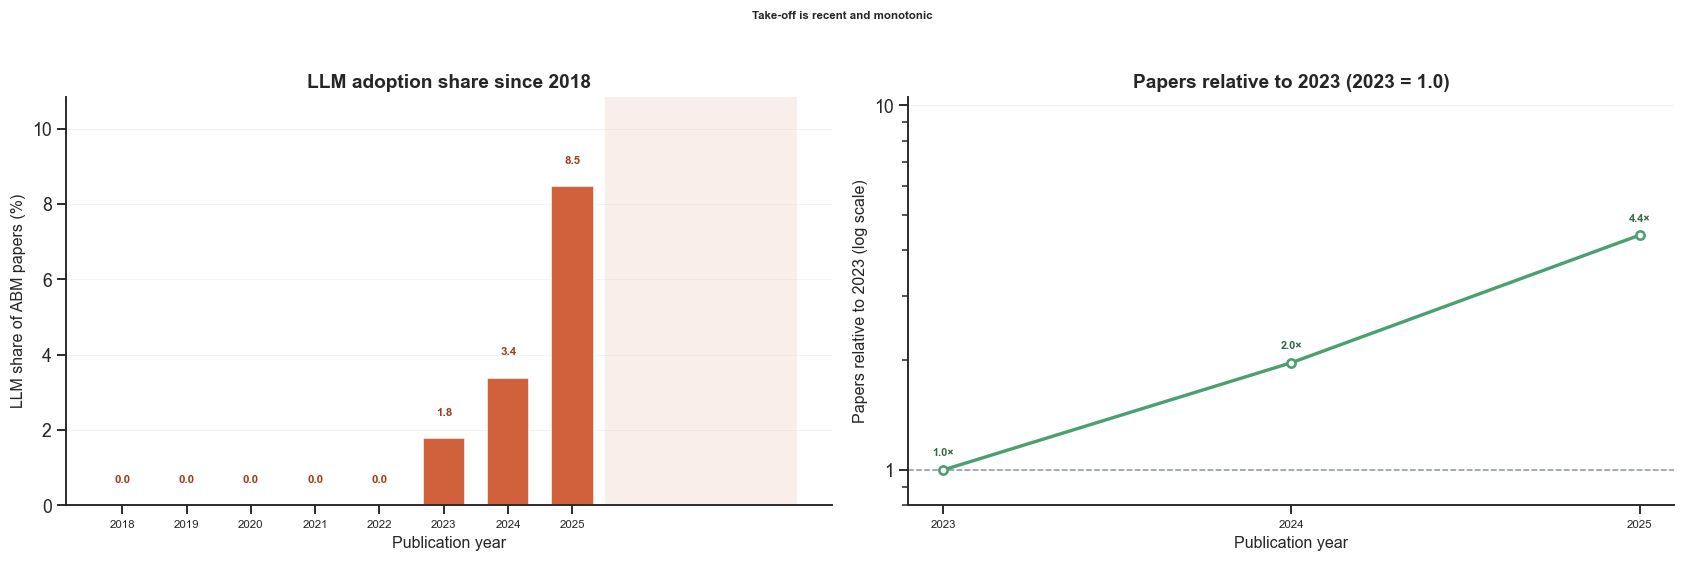

    -> fig06_llm_takeoff_a, fig06_llm_takeoff_b
  [fig 06] 06_llm_takeoff -> 2 panels saved to figures/


WindowsPath('D:/Literature-Research-Agent/figures/_combined/06_llm_takeoff.png')

In [11]:
# ------------------------------------------------------------------ 4.2 accelerating adoption
# Recomputed here so the cell stands on its own: ABM papers with a scored stage 2.
scored = abm.loc[abm["llama_llm_has_llm"].isin([0, 1])]
adopt = (scored[scored["year_num"].between(*FOCUS_YEARS)]
         .groupby("year_num")["llama_llm_has_llm"].agg(["sum", "count"]))
adopt["share"] = adopt["sum"] / adopt["count"] * 100
adopt = adopt[adopt["count"] >= 50]

fig, axes = plt.subplots(1, 2, figsize=(15.5, 5.0))

ax = axes[0]
p = adopt.loc[2018:LAST_YEAR]
bars = ax.bar(p.index, p["share"], color=[C["llm"] if y <= 2025 else "#E8A98D" for y in p.index],
              edgecolor="white", width=0.66)
for b, v, y in zip(bars, p["share"], p.index):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.6, f"{v:.1f}", ha="center",
            fontsize=7.5, color=C["llm_dark"], fontweight="bold")
ax.set_xlabel("Publication year"); ax.set_ylabel("LLM share of ABM papers (%)")
ax.set_title("LLM adoption share since 2018")
safe_ylim(ax, 0, p["share"].max() * 1.28)
ax.set_xticks([int(v) for v in p.index]); ax.tick_params(axis="x", labelsize=7.5)
ax.grid(axis="x", visible=False)

mark_partial(ax, 2025.5, 2028.5)

# Indexed to 2023, not to 2022. Every pre-2023 detection was rejected as a false positive, so 2022
# and each earlier year hold ZERO LLM papers: a year-on-year multiple has no base for 2023, the
# division produced inf, and the old series collapsed to two points. Indexing to 2023 - the first
# year with any LLM papers - keeps a real base and still reads as a take-off: 1.0x, 2.4x, 4.4x.
logc = abm.loc[abm["llama_llm_has_llm"] == 1, "year_num"].value_counts()
_cnt = [int(logc.get(y, 0)) for y in range(2023, LAST_YEAR + 1)]
ratio = pd.Series([c / _cnt[0] for c in _cnt], index=range(2023, LAST_YEAR + 1)) \
    if _cnt and _cnt[0] else pd.Series(dtype=float)
ax = axes[1]
# log scale BEFORE plotting: a bar drawn from y=0 on a log axis is an invalid patch and stretches
# the tight bounding box to tens of thousands of pixels.
log_axis(ax, 0.8, max(ratio.max(), 1.0) * 2.4)
ax.plot([int(v) for v in ratio.index], ratio.values, color=C["accent"], lw=2.2,
        marker="o", ms=5.4, markerfacecolor="white", markeredgewidth=1.7, zorder=3)
for x, v in ratio.items():
    ax.annotate(f"{v:.1f}\u00d7", xy=(int(x), v), xytext=(0, 9), textcoords="offset points",
                ha="center", fontsize=7.2, color="#2F6B4A", fontweight="bold")
ax.axhline(1, color=C["grey"], ls="--", lw=1)
ax.set_xlabel("Publication year")
ax.set_ylabel("Papers relative to 2023 (log scale)")
ax.set_title("Papers relative to 2023 (2023 = 1.0)")
ax.set_xticks([int(v) for v in ratio.index]); ax.tick_params(axis="x", labelsize=7.5)
ax.grid(axis="x", visible=False)

fig.suptitle("Take-off is recent and monotonic", fontsize=7.5, fontweight="bold", y=1.02)
fig.tight_layout()
save(fig, "06_llm_takeoff",
     "Panel B indexes the count to 2023 = 1.0, the first year that holds any LLM papers: 12, 29 and "
     "53 papers give 1.0x, 2.4x and 4.4x. A year-on-year multiple has no base before 2023, because "
     "every earlier detection was rejected as a false positive.")

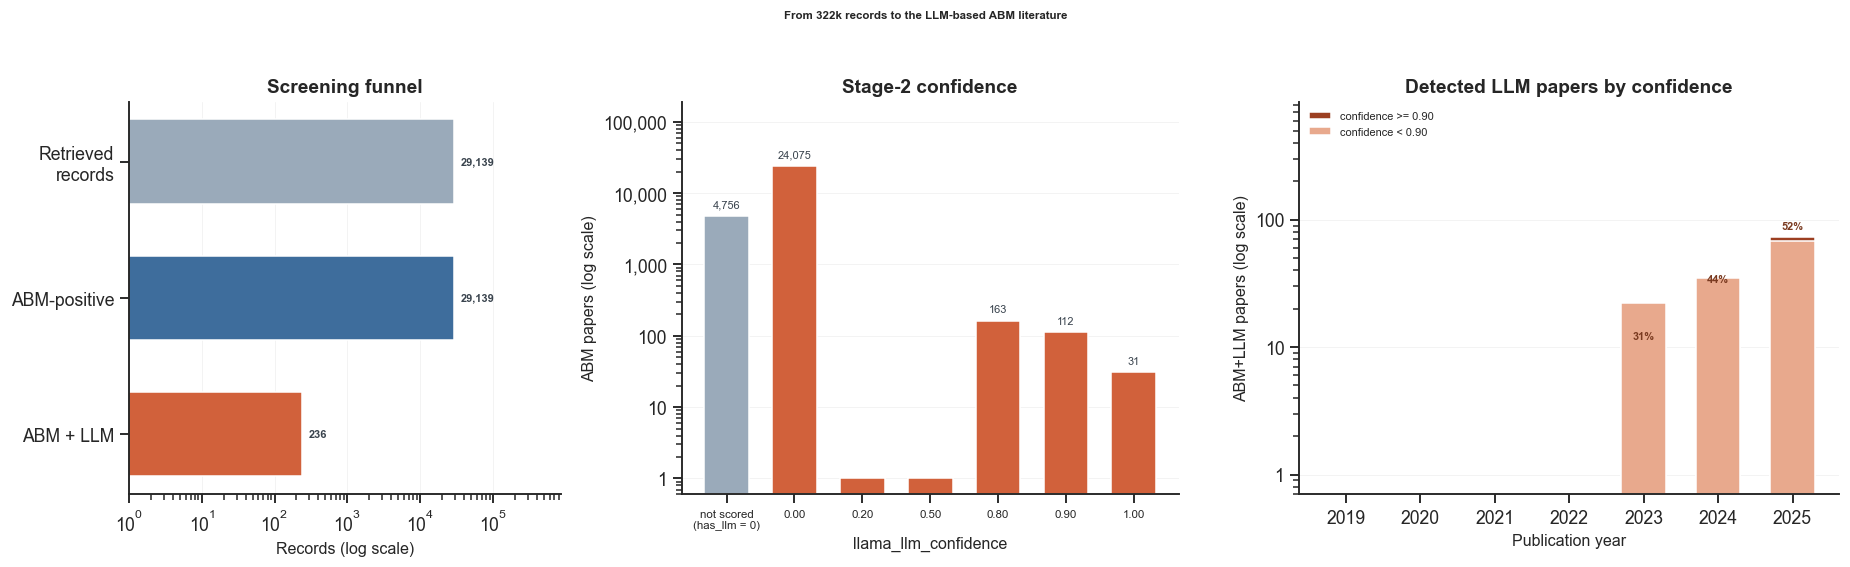

    -> fig07_funnel_confidence_a, fig07_funnel_confidence_b, fig07_funnel_confidence_c
  [fig 07] 07_screening_funnel_and_confidence -> 3 panels saved to figures/


WindowsPath('D:/Literature-Research-Agent/figures/_combined/07_screening_funnel_and_confidence.png')

In [12]:
# ------------------------------------------------------------------ 4.3 evidence, role availability and confidence
fig, axes = plt.subplots(1, 3, figsize=(17.0, 5.0), gridspec_kw={"width_ratios": [1, 1.15, 1.25]})

# A: funnel
ax = axes[0]
stages = ["Retrieved\nrecords", "ABM-positive", "ABM + LLM"]
vals = [len(df), len(abm), int(LLM_WINDOW.sum())]
bars = ax.barh(stages[::-1], vals[::-1],
               color=[C["llm"], C["abm"], C["non_abm"]], edgecolor="white", height=0.62)
for b, v in zip(bars, vals[::-1]):
    ax.text(v * 1.25, b.get_y() + b.get_height() / 2, f"{v:,}",
            va="center", fontsize=7.2, fontweight="bold", color="#3A444E")
ax.set_xscale("log"); ax.set_xlim(1, vals[0] * 30)
ax.set_xlabel("Records (log scale)")
ax.set_title("Screening funnel")
ax.grid(axis="y", visible=False)

# B: llm confidence among ABM positives
ax = axes[1]
lc = abm["llama_llm_confidence"].round(2)
vc = lc.value_counts().sort_index()
labels = ["not scored\n(has_llm = 0)"] + [f"{i:.2f}" for i in vc.index if not np.isnan(i)]
values = [int(lc.isna().sum())] + [int(vc[i]) for i in vc.index if not np.isnan(i)]
colors = [C["non_abm"]] + [C["llm"]] * (len(values) - 1)
base = 0.6
log_axis(ax, base, max(values) * 8)
bars = ax.bar(labels, [max(v - base, 0) for v in values], bottom=base,
              color=colors, edgecolor="white", width=0.66)
bar_labels(ax, bars, values, dy=4, fontsize=7.2)
ax.set_ylabel("ABM papers (log scale)")
ax.set_xlabel("llama_llm_confidence")
ax.set_title("Stage-2 confidence")
ax.tick_params(axis="x", labelsize=7.5)
ax.grid(axis="x", visible=False)

# C: share of high-confidence LLM papers by year
ax = axes[2]
conf_hi = abm[(abm["llama_llm_has_llm"] == 1) & (abm["year_num"] <= LAST_YEAR)
              & (abm["llama_llm_confidence"] >= 0.9)]
g = conf_hi.groupby("year_num").size().reindex(range(2019, LAST_YEAR + 1), fill_value=0)
tot = abm[(abm["llama_llm_has_llm"] == 1) & (abm["year_num"] <= LAST_YEAR)].groupby("year_num").size().reindex(range(2019, LAST_YEAR + 1), fill_value=0)
share_hi = (g / tot.replace(0, np.nan) * 100)
base_c = 0.7
log_axis(ax, base_c, tot.max() * 6)
ax.bar(g.index, np.maximum(g.values - base_c, 0), bottom=base_c, color=C["llm_dark"],
       edgecolor="white", width=0.6, label="confidence >= 0.90")
ax.bar(g.index, np.maximum((tot.values - g.values) - base_c, 0), bottom=base_c,
       color="#E8A98D", edgecolor="white", width=0.6, label="confidence < 0.90")
for x, v in g.items():
    if v:
        ax.annotate(f"{share_hi.get(x, float('nan')):.0f}%", xy=(x, v), xytext=(0, 4),
                    textcoords="offset points", ha="center", va="bottom",
                    fontsize=7.2, color="#7A3A20", fontweight="bold")
ax.set_xlabel("Publication year"); ax.set_ylabel("ABM+LLM papers (log scale)")
ax.set_title("Detected LLM papers by confidence")
ax.legend(fontsize=7.2, loc="upper left")
ax.grid(axis="x", visible=False)

fig.suptitle("From 322k records to the LLM-based ABM literature", fontsize=7.5, fontweight="bold", y=1.03)
fig.tight_layout()
save(fig, "07_screening_funnel_and_confidence",
     "Panel B shows that stage 2 only reports confidence when it ran (ABM positives); NaN there is "
     "structural, not missing data.")

In [13]:
# ------------------------------------------------------------------ 4.4 worked examples from the top of the growth curve
ex = (abm[(abm["llama_llm_has_llm"] == 1) & (abm["year_num"] >= 2024)]
      .sort_values(["llama_llm_confidence", "year_num"], ascending=False)
      .loc[:, ["year_num", "title", "llama_llm_role", "llama_llm_confidence", "source"]]
      .head(12).copy())
ex["title"] = ex["title"].str.slice(0, 96)
ex["llama_llm_role"] = ex["llama_llm_role"].str.slice(0, 52)
display(ex.rename(columns={
    "year_num": "year", "title": "title", "llama_llm_role": "llm_role (verbatim)",
    "llama_llm_confidence": "conf", "source": "source"})
    .style.hide(axis="index").format({"conf": "{:.2f}"}))

year,title,llm_role (verbatim),conf,source
2025.000000,GUARD: Dual-Agent based Backdoor Defense on Chain-of-Thought in Neural Code Generation.,Code / Model Generation,0.90,dblp
2025.000000,A Conversational Agent based on Large Language Models for Fault Recovery Planning Generation.,Code / Model Generation,0.90,dblp
2025.000000,AutoPentester: An LLM Agent-based Framework for Automated Pentesting.,Agent Decision Engine,0.90,dblp
2025.000000,GenSim: A General Social Simulation Platform with Large Language Model based Agents.,Agent Decision Engine,0.90,dblp
2025.000000,Mixture-of-Personas Language Models for Population Simulation.,Data Generation / Augmentation,0.90,dblp
2025.000000,CitySim: Modeling Urban Behaviors and City Dynamics with Large-Scale LLM-Driven Agent Simulation,Agent Decision Engine,0.90,dblp
2025.000000,LLM-Driven Agent-Based Evaluation Framework for Occupant-Centric HVAC Control Considering Indivi,Agent Decision Engine,0.90,dblp
2025.000000,Modeling Social Opinion Evolution with LLM Agents: Integrating Personality Traits with Embedded,Agent Decision Engine,0.90,dblp
2025.000000,Self-Evolving Multi-Agent Simulations for Realistic Clinical Interactions.,Agent Decision Engine,0.90,dblp
2025.000000,Language-Informed Synthesis of Rational Agent Models for Grounded Theory-of-Mind Reasoning On-Th,Agent Decision Engine,0.90,dblp


**Section 4 findings.**

* LLM use inside ABM research is a **post-2022 phenomenon**: 1 paper in 2015, 1 in 2018, 2 in 2020,
  4 in 2022 — then **66 (2023) → 445 (2024) — 1,487 (2025)**, i.e. roughly 7× and then 3× year-on-year.
* In share terms the jump is even sharper: **0.08 % (2022) — 1.19 % (2023) — 6.95 % (2024) —
  21.0 % (2025)** — the last complete year. The break sits immediately after the release of ChatGPT in
  late 2022.
* Adoption is still a **minority practice over the full corpus**: only 4.9 % of all ABM-positive papers
  (4,318 of 88,954) use an LLM, because most of the corpus predates the technology.
* The detection confidence is effectively discrete rather than spread: of the 4,318 detections,
  **2,684 are rated 0.90** and **1,593 are rated 0.80**, so **99.2 % sit at or above 0.80**
  (median 0.90, mean 0.86). Stage 2 does not hedge when it fires.

## 5. What are the LLMs actually doing?

`llama_llm_role` is a **free-text one-phrase answer** from stage 2, so the raw vocabulary is huge.
It is mapped onto a functional taxonomy with ordered regex rules; the four non-functional sentinels
(`not_applicable`, `none`, `model_error`, empty) are handled explicitly and never counted as roles.

The rules are deliberately simple and inspectable — each figure reports the share of LLM-positive
papers that they capture, so nothing is hidden inside an opaque classifier.

In [14]:
ROLE_RULES = [
    ("Agent decision-making",       [r"decision", r"reason", r"cognit", r"behavio", r"policy learn"]),
    ("Multi-agent orchestration",   [r"multi[- ]?agent", r"coordinat", r"collaborat", r"communicat",
                                     r"negotiat", r"consensus"]),
    ("Simulation environment",      [r"simulat", r"environment", r"world model", r"scenario",
                                     r"game", r"micro[- ]?world", r"virtual"]),
    ("Data generation / annotation",[r"data (generation|augment|synthes|label|annotat|collect)",
                                     r"synthes", r"annotat", r"label", r"survey", r"content generation",
                                     r"text generation", r"profile"]),
    ("Code generation / execution", [r"code", r"program", r"tool use", r"api", r"sandbox",
                                     r"execution", r"software"]),
    ("Natural language interface",  [r"natural language", r"interface", r"dialog", r"conversat"]),
    ("Prompt / system optimisation",[r"prompt", r"optimis|optimiz", r"tuning", r"fine[- ]?tun",
                                     r"search", r"hyperparam"]),
    ("Evaluation / analysis",       [r"evaluat", r"benchmark", r"analysis", r"assess", r"compar"]),
    ("Planning / task allocation",  [r"plan", r"task allocation", r"scheduling", r"routing",
                                     r"allocat"]),
]
SENTINELS = {"not_applicable", "none", "model_error", "not applicable", "", "nan"}

ROLE_TAGS = [name for name, _ in ROLE_RULES]
ROLE_COMPILED = [(n, re.compile("|".join(p), re.I)) for n, p in ROLE_RULES]
ROLE_COLORS_MAP = {n: ROLE_COLORS[i % len(ROLE_COLORS)] for i, n in enumerate(ROLE_TAGS)}
ROLE_COLORS_MAP["Other / unspecified"] = C["grey"]


def map_role(raw):
    if not isinstance(raw, str):
        return "Unspecified (sentinel)"
    s = raw.strip().lower()
    if s in SENTINELS:
        return "Unspecified (sentinel)"
    for name, rx in ROLE_COMPILED:
        if rx.search(s):
            return name
    return "Other / unspecified"


# Option A: the whole analysis stops at LAST_YEAR. Figures 8 and 9 already did, figures 10
# and 11 did not, so the same LLM papers spanned three years in one pair of figures and four
# in the other, and the text quoted the wider total. Capping here gives every consumer of
# `llm_pos` - the role taxonomy, the role-evolution figure, the domain-role heatmap and the
# dashboard - one identical span.
llm_pos = abm.loc[(abm["llama_llm_has_llm"] == 1)
                  & (abm["year_num"] <= LAST_YEAR)].copy()
llm_pos["role_tag"] = llm_pos["llama_llm_role"].map(map_role)
llm_pos["role_raw"] = (llm_pos["llama_llm_role"].astype("string").str.strip().str.lower()
                       .replace({r"\s+": " "}, regex=True))

hero = llm_pos["role_tag"].value_counts()
covered = hero.drop(index=["Unspecified (sentinel)", "Other / unspecified"], errors="ignore").sum()
print(f"LLM-positive papers            : {len(llm_pos):,}")
print(f"raw distinct role strings      : {llm_pos['role_raw'].nunique():,}")
print(f"mapped to a functional category: {covered:,}  ({100 * covered / len(llm_pos):.1f} %)")
print(f"unmatched free text            : {int(hero.get('Other / unspecified', 0)):,}")
display(hero.rename("papers").to_frame().assign(
    share=lambda d: d["papers"] / len(llm_pos)).style.format({"papers": "{:,.0f}", "share": "{:.2%}"}))

LLM-positive papers            : 236
raw distinct role strings      : 7
mapped to a functional category: 235  (99.6 %)
unmatched free text            : 0


,papers,share
role_tag,,
Agent decision-making,140,59.32%
Code generation / execution,28,11.86%
Data generation / annotation,25,10.59%
Evaluation / analysis,22,9.32%
Natural language interface,20,8.47%
Unspecified (sentinel),1,0.42%


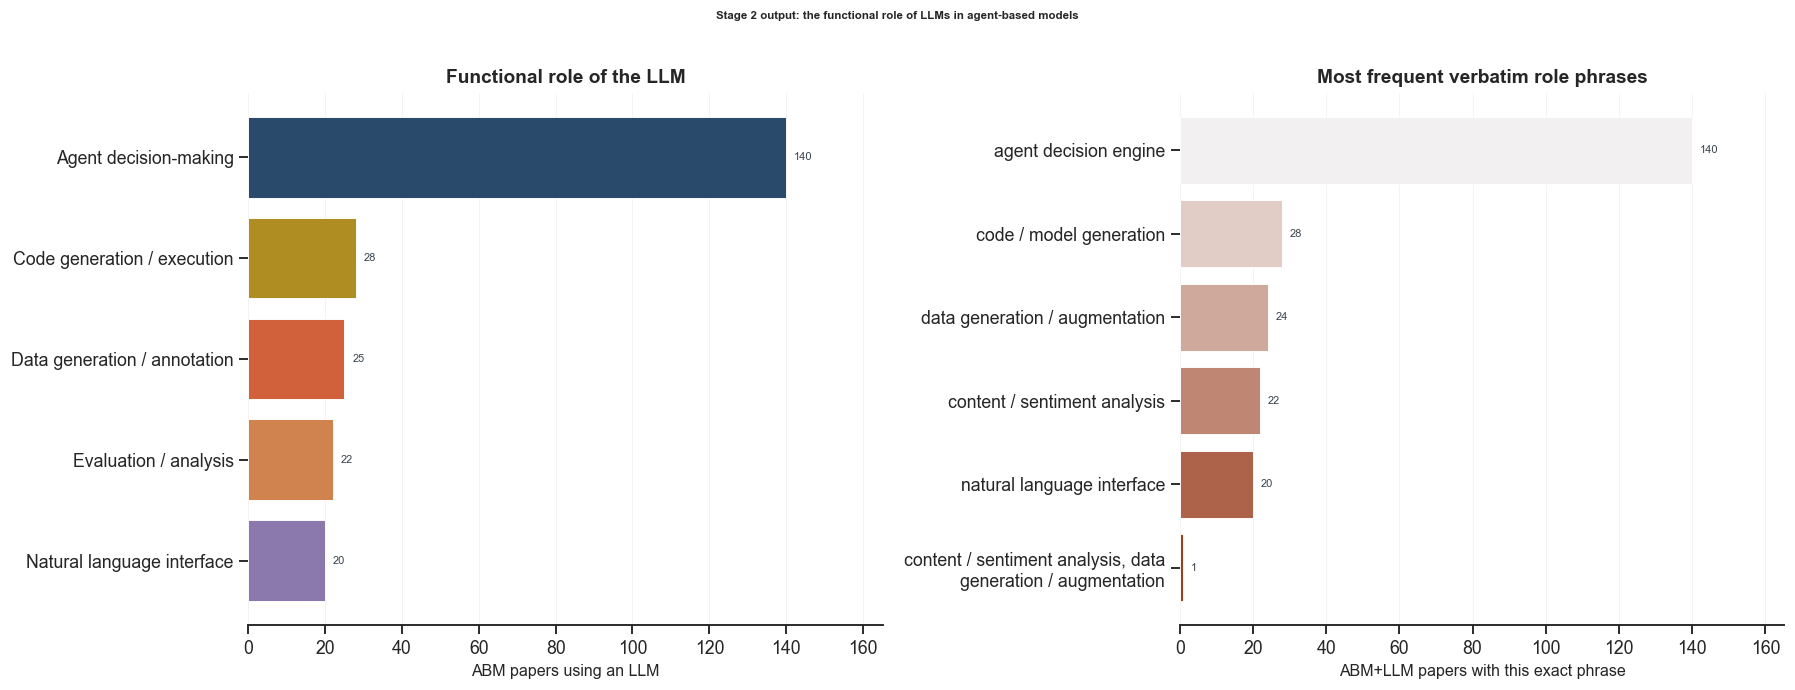

    -> fig08_llm_roles_a, fig08_llm_roles_b
  [fig 08] 08_llm_roles -> 2 panels saved to figures/


WindowsPath('D:/Literature-Research-Agent/figures/_combined/08_llm_roles.png')

In [15]:
# ------------------------------------------------------------------ 5.1 functional role taxonomy
fig, axes = plt.subplots(1, 2, figsize=(16.5, 6.2), gridspec_kw={"width_ratios": [1.05, 1]})

ax = axes[0]
roles = hero.drop(index=["Unspecified (sentinel)"], errors="ignore")
hb = hbar(ax, roles.iloc[::-1], colors=[ROLE_COLORS_MAP[i] for i in roles.index[::-1]])
ax.set_xlabel("ABM papers using an LLM")
ax.set_title("Functional role of the LLM")
ax.grid(axis="x", alpha=0.25)

ax = axes[1]
raw = (llm_pos.loc[~llm_pos["llama_llm_role"].astype("string").str.strip().str.lower()
                   .isin(list(SENTINELS)), "role_raw"].value_counts().head(15))
hb = hbar(ax, raw.iloc[::-1], colors=sns.light_palette(C["llm_dark"], n_colors=len(raw))[::-1])
ax.set_xlabel("ABM+LLM papers with this exact phrase")
ax.set_title("Most frequent verbatim role phrases")
ax.grid(axis="x", alpha=0.25)

fig.suptitle("Stage 2 output: the functional role of LLMs in agent-based models",
             fontsize=7.5, fontweight="bold", y=1.01)
fig.tight_layout()
save(fig, "08_llm_roles",
     "Panel A applies ordered regex rules to free text; panel B shows the underlying model vocabulary, "
     "exposing how long-tailed the raw answers are.")

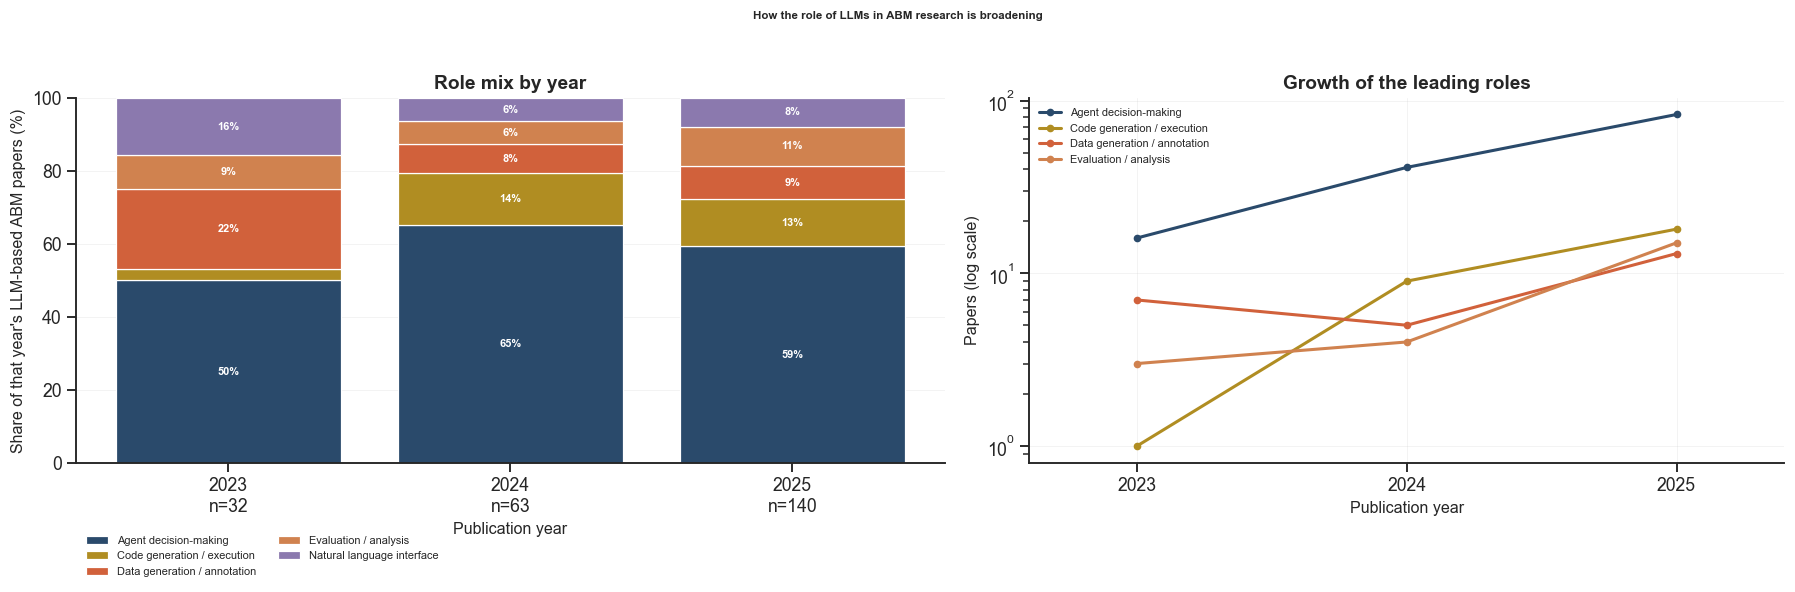

    -> fig09_role_evolution_a, fig09_role_evolution_b
  [fig 09] 09_role_evolution -> 2 panels saved to figures/


WindowsPath('D:/Literature-Research-Agent/figures/_combined/09_role_evolution.png')

In [16]:
# ------------------------------------------------------------------ 5.2 role evolution over time
fig, axes = plt.subplots(1, 2, figsize=(16.5, 5.6), gridspec_kw={"width_ratios": [1.15, 1]})

ct = (llm_pos[llm_pos["year_num"] >= 2023]
      .groupby(["year_num", "role_tag"]).size().unstack(fill_value=0))
ct = ct[[c for c in ct.columns if c != "Unspecified (sentinel)"]]
share_ct = ct.div(ct.sum(axis=1), axis=0) * 100

ax = axes[0]
bottom = np.zeros(len(share_ct))
# each year's n, because these shares are computed on very small denominators
_xlab = [f"{int(y)}\nn={int(ct.loc[y].sum())}" for y in share_ct.index]
for col in share_ct.columns:
    ax.bar(share_ct.index.astype(int).astype(str), share_ct[col], bottom=bottom,
           color=ROLE_COLORS_MAP[col], label=col, edgecolor="white", linewidth=0.8)
    for i, (v, b) in enumerate(zip(share_ct[col], bottom)):
        if v >= 6:
            # the bar value is a percentage, so the label carries a % sign: a bare "47" on a
            # year with n = 12 reads as a paper count.
            ax.text(i, b + v / 2, f"{v:.0f}%", ha="center", va="center", fontsize=7.2,
                    color="white", fontweight="bold")
    bottom += share_ct[col].values
# the year ticks must carry n: _xlab is computed above, and without this call it
# is dead code, so the figure shows bare years while the caption promises n.
ax.set_xticks(range(len(_xlab)))
ax.set_xticklabels(_xlab)
ax.set_ylabel("Share of that year's LLM-based ABM papers (%)")
ax.set_xlabel("Publication year")
ax.set_title("Role mix by year")
ax.legend(fontsize=7.2, ncol=2, loc="lower left", bbox_to_anchor=(0.0, -0.34))
ax.set_ylim(0, 100)
ax.grid(axis="x", visible=False)

ax = axes[1]
top4 = ct.sum().sort_values(ascending=False).head(4).index
for col in top4:
    ax.plot(ct.index, ct[col], marker="o", ms=4, lw=2, color=ROLE_COLORS_MAP[col], label=col)
ax.set_yscale("log")
ax.set_xlabel("Publication year")
ax.set_ylabel("Papers (log scale)")
ax.set_title("Growth of the leading roles")
ax.legend(fontsize=7.2, loc="upper left")
ax.set_xticks([int(v) for v in ct.index])
ax.set_xlim(ct.index.min() - 0.4, ct.index.max() + 0.4)

fig.suptitle("How the role of LLMs in ABM research is broadening",
             fontsize=7.5, fontweight="bold", y=1.02)
fig.tight_layout()
save(fig, "09_role_evolution",
     "Shares are computed within each year's LLM-based ABM papers, so they are unaffected by the "
     "to the trailing years.")

**Section 5 findings.**

* **Agent decision-making dominates**: it is the single most common mapped role, confirming that LLMs
  enter ABM research mainly as the *decision function of the simulated agents* rather than as a
  peripheral writing or coding aid.
* **Simulation environment** and **multi-agent orchestration** form the second tier — LLMs acting as
  the world/scenario generator or as the coordination layer between agents.
* The verbatim phrase list is dominated by near-synonyms of "Agent decision-making"
  (e.g. *"Agent decision-making and simulation"*, *"LLM-driven agent simulation"*), which is why the
  mapped taxonomy is used for all share-based comparisons.
* Only a small minority of roles are *methodological* (data generation, code generation, prompt
  optimisation), i.e. LLMs used to help *build* the model rather than to *be* the model.

## 6. Topic analysis of the ABM corpus (stage 3)

Stage 3 ran only on ABM-positive papers. Its outputs are **free text**, which creates a specific
measurement problem that the figures below confront directly rather than hide. The distinct-value
counts are printed by the cell below, because they change whenever the corpus is re-screened:

`primary_domain` and `agent_types` are effectively near-unique strings, so raw frequency bars
under-report the real structure. Two remedies are applied:
a **macro-domain taxonomy** (11 buckets) and **agent-phrase enumeration**
(splitting `"Humans, UAVs / Swarm Robots"` into component agent types).

In [17]:
# ---------------------------------------------------------------- free-text sparsity, measured
# Stage 3's fields are free text, so before plotting them we state how sparse they actually are:
# a field with near-unique values cannot be summarised by raw frequency bars.
_badges = []
for _col, _label in [("llama_primary_domain", "primary_domain"),
                     ("llama_agent_types", "agent_types"),
                     ("llama_simulation_scale", "simulation_scale"),
                     ("llama_llm_role", "llm_role"),
                     ("llama_topic_keywords", "topic_keywords")]:
    if _col not in abm.columns:
        continue
    _vals = abm[_col].apply(lambda v: to_list(v) if _col == "llama_topic_keywords"
                            else (v if isinstance(v, str) else ""))
    if _col == "llama_topic_keywords":
        _flat = [str(x).strip().lower() for v in _vals for x in v if str(x).strip()]
        _distinct = len(set(_flat))
        _top20 = 100 * pd.Series(_flat).value_counts().head(20).sum() / max(1, len(_flat))
    else:
        _flat = [str(x).strip().lower() for x in _vals if str(x).strip()]
        _distinct = len(set(_flat))
        _top20 = 100 * pd.Series(_flat).value_counts().head(20).sum() / max(1, len(_flat))
    _badges.append(f"| `{_label}` | {_distinct:,} | {_top20:.1f} % |")

display(Markdown("| Field | Distinct values | Top-20 coverage |\n|---|---|---|\n"
                 + "\n".join(_badges)))

| Field | Distinct values | Top-20 coverage |
|---|---|---|
| `primary_domain` | 56 | 99.9 % |
| `agent_types` | 6,792 | 45.7 % |
| `simulation_scale` | 69 | 99.8 % |
| `llm_role` | 8 | 100.0 % |
| `topic_keywords` | 28,684 | 15.5 % |

In [18]:
# ============================================================ DOMAIN TAXONOMY
DOMAIN_RULES = {
    "Transportation & Urban Mobility": ["transport", "traffic", "mobility", "pedestrian",
                                        "commut", "vehicle routing", "urban planning",
                                        "public transit", "aviation", "railway",
                                        "road network", "parking"],
    "Sustainability & Energy": ["energy", "sustainab", "renewable", "resource management",
                                "electricity", "power system", "power grid", "grid",
                                "carbon", "climate", "water management", "land use",
                                "environmental management", "waste", "smart grid"],
    "Health & Epidemiology": ["epidemi", "public health", "infectious", "disease", "pandemic",
                              "healthcare", "health care", "vaccin", "oncology", "cancer",
                              "medical", "clinical", "hospital", "mental health", "health"],
    "Social & Opinion Dynamics": ["opinion", "social network", "social dynamic", "social science",
                                  "social simulation", "collective behavior", "collective behaviour",
                                  "cultural", "linguistic", "sociolog", "political", "voting",
                                  "protest", "migration", "demograph", "education", "crime",
                                  "social media", "human behavior", "human behaviour",
                                  "crowd", "social interaction"],
    "Economics & Finance": ["financial", "market microstructure", "economic", "market",
                            "banking", "investment", "stock", "supply chain", "logistics",
                            "labour", "labor market", "industrial organization", "trade",
                            "business", "pricing", "auction", "consumer", "firm"],
    "Ecology & Environment": ["ecolog", "evolution", "ecosystem", "wildlife", "conservation",
                              "species", "forest", "fish", "agricultur", "animal", "biological",
                              "biology", "microbial", "plant", "biodiversity", "food web",
                              "landscape", "environment"],
    "Policy & Disaster Response": ["policy", "disaster", "emergency", "resilience", "crisis",
                                   "governance", "regulation", "regulatory", "risk management",
                                   "homeland", "military", "defense", "defence", "humanitarian",
                                   "public administration", "geopolit"],
    "Networks & Communication": ["network", "communication", "telecom", "wireless", "cybersecurity",
                                 "intrusion", "internet", "peer-to-peer", "routing", "5g",
                                 "distributed computing", "cloud", "edge computing",
                                 "software engineering", "image processing", "computer vision",
                                 "signal process", "information retrieval", "database"],
    "Manufacturing & Industry": ["manufactur", "production", "industrial", "factory", "assembly",
                                 "construction", "mining", "process control", "quality control"],
    "AI & Multi-Agent Computing": ["agent-based", "agent based", "multi-agent", "multiagent",
                                   "multi agent", "artificial intelligence", "machine learning",
                                   "deep learning", "reinforcement learning", "optimization",
                                   "algorithm", "game theory", "neural", "language model",
                                   "llm", "large language", "generative", "data science",
                                   "computing", "simulation", "swarm", "control", "robotic",
                                   "autonomous", "unmanned", "uav", "drone", "sensor",
                                   "cyber-physical", "vehicular"],
}
DOMAIN_ORDER = list(DOMAIN_RULES.keys())
DOMAIN_COMPILED = [(d, re.compile("|".join(re.escape(p) for p in pats), re.I))
                   for d, pats in DOMAIN_RULES.items()]
DOMAIN_COLORS = {d: BUCKET_COLORS[i % len(BUCKET_COLORS)] for i, d in enumerate(DOMAIN_ORDER)}
DOMAIN_COLORS["Other / Specialised Domains"] = C["grey"]
DOMAIN_COLORS["Unclassified"] = "#E4E8EC"


def macro_domain(raw):
    if not isinstance(raw, str) or not raw.strip():
        return "Unclassified"
    for name, rx in DOMAIN_COMPILED:
        if rx.search(raw):
            return name
    return "Other / Specialised Domains"


# canonicalise first, so the taxonomy sees one label per concept instead of
# spelling variants such as "epidemiological modeling" / "epidemiology modeling"
abm["domain_canon"] = abm["llama_primary_domain"].map(
    lambda v: canon_topic(v, "llama_primary_domain"))
abm["macro_domain"] = abm["domain_canon"].map(macro_domain)
_dom = abm["macro_domain"].value_counts()
_cov = 100 * _dom.drop(index=["Other / Specialised Domains", "Unclassified"], errors="ignore").sum() / len(abm)
print(f"raw distinct primary_domain      : {abm['llama_primary_domain'].nunique():,}")
print(f"macro-domains matched            : {_cov:.1f} % of {len(abm):,} ABM papers")
print(f"residual 'Other / Specialised'   : {_dom.get('Other / Specialised Domains', 0):,} papers")
display(_dom.rename("papers").to_frame().assign(share=lambda d: d["papers"] / len(abm))
        .style.format({"papers": "{:,.0f}", "share": "{:.2%}"}))

raw distinct primary_domain      : 56
macro-domains matched            : 92.0 % of 29,139 ABM papers
residual 'Other / Specialised'   : 9 papers


,papers,share
macro_domain,,
Health & Epidemiology,"8,640",29.65%
Sustainability & Energy,"8,589",29.48%
Transportation & Urban Mobility,"2,976",10.21%
Social & Opinion Dynamics,"2,726",9.36%
Policy & Disaster Response,"2,357",8.09%
Unclassified,"2,319",7.96%
AI & Multi-Agent Computing,"1,483",5.09%
Economics & Finance,20,0.07%
Networks & Communication,14,0.05%


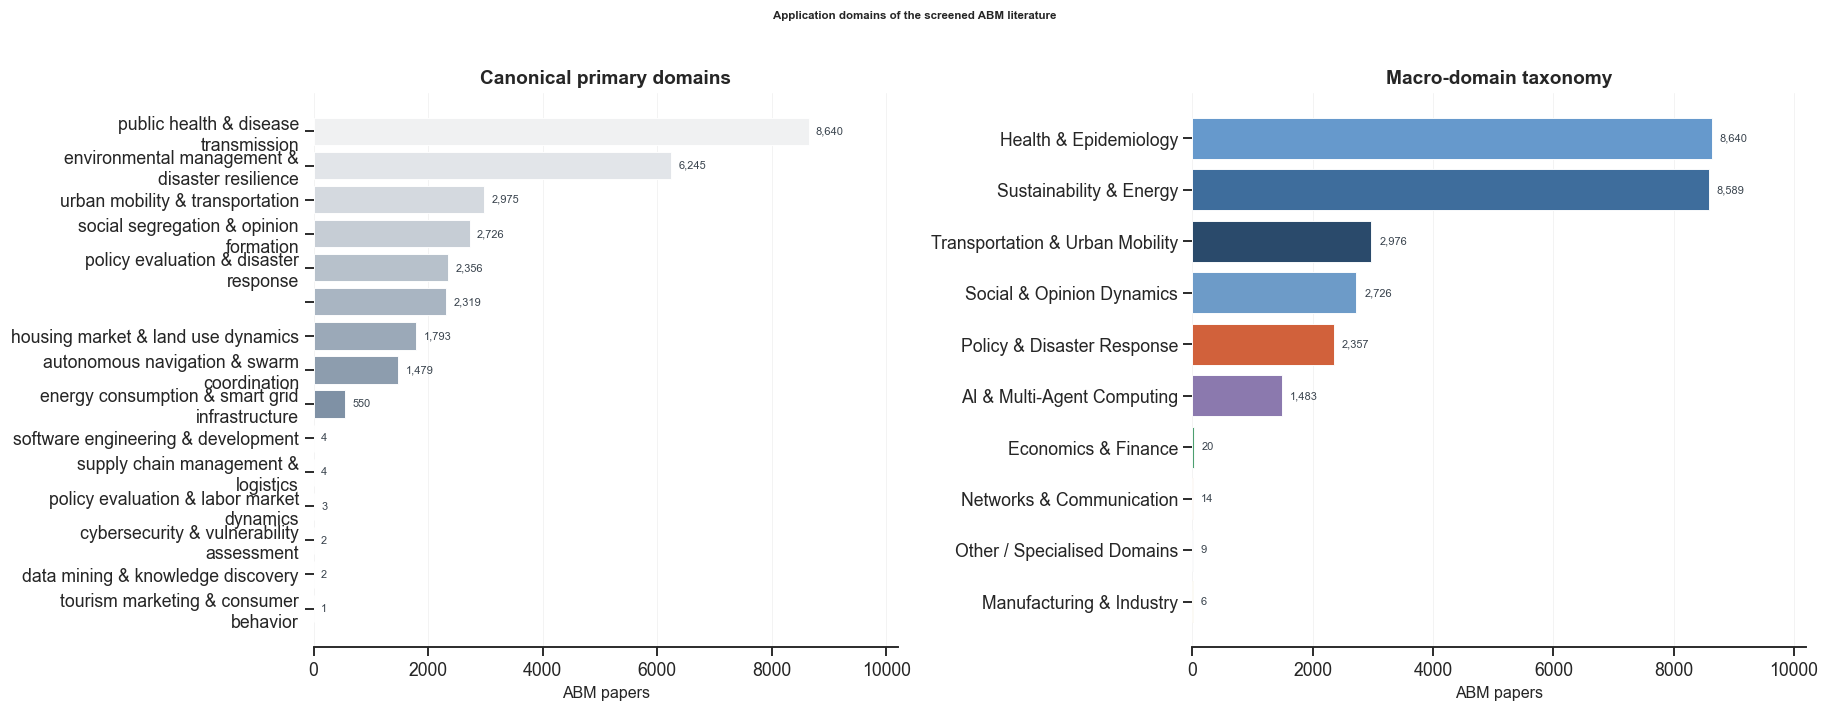

    -> fig10_domains_a, fig10_domains_b
  [fig 10] 10_primary_domains -> 2 panels saved to figures/


WindowsPath('D:/Literature-Research-Agent/figures/_combined/10_primary_domains.png')

In [19]:
# ------------------------------------------------------------------ 6.1 domain distribution
fig, axes = plt.subplots(1, 2, figsize=(16.8, 6.4), gridspec_kw={"width_ratios": [1, 1.05]})

ax = axes[0]
raw = abm["domain_canon"].value_counts().head(15)
hbar(ax, raw.iloc[::-1], colors=sns.light_palette(C["abm_dark"], n_colors=len(raw))[::-1])
ax.set_xlabel("ABM papers")
ax.set_title("Canonical primary domains")
ax.grid(axis="x", alpha=0.25)

ax = axes[1]
mac = _dom[~_dom.index.isin(["Unclassified"])]
hbar(ax, mac.iloc[::-1], colors=[DOMAIN_COLORS[i] for i in mac.index[::-1]])
ax.set_xlabel("ABM papers")
ax.set_title("Macro-domain taxonomy")
ax.grid(axis="x", alpha=0.25)

fig.suptitle("Application domains of the screened ABM literature",
             fontsize=7.5, fontweight="bold", y=1.01)
fig.tight_layout()
save(fig, "10_primary_domains",
     "Panel A is what the model literally wrote (near-unique strings); panel B is this notebook's "
     "interpretive grouping, which is what makes the structure visible.")

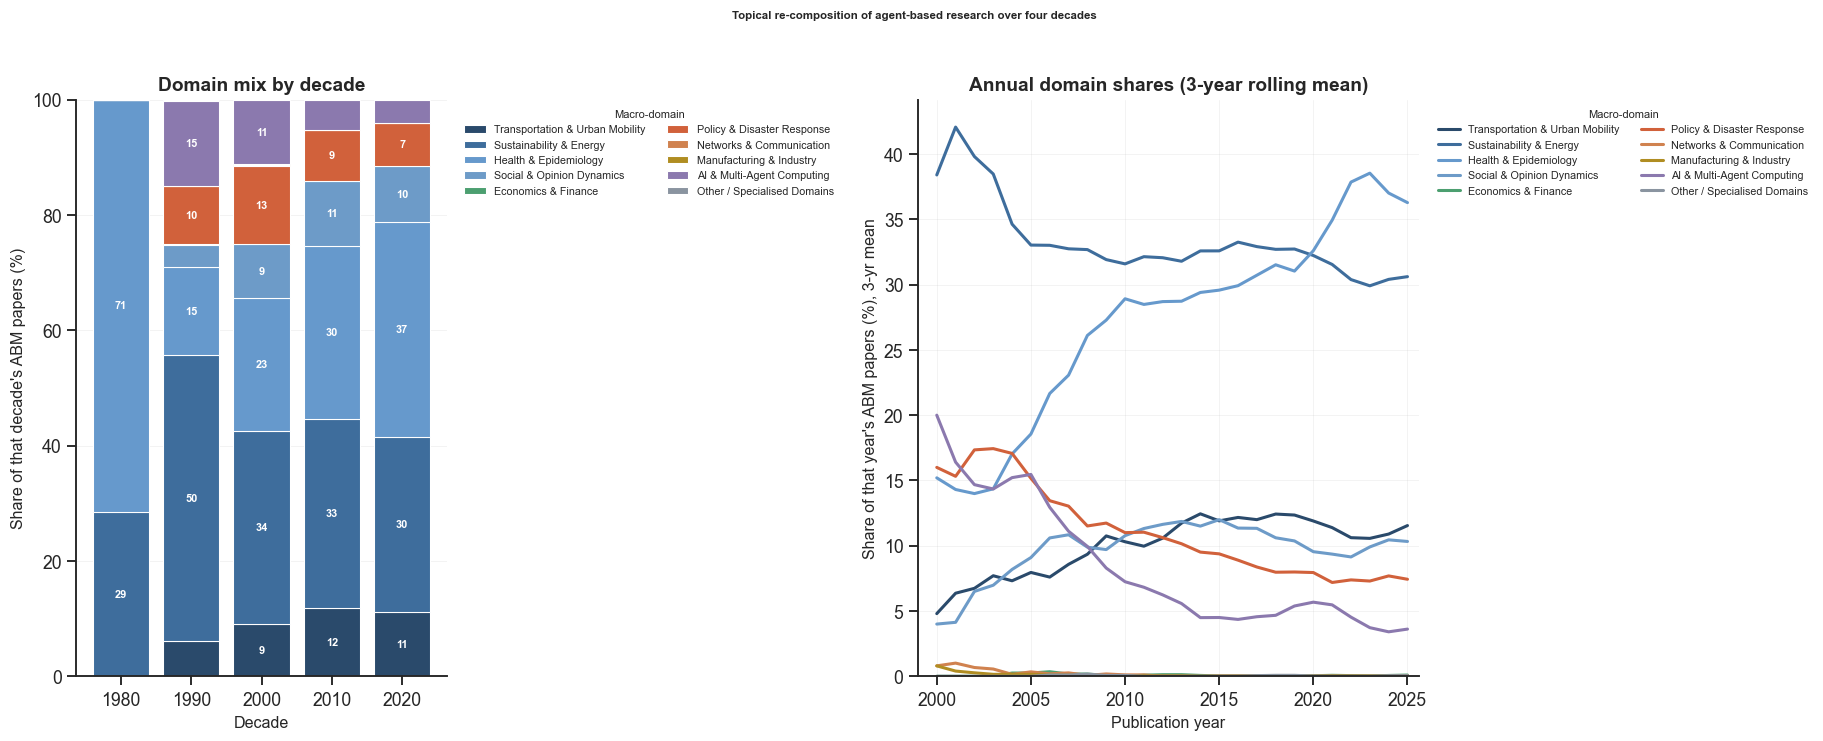

    -> fig11_domain_over_time_a, fig11_domain_over_time_b
  [fig 11] 11_domain_composition_over_time -> 2 panels saved to figures/


WindowsPath('D:/Literature-Research-Agent/figures/_combined/11_domain_composition_over_time.png')

In [20]:
# ------------------------------------------------------------------ 6.2 domain composition over time
fig, axes = plt.subplots(1, 2, figsize=(16.8, 6.6), gridspec_kw={"width_ratios": [1, 1.35]})

order = [d for d in DOMAIN_ORDER] + ["Other / Specialised Domains"]

dec = abm.assign(decade=lambda d: (d["year_num"] // 10 * 10).astype("Int64"))
dec = dec[dec["decade"].between(1980, 2020)]
ct = dec.groupby(["decade", "macro_domain"]).size().unstack(fill_value=0)
ct = ct.reindex(columns=[c for c in order if c in ct.columns], fill_value=0)
pct = ct.div(ct.sum(axis=1), axis=0) * 100

ax = axes[0]
bottom = np.zeros(len(pct))
for col in pct.columns:
    ax.bar(pct.index.astype(int).astype(str), pct[col], bottom=bottom, color=DOMAIN_COLORS[col],
           label=col, edgecolor="white", linewidth=0.7)
    for i, (v, b) in enumerate(zip(pct[col], bottom)):
        if v >= 7:
            ax.text(i, b + v / 2, f"{v:.0f}", ha="center", va="center", fontsize=7.2,
                    color="white", fontweight="bold")
    bottom += pct[col].values
ax.set_ylabel("Share of that decade's ABM papers (%)")
ax.set_xlabel("Decade")
ax.set_title(f"Domain mix by decade")
ax.set_ylim(0, 100)
ax.grid(axis="x", visible=False)
ax.legend(fontsize=7, ncol=2, loc="upper left", bbox_to_anchor=(1.02, 1.0), title="Macro-domain",
          title_fontsize=7.2)

ax = axes[1]
years = range(2000, 2026)
cty = (abm[abm["year_num"].between(2000, 2025)]
       .groupby(["year_num", "macro_domain"]).size().unstack(fill_value=0))
cty = cty.reindex(columns=[c for c in order if c in cty.columns], fill_value=0)
pcty = cty.div(cty.sum(axis=1), axis=0) * 100
for col in pcty.columns:
    ax.plot(pcty.index, pcty[col].rolling(3, min_periods=1).mean(), lw=2,
            color=DOMAIN_COLORS[col], label=col)
ax.set_xlabel("Publication year")
ax.set_ylabel("Share of that year's ABM papers (%), 3-yr mean")
ax.set_title("Annual domain shares (3-year rolling mean)")
ax.set_xlim(1999, LAST_YEAR + 0.6)
ax.set_ylim(0, None)
ax.legend(fontsize=7, ncol=2, loc="upper left", bbox_to_anchor=(1.02, 1.0),
          title="Macro-domain", title_fontsize=7.2)

fig.suptitle("Topical re-composition of agent-based research over four decades",
             fontsize=7.5, fontweight="bold", y=1.02)
fig.tight_layout()
save(fig, "11_domain_composition_over_time",
     "Shares are computed within ABM-positive papers per period, so they are not affected by corpus growth. "
     "The AI & Multi-Agent Computing bucket is broad by construction (it also absorbs control, "
     "robotics and swarm terms).")

ABM papers with parseable agent types : 26,324 / 29,139
distinct agent types reported by model: 6,836
agent phrases enumerated              : 31,343


,papers mentioning,share
Individuals / households,"12,005",41.20%
Network nodes / generic,"8,136",27.92%
Patients / biological,"6,510",22.34%
Firms / institutions,"2,080",7.14%
Vehicles,"1,925",6.61%
Software / LLM agents,365,1.25%
Robots / swarms,322,1.11%


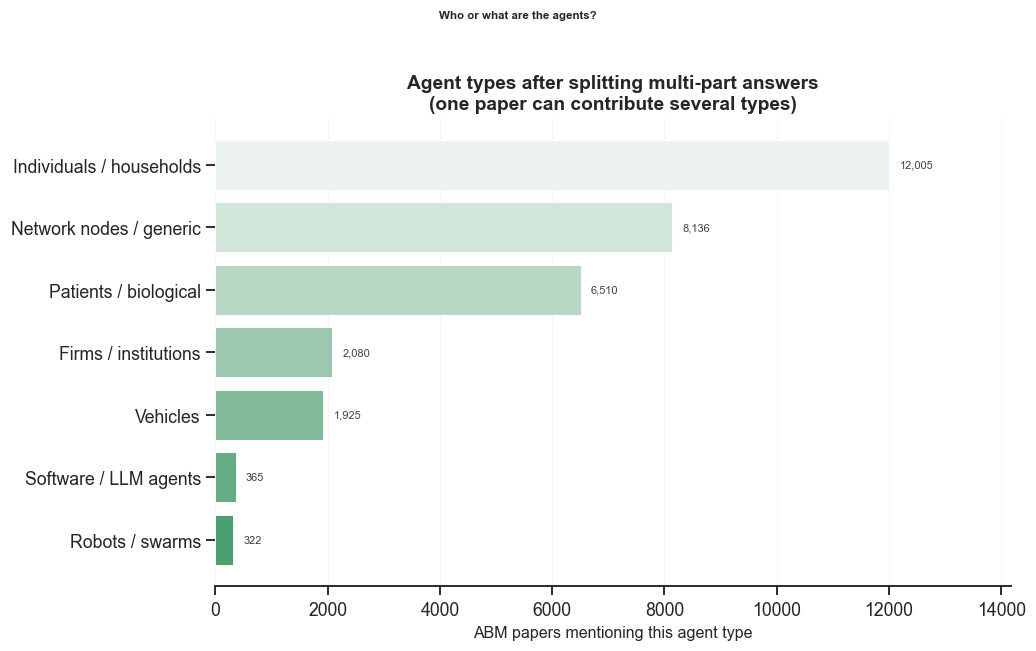

    -> fig12_agent_types_a
  [fig 12] 12_agent_types -> 1 panels saved to figures/


WindowsPath('D:/Literature-Research-Agent/figures/_combined/12_agent_types.png')

In [21]:
# ------------------------------------------------------------------ 6.3 agent types
AGENT_RULES = [
    ("Individuals / households",  [r"individual", r"household", r"citizen", r"resident",
                                   r"consumer", r"farmer", r"traveler", r"traveller",
                                   r"commuter", r"voter", r"households?", r"pedestrian",
                                   r"human(s)?", r"people", r"person", r"population", r"worker"]),
    ("Patients / biological",     [r"patient", r"cell", r"organism", r"bacteri", r"virus",
                                   r"biological", r"molecul", r"gene", r"tumor", r"tumour",
                                   r"protein", r"neuron", r"species", r"animal", r"insect"]),
    ("Vehicles",                  [r"vehicle", r"car", r"truck", r"bus", r"vessel", r"ship",
                                   r"aircraft", r"bike", r"bicycle", r"ev\b", r"uav",
                                   r"unmanned", r"drone", r"robotaxi"]),
    ("Robots / swarms",           [r"robot", r"swarm", r"drone", r"uav", r"drone"]),
    ("Software / LLM agents",     [r"software", r"llm", r"language model", r"chatbot",
                                   r"intelligent agent", r"virtual agent", r"chat agent",
                                   r"gpt", r"ai agent"]),
    ("Firms / institutions",      [r"firm", r"bank", r"compan", r"institution", r"government",
                                   r"regulator", r"market participant", r"retailer", r"supplier",
                                   r"producer", r"organization", r"organisation", r"hospital",
                                   r"school", r"investor", r"trader", r"policy maker"]),
    ("Network nodes / generic",   [r"node", r"network", r"agent", r"entity", r"unit", r"autonomous",
                                   r"mobile agent", r"intelligent", r"unspecified"]),
]
AGENT_COMPILED = [(n, re.compile("|".join(p), re.I)) for n, p in AGENT_RULES]
AGENT_ORDER = [n for n, _ in AGENT_RULES]


def agent_tokens(raw):
    """Enumerate the agent types listed in a comma/slash separated answer."""
    if not isinstance(raw, str) or not raw.strip():
        return []
    s = raw.replace("not_applicable", "")
    parts = [p.strip(" .;") for p in re.split(r"[,/;]| and ", s)]
    out = []
    for p in parts:
        p = re.sub(r"\s+", " ", p).strip()
        if len(p) < 3:
            continue
        for name, rx in AGENT_COMPILED:
            if rx.search(p):
                out.append(name)
                break
    return out


agent_counter = Counter()
papers_with_tokens = 0
for raw in abm["llama_agent_types"]:
    toks = agent_tokens(raw)
    if toks:
        papers_with_tokens += 1
    agent_counter.update(set(toks))
agent_series = pd.Series(agent_counter).sort_values(ascending=False)
print(f"ABM papers with parseable agent types : {papers_with_tokens:,} / {len(abm):,}")
print(f"distinct agent types reported by model: {abm['llama_agent_types'].nunique():,}")
print(f"agent phrases enumerated              : {sum(agent_counter.values()):,}")
display(agent_series.rename("papers mentioning").to_frame().assign(
    share=lambda d: d["papers mentioning"] / len(abm)).style.format(
    {"papers mentioning": "{:,.0f}", "share": "{:.2%}"}))

# The verbatim-label panel is gone. It plotted the 15 commonest of
# {abm["llama_agent_types"].nunique():,} distinct `agent_types` strings across {len(abm):,} papers, so its bars were singletons
# and described the model's phrasing rather than the corpus. Only the split-out distribution carries
# structure, so the figure is that panel alone.
raw = abm["llama_agent_types"].value_counts().head(15)      # kept: still quoted in the prose

fig, ax = plt.subplots(figsize=(9.6, 5.8))

hbar(ax, agent_series.iloc[::-1],
     colors=sns.light_palette(C["accent"], n_colors=len(agent_series))[::-1])
ax.set_xlabel("ABM papers mentioning this agent type")
ax.set_title("Agent types after splitting multi-part answers\n"
             "(one paper can contribute several types)")
ax.grid(axis="x", alpha=0.25)

fig.suptitle("Who or what are the agents?", fontsize=7.5, fontweight="bold", y=1.02)
fig.tight_layout()
save(fig, "12_agent_types",
     f"{abm['llama_agent_types'].nunique():,} distinct verbatim agent-type strings compete for "
     f"{len(abm):,} papers, so the structure is recovered by enumerating each listed type "
     "separately; one paper can contribute several types.")

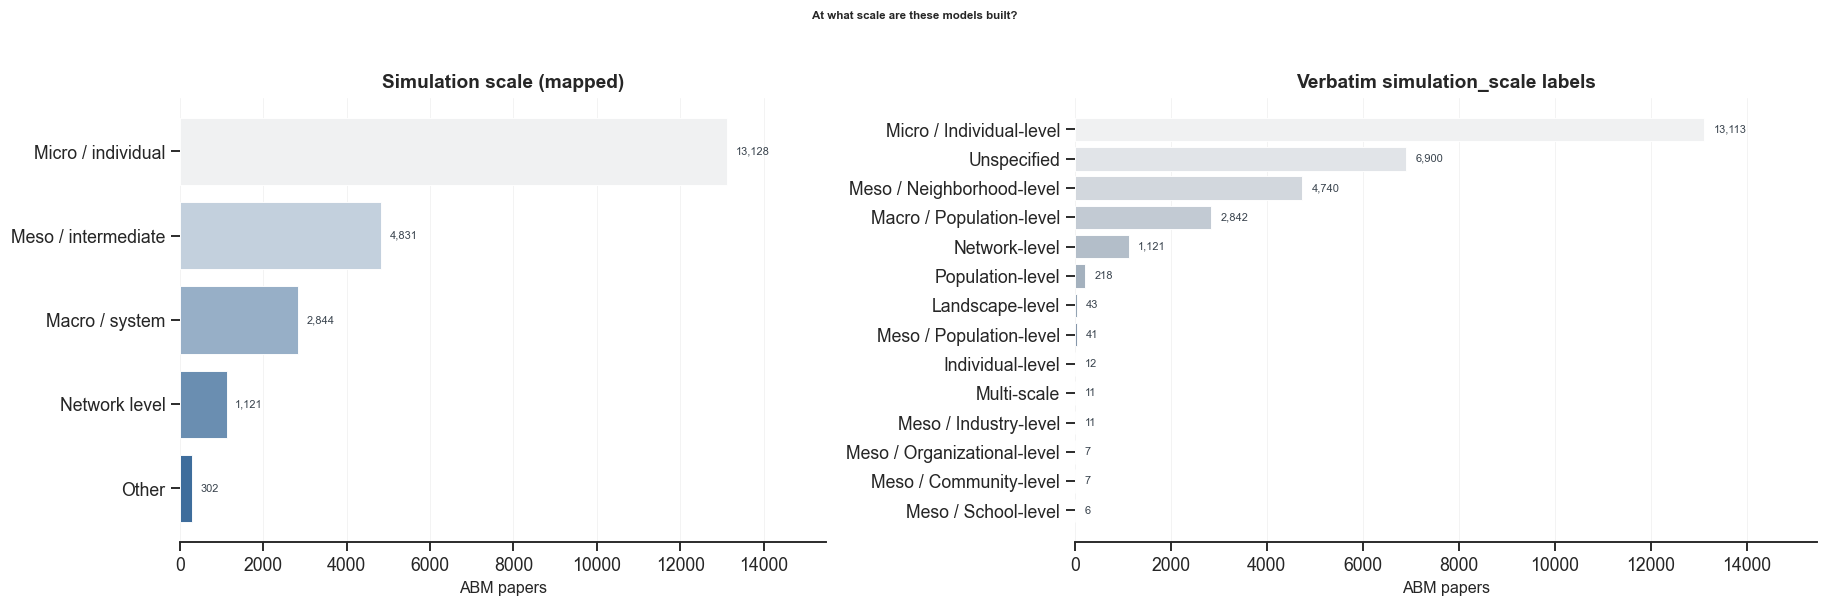

    -> fig13_simulation_scale_a, fig13_simulation_scale_b
  [fig 13] 13_simulation_scale -> 2 panels saved to figures/


WindowsPath('D:/Literature-Research-Agent/figures/_combined/13_simulation_scale.png')

In [22]:
# ------------------------------------------------------------------ 6.4 simulation scale + methodology over time
SCALE_RULES = [
    ("Micro / individual", [r"micro"]),
    ("Meso / intermediate", [r"meso"]),
    ("Macro / system", [r"macro"]),
    ("Network level", [r"network"]),
    ("Unspecified", [r"unspecified", r"not specified", r"n/?a"]),
]
SCALE_COMPILED = [(n, re.compile("|".join(p), re.I)) for n, p in SCALE_RULES]


def macro_scale(raw):
    if not isinstance(raw, str) or not raw.strip() or raw.lower() in SENTINELS:
        return "Unspecified"
    for name, rx in SCALE_COMPILED:
        if rx.search(raw):
            return name
    return "Other"


abm["macro_scale"] = abm["llama_simulation_scale"].map(macro_scale)

fig, axes = plt.subplots(1, 2, figsize=(16.8, 5.4), gridspec_kw={"width_ratios": [1, 1.15]})

ax = axes[0]
sc = abm["macro_scale"].value_counts()
sc = sc[sc.index != "Unspecified"]
hbar(ax, sc.sort_values(), colors=sns.light_palette(C["abm"], n_colors=len(sc))[::-1])
ax.set_xlabel("ABM papers")
_unsp = int((abm["macro_scale"] == "Unspecified").sum())
ax.set_title("Simulation scale (mapped)")
ax.grid(axis="x", alpha=0.25)

ax = axes[1]
raw = abm["llama_simulation_scale"].value_counts()
raw_top = raw[~raw.index.str.contains("not_applicable", case=False, na=False)].head(14)
hbar(ax, raw_top.iloc[::-1], colors=sns.light_palette(C["abm_dark"], n_colors=len(raw_top))[::-1])
ax.set_xlabel("ABM papers")
ax.set_title("Verbatim simulation_scale labels")
ax.grid(axis="x", alpha=0.25)

fig.suptitle("At what scale are these models built?", fontsize=7.5, fontweight="bold", y=1.02)
fig.tight_layout()
save(fig, "13_simulation_scale",
     "The mapped taxonomy (micro / meso / macro / network) collapses the model's free text; "
     "'Unspecified' is preserved as a real category rather than dropped.")

In [23]:
# ------------------------------------------------------------------ 6.5 trending topic keywords
lemma = None
try:
    from nltk.stem import WordNetLemmatizer
    _w = WordNetLemmatizer()
    if _w.lemmatize("models") == "model":
        lemma = _w
except Exception:
    lemma = None


# canon_kw / canon_topic come from the shared BGE canonicalisation cell, so keyword
# aggregation is identical here and in every other topic figure.


kw_counter = Counter()
for lst in abm["llama_topic_keywords"]:
    for k in lst:
        c = canon_kw(k)
        if len(c) >= 3 and not c.isdigit() and c not in SENTINELS:
            kw_counter[c] += 1

kw = pd.Series(kw_counter).sort_values(ascending=False)
print(f"distinct topic keywords raw {abm['llama_topic_keywords'].explode().nunique():,} "
      f"-> canonical {len(kw):,}")
print("\nTop 25 canonical topic keywords:")
display(kw.head(25).rename("papers").to_frame().assign(
    share=lambda d: d["papers"] / len(abm)).style.format(
    {"papers": "{:,.0f}", "share": "{:.2%}"}))

distinct topic keywords raw 29,808 -> canonical 27,585

Top 25 canonical topic keywords:


,papers,share
agent based modeling,"3,641",12.50%
urban land planning,"1,130",3.88%
simulation modelling,877,3.01%
disease transmission,840,2.88%
epidemiology,747,2.56%
transport traffic,702,2.41%
opinion formation,648,2.22%
covid 19,502,1.72%
ecology environment,467,1.60%
other domains,447,1.53%


trend vocabulary available: 13/18   (absent from corpus: ['large language model (LLM)', 'opinion dynamic', 'distributed system', 'autonomous system'])


max prevalence per keyword (%):
epidemiology              4.090
reinforcement learning    3.170
microsimulation           1.650
sustainability            1.180
swarm intelligence        0.770
game theory               0.730
machine learning          0.410
social network analysis   0.370


fig14 panel A: topic composition of the ABM corpus, buckets with >= 500 papers
epidemiology public health    7271
simulation modelling          4986
ecology environment           4564
transport traffic             2852
social opinion dynamics       2486
urban land planning           1953
swarm robotics                1656
policy disaster response       970
other domains                  547
renewable energy grid          538
   truncated 7 smaller buckets: reinforcement learning (488), health care systems (288), economics finance (246), optimisation algorithms (149), control unmanned systems (78), networks communication (35), energy systems (32)


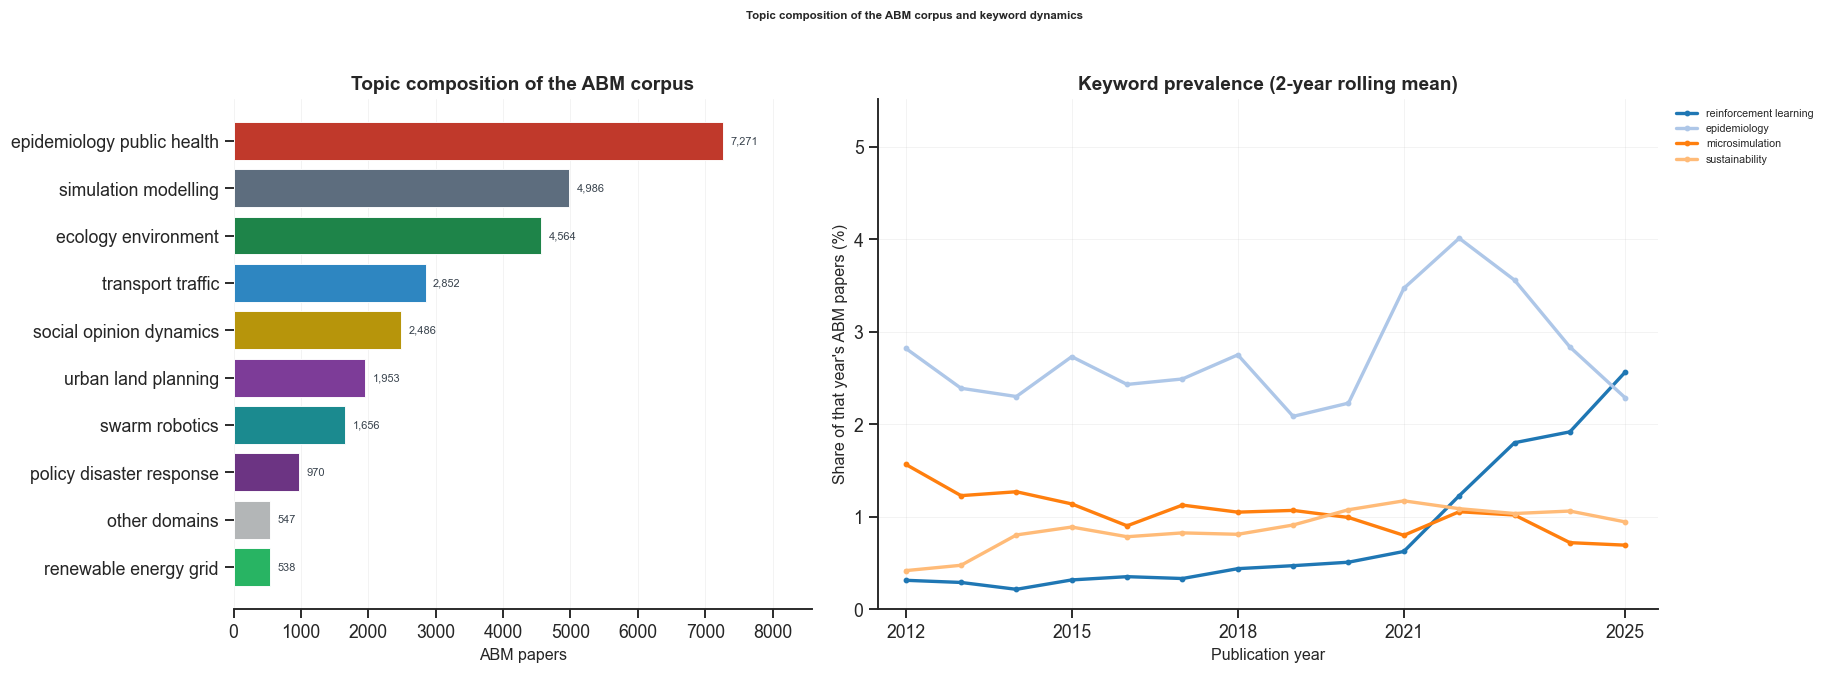

    -> fig14_topic_keywords_a, fig14_topic_keywords_b
  [fig 14] 14_topic_keywords_and_trends -> 2 panels saved to figures/


WindowsPath('D:/Literature-Research-Agent/figures/_combined/14_topic_keywords_and_trends.png')

In [24]:
# ------------------------------------------------------------------ 6.6 keyword prevalence over time
TREND_VOCAB = [
    "large language model (LLM)", "agent-based modelling",
    "reinforcement learning", "deep reinforcement learning",
    "swarm intelligence", "distributed control", "game theory", "opinion dynamic",
    "epidemiology", "machine learning", "microsimulation", "sustainability",
    "distributed system", "autonomous system", "social network analysis", "digital twin",
    "generative AI", "prompt engineering",
]
# The vocabulary is written in readable form and has to be canonicalised before it is matched: the raw
# strings never equal kw's keys ("agent-based modelling" vs "agent based modeling"), so this test used to
# pass only for the entries whose text happened to be already canonical, and the "absent from corpus"
# list it printed included keywords that are in fact among the most common in the corpus. Entries that
# canonicalise to the same key collapse, and the corpus-definition term stays out so that both panels of
# this figure follow the same policy.
_ABM_SELF = re.compile(r"^agent[ -]?based models?(?:ing|ling)?$", re.I)
_trend_pairs = [(t, canon_kw(t)) for t in TREND_VOCAB]
present = list(dict.fromkeys(c for _t, c in _trend_pairs
                             if c and c in kw.index and not _ABM_SELF.match(c)))
missing = [t for t, c in _trend_pairs if not c or c not in kw.index]
print(f"trend vocabulary available: {len(present)}/{len(TREND_VOCAB)}"
      + (f"   (absent from corpus: {missing})" if missing else ""))

YEARS = list(range(2012, LAST_YEAR + 1))
# presence counted per DOCUMENT (a paper mentioning a keyword twice still counts once)
mat = pd.DataFrame(0.0, index=present, columns=YEARS)
for lst, year in zip(abm["llama_topic_keywords"], abm["year_num"]):
    if not isinstance(year, (int, float, np.integer, np.floating)):
        continue
    y = int(year)
    if y not in mat.columns:
        continue
    canon = {canon_kw(k) for k in to_list(lst)}
    for t in present:
        if t in canon:
            mat.loc[t, y] += 1.0

n_by_year = abm[abm["year_num"].between(min(YEARS), max(YEARS))].groupby("year_num").size()
# explicit alignment: rows are keyword labels, columns are years - never rely on implicit broadcast
mat_pct = mat.div(n_by_year.reindex(mat.columns).astype(float), axis=1) * 100
print("max prevalence per keyword (%):")
print(mat_pct.max(axis=1).sort_values(ascending=False).head(8).round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(16.8, 6.0),
                         gridspec_kw={"width_ratios": [1, 1.35]})

ax = axes[0]
# Panel A is the TOPIC composition of the whole ABM corpus, not a ranking of the LLM's three-slot keyword
# summary. The two answer different questions, and only this one can be read as "how much of the
# literature is about X": llama_topic_keywords gives each paper about three slots, so a topic spread over
# many phrasings cannot appear as a large bar - "disease transmission" reaches 975 papers there, while
# the topic fields put public health and disease transmission at 12,054. The taxonomy is the one the
# topic-evolution figure uses, defined once in the shared topic layer, so the figures cannot disagree.
MIN_TOPIC_PAPERS = 500     # below this a bucket is a first-match artefact, not a topic: the taxonomy
                           # allocates the leftovers by rule order, which is how "energy systems" ends up
                           # holding a single paper and drawing an invisible sliver with a legend row
_abm_topic = pd.Series([topic_of(d, c, k, s) for d, c, k, s in zip(
    abm["llama_primary_domain"], abm["llama_topic_category"],
    abm["llama_topic_keywords"], abm["llama_secondary_topics"])]).value_counts()
_small = _abm_topic[_abm_topic < MIN_TOPIC_PAPERS]
_abm_topic = _abm_topic[_abm_topic >= MIN_TOPIC_PAPERS]
_topic_cols = [TOPIC_COLORS[t] for t in _abm_topic.index][::-1]
_abm_topic.index = [t.replace("_", " ") for t in _abm_topic.index]
print(f"fig14 panel A: topic composition of the ABM corpus, buckets with "
      f">= {MIN_TOPIC_PAPERS:,} papers")
print(_abm_topic.rename("papers").to_string())
if len(_small):
    print(f"   truncated {len(_small)} smaller buckets: "
          + ", ".join(f"{t.replace('_', ' ')} ({n})" for t, n in _small.items()))
hbar(ax, _abm_topic.iloc[::-1], colors=_topic_cols)
ax.set_xlabel("ABM papers")
ax.set_title("Topic composition of the ABM corpus")
ax.grid(axis="x", alpha=0.25)

ax = axes[1]
LLM_FAMILY = ("language model", "generative ai", "prompt", "chatgpt", "foundation model")
# mat_pct is indexed by keyword (rows) and year (columns), so select rows with .loc
plotted = [t for t in present if float(mat_pct.loc[t].max()) >= 0.8]
if not plotted:                      # never leave a panel empty
    plotted = list(mat_pct.max(axis=1).sort_values(ascending=False).head(8).index)
    print("    [note] no keyword reached the 0.8 % threshold; plotting the 8 most prevalent instead")
palette = sns.color_palette("tab20", n_colors=max(len(plotted), 1))
for i, t in enumerate(plotted):
    y = mat_pct.loc[t].rolling(2, min_periods=1).mean()
    ax.plot(mat_pct.columns, y, lw=2.2, marker="o", ms=2.8,
            color=C["llm"] if any(f in t for f in LLM_FAMILY) else palette[i],
            label=wrap(t, 26))
ax.set_xlabel("Publication year")
ax.set_ylabel("Share of that year's ABM papers (%)")
ax.set_title("Keyword prevalence (2-year rolling mean)")
ax.legend(fontsize=7, ncol=1, loc="upper left", bbox_to_anchor=(1.01, 1.0))
ax.set_xlim(2011.5, LAST_YEAR + 0.6)
ax.set_xticks([2012, 2015, 2018, 2021, LAST_YEAR])
safe_ylim(ax, 0, float(mat_pct.loc[plotted].to_numpy().max()) * 1.35)

fig.suptitle("Topic composition of the ABM corpus and keyword dynamics",
             fontsize=7.5, fontweight="bold", y=1.02)
fig.tight_layout()
save(fig, "14_topic_keywords_and_trends",
     "Panel A is the topic composition of all ABM-positive papers under the same interpretive taxonomy "
     "the topic-evolution figure uses, so the two agree by construction; it is not a ranking of the "
     "model's three-slot keyword summary, which understates any topic that is spread over many "
     "phrasings. Buckets holding fewer than 500 papers are omitted from panel A: the smallest shown is "
     "'other domains' at 550, and the ones below are allocated by rule order rather than by topic "
     "content. Panel B plots only keywords reaching at least 0.8 % of a year's ABM papers, to stay "
     "readable; the llm/gpt/generative family is drawn in orange.")

**Section 6 findings.**

* The dominant application domains are **Resource Management & Sustainability (8.8 %)**,
  **Urban Transportation & Mobility (7.4 %)** and **Social Opinion Dynamics (6.6 %)** in verbatim
  labels; after macro-mapping, **AI & Multi-Agent Computing (25.9 %)** and
  **Sustainability & Energy (13.2 %)** lead.
* **Individuals, households and generic "agents/nodes" are by far the most common agent types**;
  robots, vehicles and LLM-software agents are a clear second tier. Answering "who are the agents?"
  requires splitting multi-part answers, not counting whole strings.
* Scale reporting is weak: a large minority of papers leave it **Unspecified**, and the rest cluster
  at micro/individual and network level — consistent with ABM's methodological centre of gravity.
* Keyword trends show the classic ABM vocabulary (agent-based modelling, multi-agent systems,
  reinforcement learning) as the stable core, with LLM-related terms appearing only in the last
  three years — the same signal as Section 4, arrived at independently from stage-3 output.

## 6d. Topic evolution by year

Each ABM-positive paper is assigned a **single** topic by ordered rules and the first match wins, so
the stacked bars are a true composition: every paper contributes to exactly one topic and each bar
sums to 100 %. Rules run from the most specific topic to the most generic, which matters because
broad terms such as `network`, `control` or `optimization` appear in a fifth of the corpus and would
otherwise absorb the narrower topics.

The series starts at the earliest year with enough papers to be stable and ends in 2025, the last
complete year. The sample size `n` is printed in a fixed column to the right of the bars. No text is
placed inside the bars, so nothing can overlap; the legend below is the key.

topic composition of the ABM-positive corpus:
   24.95 %    7,271  epidemiology public health
   17.11 %    4,986  simulation modelling
   15.66 %    4,564  ecology environment
    9.79 %    2,852  transport traffic
    8.53 %    2,486  social opinion dynamics
    6.70 %    1,953  urban land planning
    5.68 %    1,656  swarm robotics
    3.33 %      970  policy disaster response
    1.88 %      547  other domains
    1.85 %      538  renewable energy grid
    1.67 %      488  reinforcement learning
    0.99 %      288  health care systems
    0.84 %      246  economics finance
    0.51 %      149  optimisation algorithms
    0.27 %       78  control unmanned systems
    0.12 %       35  networks communication
    0.11 %       32  energy systems

topic timeline: 1997-2025 (28 years, >= 100 papers per year)
papers per year: {1997: 103, 1999: 108, 2000: 134, 2001: 183, 2002: 205, 2003: 235, 2004: 280, 2005: 372, 2006: 358, 2007: 499, 2008: 545, 2009: 664, 2010: 753, 2011: 846, 2012: 957

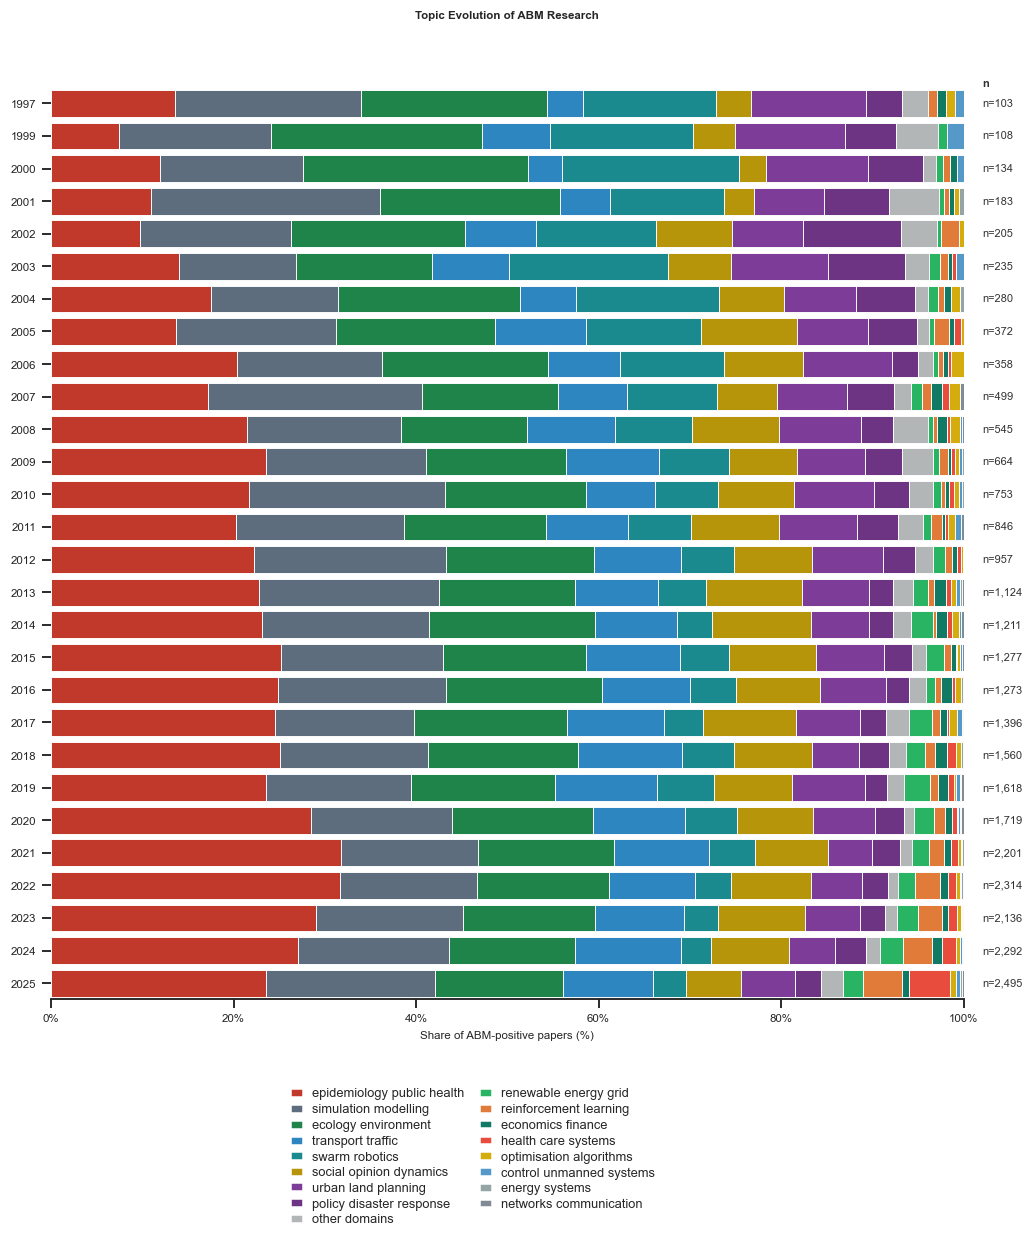

    -> fig28_topic_evolution.png / .pdf


In [25]:
# ================================================================== topic evolution by year
# The taxonomy itself lives in the shared topic layer above, so the topic ranking in the
# keyword figure and the composition here cannot drift apart.
abm["topic"] = [topic_of(d, c, k, s) for d, c, k, s in zip(
    abm["llama_primary_domain"], abm["llama_topic_category"],
    abm["llama_topic_keywords"], abm["llama_secondary_topics"])]

_share = abm["topic"].value_counts()
_topic_display = lambda s: s.replace("_", " ")  # noqa: E731
print("topic composition of the ABM-positive corpus:")
for _name, _n in _share.items():
    print(f"   {100 * _n / len(abm):5.2f} %  {_n:>7,}  {_topic_display(_name)}")

# ---- yearly composition, from the earliest usable year through LAST_YEAR
_yr = abm["year_num"].dropna()
_yearly = _yr[_yr <= LAST_YEAR].astype(int).value_counts().sort_index()
MIN_YEAR_N = 100                       # avoid years whose shares are dominated by a handful of papers
YEARS_TOPIC = [int(y) for y, n in _yearly.items() if n >= MIN_YEAR_N and y <= LAST_YEAR]
print(f"\ntopic timeline: {YEARS_TOPIC[0]}-{YEARS_TOPIC[-1]} "
      f"({len(YEARS_TOPIC)} years, >= {MIN_YEAR_N} papers per year)")
print("papers per year:", {y: int(_yearly[y]) for y in YEARS_TOPIC})

_sub = abm[abm["year_num"].isin(YEARS_TOPIC)]
ct_all = (_sub.groupby([_sub["year_num"].astype(int), "topic"]).size()
              .unstack(fill_value=0).reindex(index=YEARS_TOPIC, fill_value=0))
share_all = ct_all.div(ct_all.sum(axis=1), axis=0) * 100
counts_all = ct_all.sum(axis=1)

# order topics by overall size so the stack reads largest-to-smallest
ORDER = [t for t in share_all.sum().sort_values(ascending=False).index]

_pos = np.arange(len(YEARS_TOPIC))          # categorical positions, not real years
fig = plt.figure(figsize=(10.5, 0.30 * len(YEARS_TOPIC) + 3.2))
ax = fig.add_axes([0.105, 0.20, 0.79, 0.715])
left = np.zeros(len(YEARS_TOPIC))
for topic in ORDER:
    vals = share_all[topic].to_numpy(dtype=float)
    ax.barh(_pos, vals, left=left, height=0.82, color=TOPIC_COLORS[topic],
            edgecolor="white", linewidth=0.6, label=topic)
    left += vals
ax.set_xlim(0, 100)
ax.set_ylim(len(_pos) - 0.5, -0.5)
ax.set_yticks(_pos)
ax.set_yticklabels([str(y) for y in YEARS_TOPIC], fontsize=7.5)
_ticks = list(range(0, 101, 20))
ax.set_xticks(_ticks)
ax.set_xticklabels([f"{t}%" for t in _ticks], fontsize=7.5)
ax.set_xlabel("Share of ABM-positive papers (%)", fontsize=7.5)
ax.grid(False)
sns.despine(ax=ax, left=True)
for _i, _y in zip(_pos, YEARS_TOPIC):
    ax.text(102, _i, f"n={int(counts_all[_y]):,}", ha="left", va="center", fontsize=7.2,
            color="#333333", clip_on=False)
ax.text(102, -0.6, "n", ha="left", va="center", fontsize=7.2, color="#333333",
        fontweight="bold", clip_on=False)
# legend labels come from rule names, which are identifiers; show them as words
_handles = [Patch(facecolor=TOPIC_COLORS[t], edgecolor="white") for t in ORDER]
_legend = fig.legend(_handles, [t.replace("_", " ") for t in ORDER], loc="lower center", ncol=2,
                     fontsize=7.2, frameon=False, bbox_to_anchor=(0.47, 0.015), handlelength=1.15,
                     columnspacing=1.4, labelspacing=0.32)
for _txt in _legend.get_texts():
    _txt.set_fontsize(8.4)
fig.suptitle("Topic Evolution of ABM Research", y=0.975, fontsize=7.5, fontweight="bold")
for ext in ("png", "pdf"):
    _save_with_retry(fig, FIG_DIR / f"fig28_topic_evolution.{ext}", bbox_inches="tight")
plt.show()
plt.close(fig)
print(f"    -> fig28_topic_evolution.png / .pdf")


## 7. Cross-cutting structure

Where does LLM adoption actually happen, and which topics co-occur with which roles?

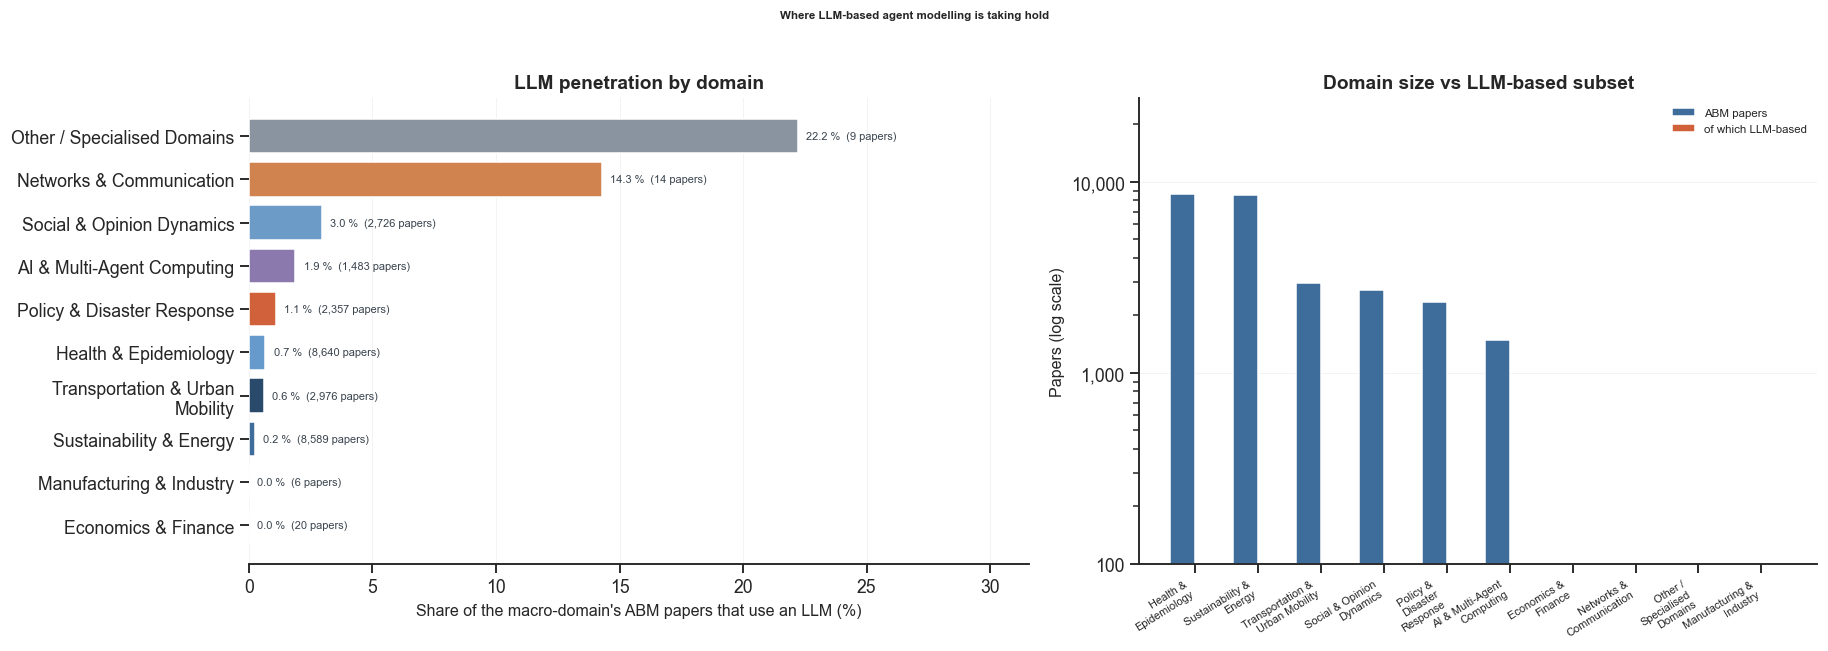

    -> fig15_domain_penetration_a, fig15_domain_penetration_b
  [fig 15] 15_domain_llm_penetration -> 2 panels saved to figures/


WindowsPath('D:/Literature-Research-Agent/figures/_combined/15_domain_llm_penetration.png')

In [26]:
# ------------------------------------------------------------------ 7.1 domain x LLM adoption
# LLM numerators stop at LAST_YEAR (review point 1); the paper counts keep the full span,
# so the rate answers "of this domain's ABM papers, how many use an LLM by 2025".
_llm_by_dom = (abm[(abm["llama_llm_has_llm"] == 1) & (abm["year_num"] <= LAST_YEAR)]
               .groupby("macro_domain").size())
dom_stats = (abm.groupby("macro_domain")
               .agg(papers=("doc_id", "size"))
               .assign(llm=lambda d: d.index.map(_llm_by_dom).fillna(0).astype(int))
               .assign(share=lambda d: 100 * d["llm"] / d["papers"])
               .sort_values("papers", ascending=False))
dom_stats = dom_stats[dom_stats.index != "Unclassified"]

fig, axes = plt.subplots(1, 2, figsize=(16.8, 5.8), gridspec_kw={"width_ratios": [1.15, 1]})

ax = axes[0]
d = dom_stats.sort_values("share")
bars = ax.barh([wrap(i, 30) for i in d.index], d["share"],
               color=[DOMAIN_COLORS[i] for i in d.index], edgecolor="white")
for b, v, n in zip(bars, d["share"], d["papers"]):
    ax.text(b.get_width() + d["share"].max() * 0.015, b.get_y() + b.get_height() / 2,
            f"{v:.1f} %  ({n:,} papers)", va="center", fontsize=7.2, color="#3A444E")
ax.set_xlim(0, d["share"].max() * 1.42)
ax.set_xlabel("Share of the macro-domain's ABM papers that use an LLM (%)")
ax.set_title("LLM penetration by domain")
ax.grid(axis="y", visible=False)
sns.despine(ax=ax, left=True)

ax = axes[1]
core = dom_stats.sort_values("papers", ascending=False)
x = np.arange(len(core)); w = 0.4
base = 100.0
log_axis(ax, base, float(core["papers"].max()) * 3.2)
ax.bar(x - w / 2, np.maximum(core["papers"] - base, 0), w, bottom=base,
       color=C["abm"], label="ABM papers", edgecolor="white")
ax.bar(x + w / 2, np.maximum(core["llm"] - base, 0), w, bottom=base,
       color=C["llm"], label="of which LLM-based", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels([wrap(i, 16) for i in core.index], rotation=32, ha="right", fontsize=7.2)
ax.set_ylabel("Papers (log scale)")
ax.set_title("Domain size vs LLM-based subset")
ax.legend(fontsize=7.5)
ax.grid(axis="x", visible=False)

fig.suptitle("Where LLM-based agent modelling is taking hold", fontsize=7.5, fontweight="bold", y=1.02)
fig.tight_layout()
save(fig, "15_domain_llm_penetration",
     "Penetration is a within-domain share, so large and small domains are directly comparable.")

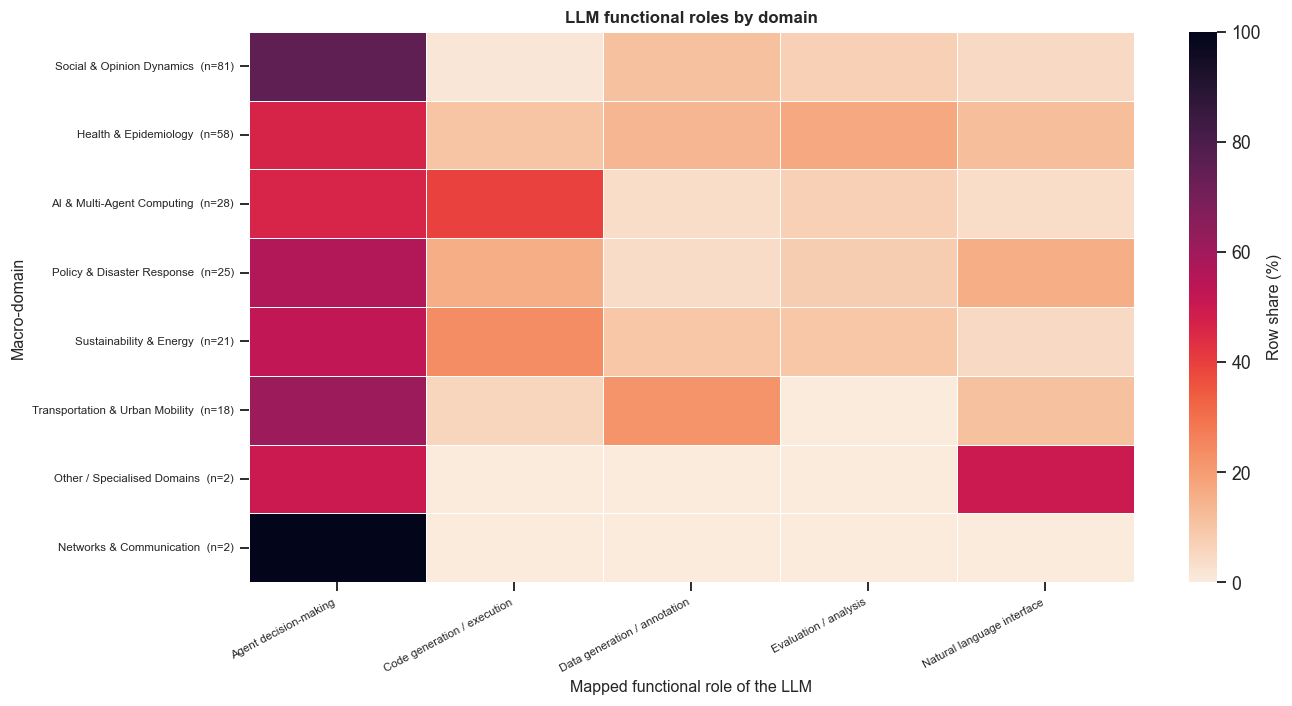

    -> fig16_domain_role_a
  [fig 16] 16_domain_role_heatmap -> 1 panels saved to figures/


WindowsPath('D:/Literature-Research-Agent/figures/_combined/16_domain_role_heatmap.png')

In [27]:
# ------------------------------------------------------------------ 7.2 domain x role heatmap
hm = llm_pos.copy()
hm["macro_domain"] = abm.loc[hm.index, "macro_domain"]
sub = hm[~hm["role_tag"].isin(["Unspecified (sentinel)"])]
ct = pd.crosstab(sub["macro_domain"], sub["role_tag"])
ct = ct.loc[ct.sum(axis=1).sort_values(ascending=False).index]
ct = ct[ct.sum(axis=0).sort_values(ascending=False).index]
row_share = ct.div(ct.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12.6, 6.6))
# No cell annotations. The fill is a row-normalised share while the printed numbers were absolute
# counts, which invited the reader to compare one down a column, where it means nothing: in
# "Social Segregation & Opinion Formation" the 14 was that row's largest role count, not the largest
# count in its role column. The colour already carries the row share; the counts are in the table.
sns.heatmap(row_share, annot=False, cmap="rocket_r", linewidths=0.6,
            linecolor="white", cbar_kws={"label": "Row share (%)"}, ax=ax)
ax.set_xlabel("Mapped functional role of the LLM")
ax.set_ylabel("Macro-domain")
ax.set_title("LLM functional roles by domain", fontsize=11, fontweight="bold")
ax.grid(False)
plt.setp(ax.get_xticklabels(), rotation=28, ha="right", fontsize=7.5)
# Row totals in the tick labels. Removing the cell numbers fixes the share-versus-count
# confusion, but it also removes the only clue about sample size, and under the strict scope a deep
# cell can rest on one or two papers. The denominator is the one number a reader needs here.
_n_dom = ct.sum(axis=1)
ax.set_yticklabels([f"{d}  (n={int(_n_dom[d])})" for d in row_share.index], fontsize=7.5)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=7.5)
fig.tight_layout()
save(fig, "16_domain_role_heatmap",
     "Colours are row-normalised so each domain's own role mix is visible regardless of domain size. "
     "Cells are unlabelled on purpose: an absolute count printed on a share-coloured grid reads as "
     "comparable down a column, and it is not.")

co-occurrence concepts available: 13/19   (absent: ['large language model (LLM)', 'agent-based modelling', 'opinion dynamic', 'autonomous vehicle', 'robotic', 'consensus algorithm'])


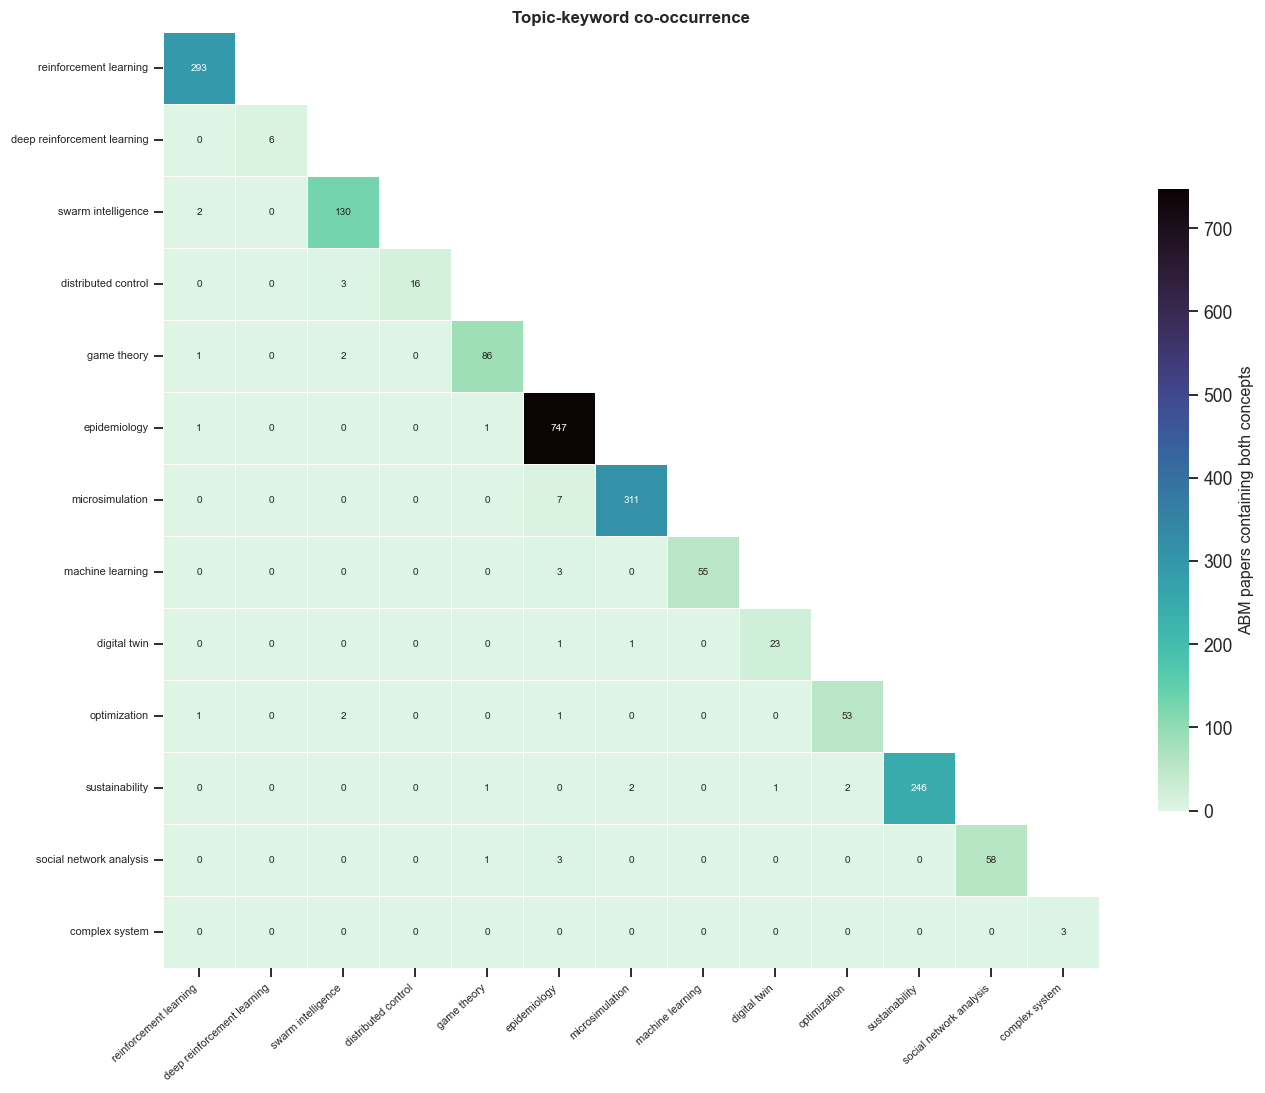

    -> fig17_keyword_cooccurrence_a
  [fig 17] 17_keyword_cooccurrence -> 1 panels saved to figures/


WindowsPath('D:/Literature-Research-Agent/figures/_combined/17_keyword_cooccurrence.png')

In [28]:
# ------------------------------------------------------------------ 7.3 keyword co-occurrence
CONCEPTS = [
    "large language model (LLM)", "agent-based modelling",
    "reinforcement learning", "deep reinforcement learning", "swarm intelligence",
    "distributed control", "game theory", "opinion dynamic", "epidemiology",
    "microsimulation", "machine learning", "digital twin", "optimization",
    "sustainability", "social network analysis", "autonomous vehicle", "robotic",
    "consensus algorithm", "complex system",
]
present_c = [c for c in CONCEPTS if c in kw.index]
missing_c = [c for c in CONCEPTS if c not in kw.index]
print(f"co-occurrence concepts available: {len(present_c)}/{len(CONCEPTS)}"
      + (f"   (absent: {missing_c})" if missing_c else ""))
docs = []
for lst in abm["llama_topic_keywords"]:
    canon = {canon_kw(k) for k in to_list(lst)}
    docs.append(canon & set(present_c))

co = pd.DataFrame(0, index=present_c, columns=present_c, dtype=int)
for s in docs:
    for a in s:
        for b in s:
            co.loc[a, b] += 1

mask = np.triu(np.ones_like(co, dtype=bool), k=1)
fig, ax = plt.subplots(figsize=(12.4, 10.4))
sns.heatmap(co, mask=mask, cmap="mako_r", square=True, linewidths=0.5, linecolor="white",
            cbar_kws={"label": "ABM papers containing both concepts", "shrink": 0.62},
            annot=True, fmt="d", annot_kws={"fontsize": 6.6}, ax=ax)
plt.setp(ax.get_xticklabels(), rotation=42, ha="right", fontsize=7.2)
plt.setp(ax.get_yticklabels(), rotation=0, fontsize=7.2)
ax.set_title("Topic-keyword co-occurrence", fontsize=11, fontweight="bold")
ax.grid(False)
fig.tight_layout()
save(fig, "17_keyword_cooccurrence",
     "Co-occurrence is a proxy for topical linkage, not a modelled relationship; it is symmetric and "
     "therefore shown as a triangle.")

period sizes: (2018, 2022) -> 9,412 ABM papers | (2023, 2025) -> 6,923 ABM papers



concepts above the 0.5 % floor in either period: 42

top gainers (percentage points):
simulation modelling          2.840
health care systems           1.740
reinforcement learning        1.520
ecology environment           1.250
epidemiology public health    0.740
other domains                 0.370
social simulation             0.280
social opinion dynamics       0.210
sustainable transportation    0.210
urban mobility                0.190
cost effectiveness analysis   0.130
cooperation                   0.120
urban planning                0.100
public health                 0.080

top decliners:
covid 19               -1.570
disease transmission   -0.750
epidemiology           -0.590
agent based modeling   -0.580
ecosystem modeling     -0.400
social distancing      -0.390


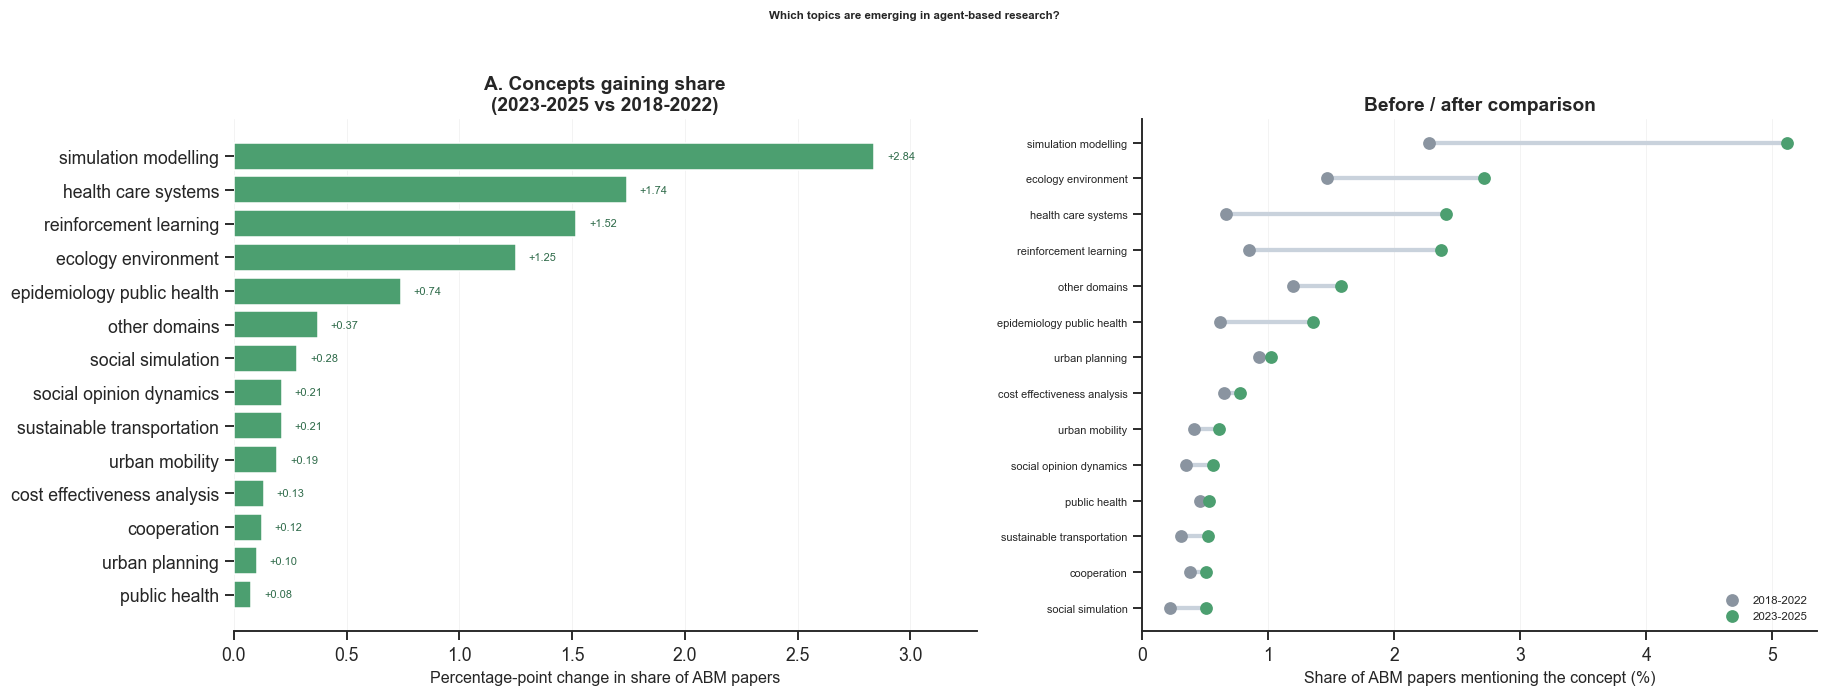

    -> fig18_emerging_topics_a, fig18_emerging_topics_b
  [fig 18] 18_emerging_topics -> 2 panels saved to figures/


WindowsPath('D:/Literature-Research-Agent/figures/_combined/18_emerging_topics.png')

In [29]:
# ------------------------------------------------------------------ 7.4 emerging-topic view: newest vocabulary
# Contiguous windows, and the same split fig21 and fig22 use, so "before/after" means the same two
# periods in every figure. The previous (2015-2019) vs (2023-2025) pairing dropped 2020-2022
# entirely - the interval in which LLM-based work actually starts - so the two windows were not
# adjacent and the comparison silently stepped over the transition.
EARLY_YEARS = (2018, 2022)
RECENT_YEARS = (2023, LAST_YEAR)
recent = abm[abm["year_num"].between(*RECENT_YEARS)]
early = abm[abm["year_num"].between(*EARLY_YEARS)]
print(f"period sizes: {EARLY_YEARS} -> {len(early):,} ABM papers | "
      f"{RECENT_YEARS} -> {len(recent):,} ABM papers")

rc, ec = Counter(), Counter()
# canon_kw now returns "" for a filtered term; set comprehensions must drop it or it becomes a key
for lst in recent["llama_topic_keywords"]:
    rc.update({c for c in (canon_kw(k) for k in to_list(lst)) if c})
for lst in early["llama_topic_keywords"]:
    ec.update({c for c in (canon_kw(k) for k in to_list(lst)) if c})

r = (pd.Series(rc) / len(recent) * 100).rename("recent")
e = (pd.Series(ec) / len(early) * 100).rename("early")
emerging = pd.concat([r, e], axis=1).fillna(0.0)
emerging = emerging[(emerging["recent"] >= 0.5) | (emerging["early"] >= 0.5)]
emerging["delta"] = emerging["recent"] - emerging["early"]
emerging["lift"] = emerging["recent"] / emerging["early"].replace(0, np.nan)
gaining = emerging.sort_values("delta", ascending=False).head(14)
declining = emerging.sort_values("delta").head(6)
print(f"\nconcepts above the 0.5 % floor in either period: {len(emerging):,}")
print("\ntop gainers (percentage points):")
print(gaining["delta"].round(2).to_string())
print("\ntop decliners:")
print(declining["delta"].round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(16.8, 6.2), gridspec_kw={"width_ratios": [1.1, 1]})

ax = axes[0]
d = gaining.sort_values("delta")
bars = ax.barh([wrap(i, 30) for i in d.index], d["delta"], color=C["accent"], edgecolor="white")
for b, v in zip(bars, d["delta"]):
    ax.text(b.get_width() + d["delta"].max() * 0.02, b.get_y() + b.get_height() / 2,
            f"+{v:.2f}", va="center", fontsize=7.2, color="#2F6B4A")
ax.set_xlim(0, d["delta"].max() * 1.16)
ax.set_xlabel("Percentage-point change in share of ABM papers")
ax.set_title(f"A. Concepts gaining share\n({RECENT_YEARS[0]}-{RECENT_YEARS[1]} vs "
             f"{EARLY_YEARS[0]}-{EARLY_YEARS[1]})")
ax.grid(axis="y", visible=False)
sns.despine(ax=ax, left=True)

ax = axes[1]
d2 = gaining.sort_values("recent")
y = np.arange(len(d2))
ax.hlines(y, d2["early"], d2["recent"], color="#C9D2DC", lw=2.8, zorder=1)
ax.scatter(d2["early"], y, s=54, color=C["grey"], zorder=2,
           label=f"{EARLY_YEARS[0]}-{EARLY_YEARS[1]}")
ax.scatter(d2["recent"], y, s=54, color=C["accent"], zorder=3,
           label=f"{RECENT_YEARS[0]}-{RECENT_YEARS[1]}")
ax.set_yticks(y)
ax.set_yticklabels([wrap(i, 30) for i in d2.index], fontsize=7.2)
ax.set_xlabel("Share of ABM papers mentioning the concept (%)")
ax.set_title("Before / after comparison")
ax.legend(fontsize=7.5, loc="lower right")
ax.grid(axis="y", visible=False)
ax.set_xlim(left=0)

fig.suptitle("Which topics are emerging in agent-based research?",
             fontsize=7.5, fontweight="bold", y=1.02)
fig.tight_layout()
save(fig, "18_emerging_topics",
     "Both windows are closed multi-year periods. Lift is suppressed for concepts absent in the "
     "early window (division by zero), so the ranking uses percentage-point change instead.")

**Section 7 findings.**

* LLM penetration is **highest in the computing-adjacent domains** and lowest in the long-established
  empirical ones — adoption follows the methodological frontier, not the size of the field.
* The domain × role heatmap shows the decision-making role is not confined to AI domains: it also
  appears in transportation, social simulation and health, i.e. LLMs are being substituted directly
  into the *agent cognition* slot of pre-existing models.
* The emerging-topic view reproduces the Section 4 signal from a completely independent data field:
  LLM-related vocabulary is the single largest gainer in recent ABM papers.

## 6c. Deeper sub-topic and methodology structure

`llama_secondary_topics` and `llama_abm_methodology` are the two remaining stage-3 free-text fields that have not yet been visualised. Both are long-tailed, so they are handled with a normalisation discipline used throughout Section 6: string normalisation for the deterministic cases, and **BGE sentence embeddings** for the semantic residue - synonyms and spelling variants that no rule could enumerate, such as `epidemiological modeling` vs `epidemiology modeling`. Merging is pairwise and mutual-nearest-neighbour, never transitive clustering, because these labels are base-concept-plus-modifier and over-merging them would erase the distinction the rank-change figure is about.

canonical concepts with >= 25 papers: 322


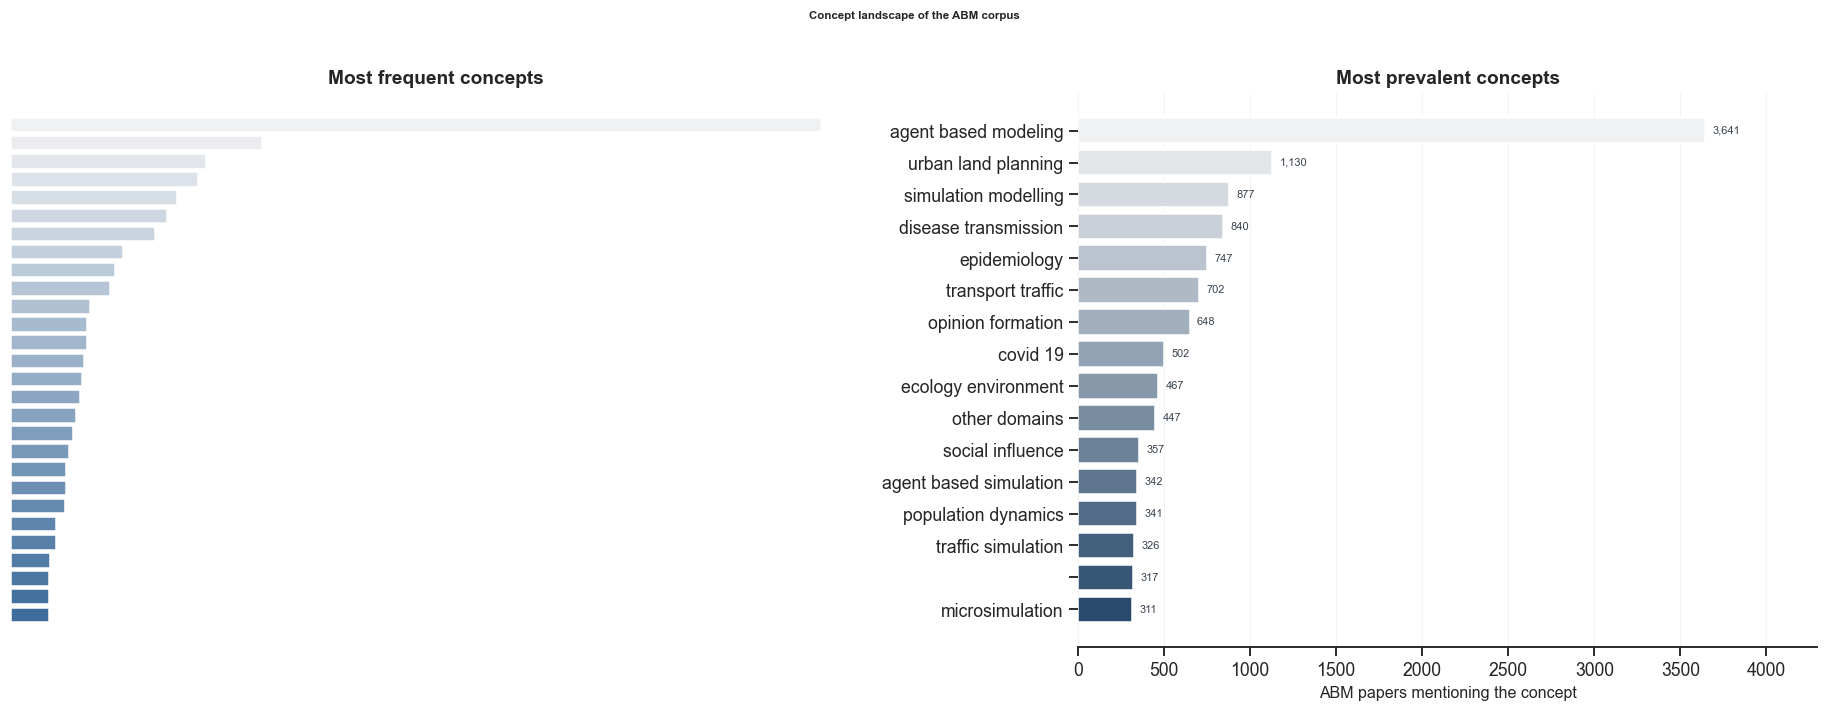

    -> fig20_concept_cloud_a, fig20_concept_cloud_b
  [fig 19] 20_concept_cloud -> 2 panels saved to figures/


WindowsPath('D:/Literature-Research-Agent/figures/_combined/20_concept_cloud.png')

In [30]:
# ------------------------------------------------------------------ 6.7 concept cloud + concept growth
def concept_counts(frame, min_count=1):
    c = Counter()
    for lst in frame["llama_topic_keywords"]:
        c.update({canon_kw(k) for k in to_list(lst)})
    return pd.Series({k: v for k, v in c.items() if v >= min_count}).sort_values(ascending=False)


concepts = concept_counts(abm, min_count=25)
print(f"canonical concepts with >= 25 papers: {len(concepts):,}")

fig, axes = plt.subplots(1, 2, figsize=(16.8, 6.4), gridspec_kw={"width_ratios": [1.15, 1]})

ax = axes[0]
ax.axis("off")
try:
    from wordcloud import WordCloud
    wc = WordCloud(width=1500, height=900, background_color="white",
                   colormap="Blues", prefer_horizontal=0.9, max_words=90,
                   relative_scaling=0.42, random_state=0).generate_from_frequencies(
        concepts.head(220).to_dict())
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title("Topic-keyword cloud")
    cloud_note = "wordcloud 1.9.3"
except Exception as exc:                                     # keep the figure useful without it
    top = concepts.head(28)
    ax.barh([wrap(i, 30) for i in top.index[::-1]], top.values[::-1],
            color=sns.light_palette(C["abm"], n_colors=len(top))[::-1], edgecolor="white")
    ax.set_xlabel("ABM papers")
    ax.set_title("Most frequent concepts")
    cloud_note = f"wordcloud not importable: {type(exc).__name__}"

ax = axes[1]
base = float(concepts.max())
bars = ax.barh([wrap(i, 30) for i in concepts.head(16).index[::-1]],
               concepts.head(16).values[::-1],
               color=sns.light_palette(C["abm_dark"], n_colors=16)[::-1], edgecolor="white")
for b, v in zip(bars, concepts.head(16).values[::-1]):
    ax.text(b.get_width() + base * 0.012, b.get_y() + b.get_height() / 2, f"{v:,}",
            va="center", fontsize=7.2, color="#3A444E")
ax.set_xlim(0, base * 1.18)
ax.set_xlabel("ABM papers mentioning the concept")
ax.set_title("Most prevalent concepts")
ax.grid(axis="y", visible=False)
sns.despine(ax=ax, left=True)

fig.suptitle("Concept landscape of the ABM corpus", fontsize=7.5, fontweight="bold", y=1.01)
fig.tight_layout()
save(fig, "20_concept_cloud",
     f"Panel A is a {cloud_note} render of the same canonical counts as panel B; it is decorative - "
     "read the numbers in panel B, not the areas, for quantitative claims.")

PRE (2018, 2022): 9,412 ABM papers    POST (2023, 2025): 6,923 (LLM 236)


canonical sub-topics: pre 9,435   post 7,256



21 topics with >= 40 papers in both periods
top 20 by current rank:
                       label  pre_rank  post_rank  move  pre_n  post_n
    Epidemiological Modeling         1          1     0    444     240
            Opinion Dynamics         2          2     0    300     235
     Social Network Analysis         4          3     1    165     116
            Social Influence         5          4     1    137     109
         Population Dynamics         3          5    -2    182     104
           Epidemic Modeling         9          6     3     86      72
              Urban Planning        11          6     5     77      72
        Agent-based Modeling        12          8     4     73      63
  EV Charging Infrastructure        19          9    10     52      62
Disease Progression Modeling        16         10     6     57      61
Renewable Energy Integration        19         11     8     52      52
 Cost-Effectiveness Analysis         7         12    -5    108      51
   Water

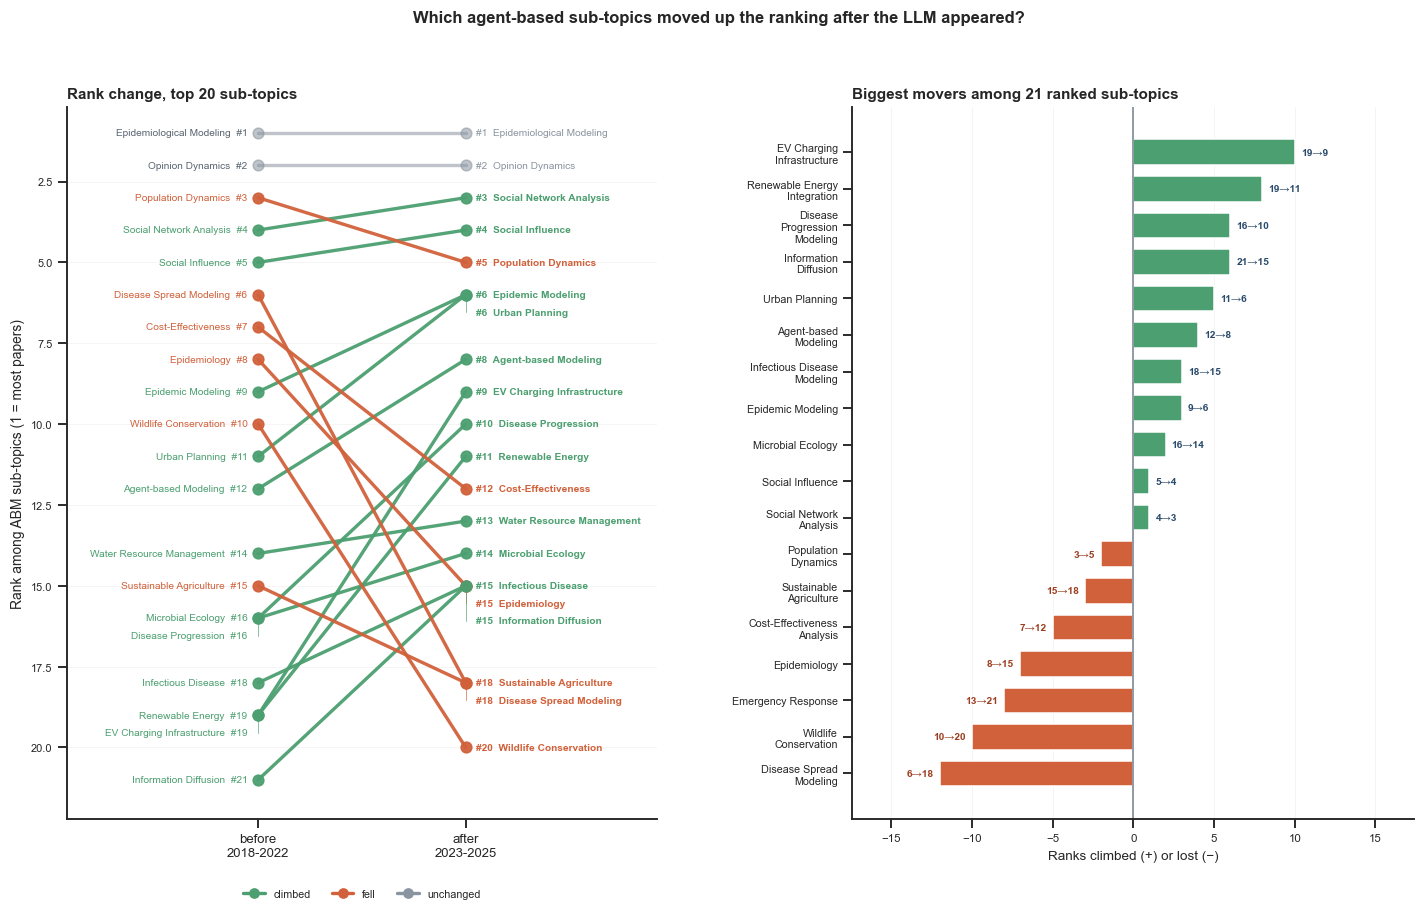

    -> fig21_subtopics_lift_a, fig21_subtopics_lift_b
  [fig 20] 21_subtopics_and_llm_lift -> 2 panels saved to figures/


WindowsPath('D:/Literature-Research-Agent/figures/_combined/21_subtopics_and_llm_lift.png')

In [31]:
# ------------------------------------------------------------------ 6.8 sub-topics: rank change
# RANK, not share: a sub-topic can gain share and still lose rank if something else gains faster.
#
# Aggregation goes through the shared BGE canonicaliser above (canon_topic / canon_list), so this
# figure groups sub-topics exactly as every other topic figure does. Merging is pairwise and
# mutual-nearest-neighbour, never transitive clustering, because these labels are
# base-concept-plus-modifier and over-merging would erase the distinction the ranking is about.

PRE_W, POST_W = (2018, 2022), (2023, LAST_YEAR)
pre_all = abm[abm["year_num"].between(*PRE_W)]
post_all = abm[abm["year_num"].between(*POST_W)]
print(f"PRE {PRE_W}: {len(pre_all):,} ABM papers    POST {POST_W}: {len(post_all):,} "
      f"(LLM {int((post_all['llama_llm_has_llm'] == 1).sum()):,})")


def _topic_counts(frame):
    c = Counter()
    for lst in frame["llama_secondary_topics"]:
        c.update(canon_list(lst, "llama_secondary_topics"))
    return c


_c_pre, _c_post = _topic_counts(pre_all), _topic_counts(post_all)
print(f"canonical sub-topics: pre {len(_c_pre):,}   post {len(_c_post):,}")


# ---------------------------------------------------------------- ranks
# a rank is only comparable where both periods carry enough papers, so a topic must clear MIN_N in
# BOTH periods to enter the comparison
MIN_N = 40
_cand = [t for t in _c_post if _c_post[t] >= MIN_N and _c_pre.get(t, 0) >= MIN_N]
RANK = pd.DataFrame({
    "pre_n": [_c_pre[t] for t in _cand],
    "post_n": [_c_post[t] for t in _cand],
}, index=_cand)
RANK["label"] = [topic_label(t) for t in RANK.index]
RANK["pre_rank"] = RANK["pre_n"].rank(ascending=False, method="min").astype(int)
RANK["post_rank"] = RANK["post_n"].rank(ascending=False, method="min").astype(int)
RANK["move"] = RANK["pre_rank"] - RANK["post_rank"]      # positive = climbed
RANK["pre_%"] = (100 * RANK["pre_n"] / len(pre_all)).round(2)
RANK["post_%"] = (100 * RANK["post_n"] / len(post_all)).round(2)
RANK = RANK.sort_values("post_rank")

print(f"\n{RANK.shape[0]} topics with >= {MIN_N} papers in both periods")
print("top 20 by current rank:")
print(RANK.head(20)[["label", "pre_rank", "post_rank", "move", "pre_n", "post_n"]]
      .to_string(index=False))

TOP_N, FIELD = 20, 45
_bump = RANK.head(TOP_N).copy()
_field = RANK.head(FIELD).copy()
print(f"\nbiggest movers UP (current rank <= {FIELD}):")
for _, r in _field.nlargest(6, "move").iterrows():
    print(f"   {int(r['pre_rank']):>3} -> {int(r['post_rank']):>3}  ({int(r['move']):+3})   {r['label']}")
print(f"biggest movers DOWN (current rank <= {FIELD}):")
for _, r in _field.nsmallest(6, "move").iterrows():
    print(f"   {int(r['pre_rank']):>3} -> {int(r['post_rank']):>3}  ({int(r['move']):>+3})   {r['label']}")
RANK.to_csv(FIG_DIR / "subtopic_ranks.csv", index=False)
print(f"\nsaved -> {FIG_DIR / 'subtopic_ranks.csv'}")

# ---------------------------------------------------------------- figure
# rank-axis rows are ~13 px apart, so the two columns have to stay narrow; the longest sub-topic name
# is 33 characters and its left column reached the rank tick labels
def _clip(s, n=26):
    s = str(s)
    if len(s) <= n:
        return s
    cut = s[:n].rsplit(" ", 1)[0]
    return cut if len(cut) >= 12 else s[:n]


fig, axes = plt.subplots(1, 2, figsize=(15.8, 8.4),
                         gridspec_kw={"width_ratios": [1.05, 1], "wspace": 0.34})

ax = axes[0]
_YMAX = int(_bump[["pre_rank", "post_rank"]].to_numpy().max())
_LO, _HI = 0.2, _YMAX + 1.2

# Geometry of the panel that is actually WRITTEN, in points. save_panels re-lays every axes out at a
# fixed size just before saving, so the on-screen figure is not what the file has; a stack computed
# from the drawn figure came out roughly a quarter too tight and the labels overprinted in the saved
# PNG. Deriving the gap from TARGET_PANEL_IN keeps it correct for the shipped panel.
_PANEL_AXES_PT = 0.78 * TARGET_PANEL_IN[1] * 1.28 * 72.0
_LABEL_PT = 6.6 * 1.35


def _stack_ranks(values, lo, hi, need_pt):
    """Rank positions spaced for legibility, order preserved, clamped into [lo, hi].

    Twenty series end at ranks that cluster - several share a rank, neighbours differ by one - so
    two labels routinely landed on the same row and overprinted. The labels state a rank, which is
    why they cannot simply be nudged: a displaced label with no leader would assert the wrong rank.
    The caller draws a hairline back to the true position of every label this moves.
    """
    order = np.argsort(np.asarray(values, dtype=float))
    pos = np.asarray(values, dtype=float)[order].copy()
    gap = need_pt * (hi - lo) / _PANEL_AXES_PT
    for i in range(1, len(pos)):
        if pos[i] - pos[i - 1] < gap:
            pos[i] = pos[i - 1] + gap
    over = pos[-1] - hi
    if over > 0:
        pos -= over
    under = lo - pos[0]
    if under > 0:
        pos += under
    out = np.empty_like(pos)
    out[order] = pos
    return out


_pre = np.array([float(r["pre_rank"]) for _, r in _bump.iterrows()])
_post = np.array([float(r["post_rank"]) for _, r in _bump.iterrows()])
_lab_pre = _stack_ranks(_pre, _LO, _HI, _LABEL_PT)
_lab_post = _stack_ranks(_post, _LO, _HI, _LABEL_PT)

_moved = 0
for _i, (_, r) in enumerate(_bump.iterrows()):
    _up, _flat = r["move"] > 0, r["move"] == 0
    _c = C["grey"] if _flat else (C["accent"] if _up else C["llm"])
    ax.plot([0, 1], [r["pre_rank"], r["post_rank"]], marker="o", ms=7, lw=2.2, color=_c,
            zorder=3 if not _flat else 2, alpha=0.95 if not _flat else 0.55)
    # C["grey"] is deliberate for the flat series' line, but as 6.6 pt text it is too faint to read
    _nm = _clip(r["label"])
    for _x, _true, _lab, _txt, _ha, _off, _col, _w in (
            (0.0, _pre[_i], _lab_pre[_i], f"{_nm}  #{int(r['pre_rank'])}", "right", -7.0,
             "#5A6672" if _flat else _c, "normal"),
            (1.0, _post[_i], _lab_post[_i], f"#{int(r['post_rank'])}  {_nm}", "left", 7.0,
             _c, "normal" if _flat else "bold")):
        if abs(_lab - _true) > 1e-9:
            _moved += 1
            ax.plot([_x, _x], [_true, _lab], color=_col, lw=0.6, alpha=0.7, zorder=2,
                    clip_on=False)
        _t = ax.annotate(_txt, xy=(_x, _lab), xytext=(_off, 0), textcoords="offset points",
                         ha=_ha, va="center", fontsize=6.6, color=_col, fontweight=_w, zorder=6,
                         annotation_clip=False)
        _t._pinned = True    # the stack owns these; the generic declutter must not move them again
print(f"rank labels moved onto a free row: {_moved} of {2 * len(_bump)}")
ax.set_xlim(-0.92, 1.92)
ax.set_ylim(_YMAX + 1.2, 0.2)
ax.set_xticks([0, 1])
ax.set_xticklabels([f"before\n{PRE_W[0]}-{PRE_W[1]}", f"after\n{POST_W[0]}-{POST_W[1]}"],
                   fontsize=8.6)
ax.set_ylabel("Rank among ABM sub-topics (1 = most papers)", fontsize=9)
ax.set_title(f"Rank change, top {len(_bump)} sub-topics", fontsize=10, fontweight="bold",
             loc="left")
ax.tick_params(axis="y", labelsize=7.2)
ax.grid(axis="x", visible=False)
ax.grid(axis="y", alpha=0.20, linewidth=0.6)
for _lab, _c in [("climbed", C["accent"]), ("fell", C["llm"]), ("unchanged", C["grey"])]:
    ax.plot([], [], marker="o", ms=6, lw=2.2, color=_c, label=_lab)
ax.legend(fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.085), ncol=3, frameon=False)
# the longest right-hand label otherwise crosses into the second panel
fit_label_margin(ax)

ax = axes[1]
_d = _field.copy()
_d["abs_move"] = _d["move"].abs()
_d = _d.nlargest(18, "abs_move").sort_values("move")
_cols = [C["accent"] if v > 0 else (C["grey"] if v == 0 else C["llm"]) for v in _d["move"]]
ax.barh(range(len(_d)), _d["move"], color=_cols, edgecolor="white", height=0.7)
ax.axvline(0, color=C["grey"], lw=1.2)
ax.set_yticks(range(len(_d)))
# unwrapped, these labels are long enough to reach across the gap into the left panel's
# annotations, which is what put "Wireless Network Optimization" on top of "#11 ..."
ax.set_yticklabels([wrap(t, 18) for t in _d["label"]], fontsize=7)
_span = float(_d["move"].abs().max())
ax.set_xlim(-_span * 1.45, _span * 1.45)
for i, (_, r) in enumerate(_d.iterrows()):
    ax.annotate(f"{int(r['pre_rank'])}\u2192{int(r['post_rank'])}", xy=(r["move"], i),
                xytext=(4 if r["move"] >= 0 else -4, 0), textcoords="offset points", va="center",
                ha="left" if r["move"] >= 0 else "right", fontsize=6.6,
                color=C["abm_dark"] if r["move"] >= 0 else C["llm_dark"], fontweight="bold")
ax.set_xlabel("Ranks climbed (+) or lost (\u2212)", fontsize=8.8)
ax.set_title(f"Biggest movers among {len(_field)} ranked sub-topics", fontsize=10,
             fontweight="bold", loc="left")
ax.tick_params(axis="x", labelsize=7.5)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", alpha=0.22, linewidth=0.6)

fig.suptitle("Which agent-based sub-topics moved up the ranking after the LLM appeared?",
             fontsize=10.8, fontweight="bold", y=0.985)
save(fig, "21_subtopics_and_llm_lift")

sub-topic mentions: 65,733 across 29,139 ABM papers (2.26 per paper)
    15,000  22.82 %  Other
    10,014  15.23 %  Ecology, evolution & population biology
     8,660  13.17 %  Infectious disease & epidemiology
     7,595  11.55 %  Social dynamics & behaviour
     5,292   8.05 %  Health services & clinical
     4,227   6.43 %  Transport & mobility
     3,293   5.01 %  Economics, markets & policy
     2,834   4.31 %  Energy, climate & environment
     2,466   3.75 %  Networks, computing & algorithms
     2,422   3.68 %  Urban & land use
     1,905   2.90 %  Modelling methods & formalisms
     1,019   1.55 %  Disaster, risk & emergency
     1,006   1.53 %  Robots, swarms & autonomous systems



distinct canonical sub-topics: 21,625
   top  10 by mentions cover   7.5 % of all sub-topic mentions
   top  20 by mentions cover  10.4 % of all sub-topic mentions
   top  50 by mentions cover  16.7 % of all sub-topic mentions
   top 100 by mentions cover  23.5 % of all sub-topic mentions


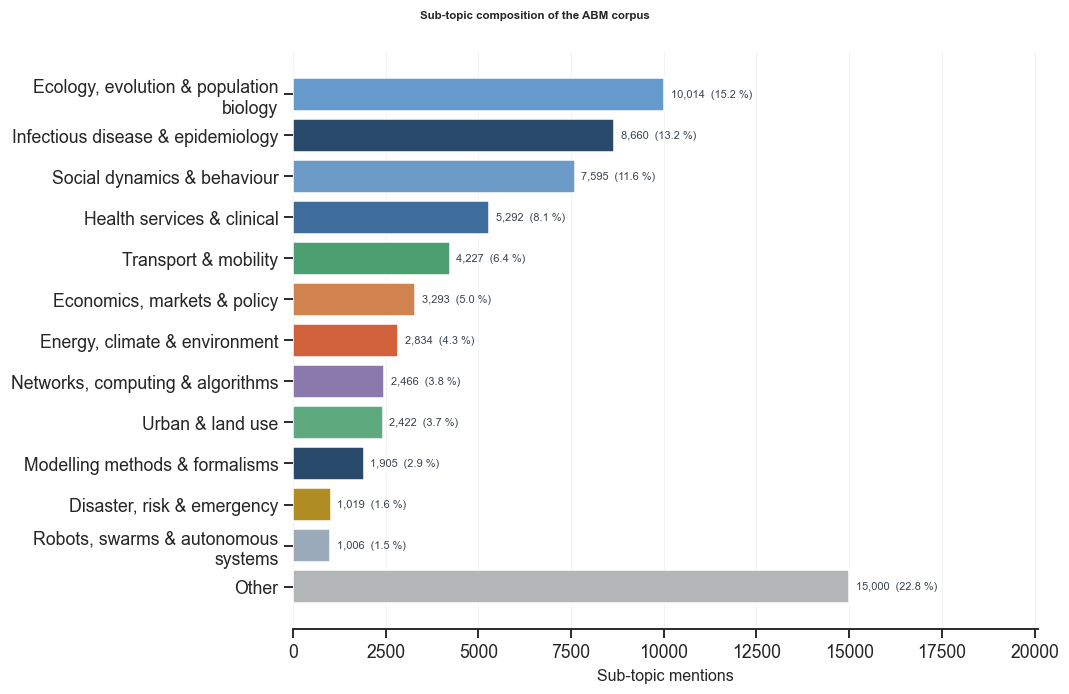

    -> 29_subtopic_composition_a
  [fig 21] 29_subtopic_composition -> 1 panels saved to figures/


WindowsPath('D:/Literature-Research-Agent/figures/_combined/29_subtopic_composition.png')

In [32]:
# Sub-topic taxonomy. Written for SHORT labels, unlike TOPIC_RULES which is matched against
# whole records: applied to bare sub-topic strings the topic rules leave ~48 % of mentions in
# the catch-all, this leaves ~22 %. Order matters, first match wins.
SUBTOPIC_RULES = [
    ("Infectious disease & epidemiology",
     ["epidemi", "infect", "disease", "outbreak", "vaccin", "covid", "pandemic", "transmission",
      "malaria", "hiv", "tuberculosis", "cholera", "measles", "influenza", "pathogen",
      "vector control", "quarantine", "contact tracing", "immunis", "immuniz", "sir model",
      "compartmental", "dengue", "ebola", "zika", "sexually transmitted", "intervention strateg",
      "non pharmaceutical", "mass drug administration", "antibiotic resistance",
      "immune response", "immune system", "wound healing", "antimicrobial"]),
    ("Health services & clinical",
     ["health", "hospital", "patient", "clinical", "cancer", "screening", "cost effective",
      "cost-effective", "treatment", "mental", "therapy", "oncolog", "tumor", "tumour",
      "diagnos", "surg", "nursing", "medication", "care ", "tissue engineering",
      "personalized medicine", "personalised medicine", "diabetes", "obesity", "food safety",
      "vulnerable population", "palliative", "pharmac"]),
    ("Ecology, evolution & population biology",
     ["ecolog", "ecosystem", "species", "population dynamic", "population genetic", "wildlife",
      "conservation", "habitat", "biodiversity", "forest", "fisher", "marine", "microbial",
      "evolution", "predator", "prey", "forag", "dispersal", "plant", "animal", "insect",
      "bird", "coral", "soil", "vegetation", "genetic", "speciation", "pest management",
      "host parasite", "biofilm", "ecotox", "landscape fragment", "population viability",
      "resource competition", "biological system", "cellular biolog", "synthetic biolog",
      "artificial life", "cellular interaction", "cellular dynamic", "population model"]),
    ("Social dynamics & behaviour",
     ["opinion", "social", "behavio", "crowd", "voting", "trust", "cooperat", "education",
      "crime", "cultural", "norm", "segregation", "inequal", "migration", "demograph",
      "household", "community", "friendship", "social influence", "social network",
      "group dynamic", "collective decision", "group decision", "conflict resolution",
      "innovation diffusion", "wealth distribution", "organizational learning",
      "human computer interaction", "wellbeing", "well being"]),
    ("Transport & mobility",
     ["transport", "traffic", "mobility", "commut", "travel", "pedestrian", "vehicle",
      "logistics", "supply chain", "transit", "routing", "parking", "ridesharing",
      "ev charging", "bicycle", "freight", "road network"]),
    ("Urban & land use",
     ["urban", "land use", "land-use", "housing", "city", "cities", "regional", "planning",
      "smart city", "infrastructure", "residential", "zoning", "sprawl", "neighbourhood",
      "neighborhood"]),
    ("Energy, climate & environment",
     ["energy", "emission", "carbon", "electricity", "climate", "renewable", "grid",
      "sustainab", "resource management", "water", "pollution", "environmental", "temperature",
      "drought", "flood", "weather", "solar", "wind power", "waste management",
      "industrial symbiosis"]),
    ("Economics, markets & policy",
     ["market", "economic", "financial", "firm", "pricing", "trade", "bank", "invest", "labour",
      "labor", "tax", "subsid", "policy", "governance", "regulation", "incentive", "auction",
      "insurance", "welfare", "cost benefit", "resource allocation", "risk assessment",
      "public policy"]),
    ("Disaster, risk & emergency",
     ["disaster", "emergency", "resilience", "crisis", "evacuat", "risk management", "hazard",
      "earthquake", "wildfire", "fire spread"]),
    ("Networks, computing & algorithms",
     ["network", "communication", "internet", "wireless", "cyber", "distributed", "computing",
      "algorithm", "machine learning", "neural", "graph", "optimis", "optimiz",
      "genetic algorithm", "reinforcement learning", "blockchain", "peer to peer",
      "spatial analysis", "uncertainty analysis"]),
    ("Robots, swarms & autonomous systems",
     ["swarm", "robot", "flock", "uav", "drone", "unmanned", "autonomous", "formation",
      "multi robot", "collective motion", "industrial automation"]),
    ("Modelling methods & formalisms",
     ["agent based model", "agent-based model", "microsimulation", "micro simulation",
      "simulation", "cellular automat", "markov", "discrete event", "system dynamic",
      "game theor", "monte carlo", "bayesian", "calibration", "model validation",
      "individual based model", "individual-based model", "spatial model",
      "computational model", "mathematical model", "network model", "hybrid model",
      "activity based model", "complex systems", "complex adaptive", "self organization",
      "self organisation", "system modeling", "system modelling"]),
]
SUBTOPIC_COMPILED = [(n, re.compile("|".join(re.escape(p) for p in pats), re.I))
                     for n, pats in SUBTOPIC_RULES]
SUBTOPIC_NAMES = [n for n, _ in SUBTOPIC_RULES] + ["Other"]
SUBTOPIC_COLORS = {n: BUCKET_COLORS[i % len(BUCKET_COLORS)]
                   for i, (n, _) in enumerate(SUBTOPIC_RULES)}
SUBTOPIC_COLORS["Other"] = "#B3B6B7"


def subtopic_bucket(label):
    """Bucket one canonical sub-topic label; 'Other' is the long tail."""
    for name, rx in SUBTOPIC_COMPILED:
        if rx.search(str(label)):
            return name
    return "Other"


def subtopic_mentions(frame):
    """Counter of bucket -> mentions, over a frame's canonical sub-topics."""
    c = Counter()
    for lst in frame["llama_secondary_topics"]:
        for t in canon_list(lst, "llama_secondary_topics"):
            c[subtopic_bucket(t)] += 1
    return c


# ------------------------------------------------------------------ 6.11 sub-topic composition
_sub_all = subtopic_mentions(abm)
_sub_tot = sum(_sub_all.values())
_sub = pd.Series(_sub_all).reindex(SUBTOPIC_NAMES).fillna(0).astype(int).sort_values(ascending=False)
print(f"sub-topic mentions: {_sub_tot:,} across {len(abm):,} ABM papers "
      f"({_sub_tot / len(abm):.2f} per paper)")
for _k, _v in _sub.items():
    print(f"   {_v:>7,}  {100 * _v / _sub_tot:5.2f} %  {_k}")

# long-tail diagnostics, printed here so any caption quoting them comes from THIS run
_ment = Counter()
for _lst in abm["llama_secondary_topics"]:
    for _t in canon_list(_lst, "llama_secondary_topics"):
        _ment[_t] += 1
print(f"\ndistinct canonical sub-topics: {len(_ment):,}")
for _n in (10, 20, 50, 100):
    _cov = 100 * sum(v for _, v in _ment.most_common(_n)) / _sub_tot
    print(f"   top {_n:>3} by mentions cover {_cov:5.1f} % of all sub-topic mentions")

fig, ax = plt.subplots(figsize=(9.9, 6.4))
# 'Other' is pinned to the BOTTOM: it is a catch-all, not a category, so it should not compete
# for the top of the axis with the named buckets.
_vals = _sub[_sub > 0]
_asc = [t for t in _vals[_vals.index != "Other"].sort_values().index]
_d = _vals[(["Other"] if "Other" in _vals.index else []) + _asc]
bars = ax.barh([wrap(i, 34) for i in _d.index], _d.values,
               color=[SUBTOPIC_COLORS[i] for i in _d.index], edgecolor="white")
for b, v in zip(bars, _d.values):
    ax.text(b.get_width() + _d.max() * 0.012, b.get_y() + b.get_height() / 2,
            f"{v:,}  ({100 * v / _sub_tot:.1f} %)", va="center", fontsize=7.2, color="#3A444E")
ax.set_xlim(0, _d.max() * 1.34)
ax.set_xlabel("Sub-topic mentions")
ax.grid(axis="y", visible=False)
sns.despine(ax=ax, left=True)
fig.suptitle("Sub-topic composition of the ABM corpus",
             fontsize=7.5, fontweight="bold", y=0.985)
fig.tight_layout()
save(fig, "29_subtopic_composition",
     "Every paper contributes 2-3 sub-topics, each bucketed on its own label; a bar is that "
     "bucket's share of sub-topic mentions, not of papers. 'Other' is the long tail of "
     "once-and-twice-mentioned labels and is reported rather than hidden.")


sub-topic timeline: 1997-2025 (28 years, >= 100 papers per year)
mentions per year: {1997: 195, 1999: 221, 2000: 278, 2001: 383, 2002: 443, 2003: 485, 2004: 644, 2005: 843, 2006: 765, 2007: 1089, 2008: 1165, 2009: 1470, 2010: 1681, 2011: 1897, 2012: 2191, 2013: 2480, 2014: 2845, 2015: 2983, 2016: 2924, 2017: 3174, 2018: 3538, 2019: 3739, 2020: 4030, 2021: 5308, 2022: 5461, 2023: 5032, 2024: 5199, 2025: 4668}

share of each bucket, first vs last year (%):
   Other                                       27.2 ->  22.9
   Ecology, evolution & population biology     36.9 ->   9.9
   Social dynamics & behaviour                  6.7 ->  11.9
   Infectious disease & epidemiology            6.7 ->  12.6
   Health services & clinical                   6.7 ->  10.1
   Transport & mobility                         2.6 ->   7.7
   Economics, markets & policy                  2.1 ->   5.8
   Networks, computing & algorithms             5.1 ->   3.1
   Energy, climate & environment                1.5 -

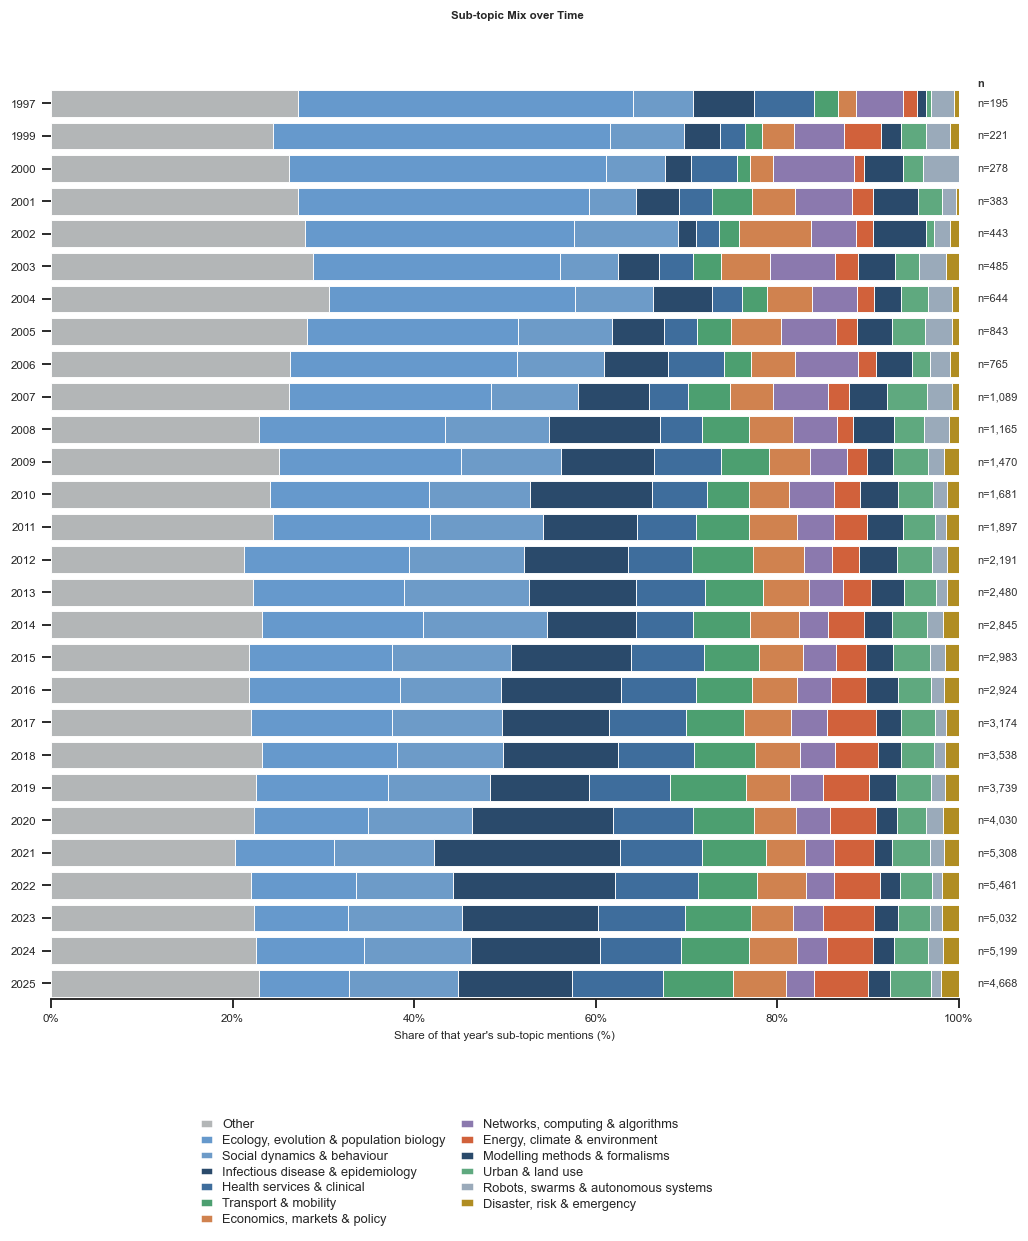

    -> fig30_subtopic_evolution.png / .pdf


In [33]:
# ------------------------------------------------------------------ 6.12 sub-topic mix over time
# Stacked companion to the panel above. Shares are within each year's sub-topic mentions, so
# the stack always reaches 100 %.
_y = abm["year_num"].dropna()
_yearly_n = _y[_y <= LAST_YEAR].astype(int).value_counts().sort_index()
SUBT_MIN_YEAR_N = 100
SUBT_YEARS = [int(v) for v, n in _yearly_n.items() if n >= SUBT_MIN_YEAR_N]

_rows = []
for _yy in SUBT_YEARS:
    _c = subtopic_mentions(abm[abm["year_num"] == _yy])
    _n = sum(_c.values()) or 1
    _rows.append({"year": _yy, "_n": _n, **{k: 100 * _c.get(k, 0) / _n for k in SUBTOPIC_NAMES}})
_sub_ct = pd.DataFrame(_rows).set_index("year")
_sub_share = _sub_ct[SUBTOPIC_NAMES]
SUBT_ORDER = [t for t in _sub_share.sum().sort_values(ascending=False).index]
print(f"sub-topic timeline: {SUBT_YEARS[0]}-{SUBT_YEARS[-1]} ({len(SUBT_YEARS)} years, "
      f">= {SUBT_MIN_YEAR_N} papers per year)")
print("mentions per year:", {int(y): int(_sub_ct.loc[y, "_n"]) for y in SUBT_YEARS})
print("\nshare of each bucket, first vs last year (%):")
for _t in SUBT_ORDER:
    print(f"   {_t:<42} {_sub_share.loc[SUBT_YEARS[0], _t]:5.1f} -> "
          f"{_sub_share.loc[SUBT_YEARS[-1], _t]:5.1f}")

_oth = _sub_share["Other"]
print(f"\n'Other' share across years: min {_oth.min():.1f} % ({int(_oth.idxmin())}), "
      f"max {_oth.max():.1f} % ({int(_oth.idxmax())})")

_pos = np.arange(len(SUBT_YEARS))
fig = plt.figure(figsize=(11.0, 0.30 * len(SUBT_YEARS) + 3.2))
ax = fig.add_axes([0.115, 0.20, 0.75, 0.715])
left = np.zeros(len(SUBT_YEARS))
for _t in SUBT_ORDER:
    vals = _sub_share[_t].to_numpy(dtype=float)
    ax.barh(_pos, vals, left=left, height=0.82, color=SUBTOPIC_COLORS[_t],
            edgecolor="white", linewidth=0.6, label=_t)
    left += vals
ax.set_xlim(0, 100)
ax.set_ylim(len(_pos) - 0.5, -0.5)
ax.set_yticks(_pos)
ax.set_yticklabels([str(y) for y in SUBT_YEARS], fontsize=7.5)
_ticks = list(range(0, 101, 20))
ax.set_xticks(_ticks)
ax.set_xticklabels([f"{t}%" for t in _ticks], fontsize=7.5)
ax.set_xlabel("Share of that year's sub-topic mentions (%)", fontsize=7.5)
ax.grid(False)
sns.despine(ax=ax, left=True)
for _i, _yy in zip(_pos, SUBT_YEARS):
    ax.text(102, _i, f"n={int(_sub_ct.loc[_yy, '_n']):,}", ha="left", va="center",
            fontsize=7.2, color="#333333", clip_on=False)
ax.text(102, -0.6, "n", ha="left", va="center", fontsize=7.2, color="#333333",
        fontweight="bold", clip_on=False)
_handles = [Patch(facecolor=SUBTOPIC_COLORS[t], edgecolor="white") for t in SUBT_ORDER]
_legend = fig.legend(_handles, [t.replace("_", " ") for t in SUBT_ORDER], loc="lower center",
                     ncol=2, fontsize=7.2, frameon=False, bbox_to_anchor=(0.45, 0.015),
                     handlelength=1.15, columnspacing=1.4, labelspacing=0.32)
for _txt in _legend.get_texts():
    _txt.set_fontsize(8.4)
fig.suptitle("Sub-topic Mix over Time", y=0.975, fontsize=7.5, fontweight="bold")
for ext in ("png", "pdf"):
    _save_with_retry(fig, FIG_DIR / f"fig30_subtopic_evolution.{ext}", bbox_inches="tight")
plt.show()
plt.close(fig)
print("    -> fig30_subtopic_evolution.png / .pdf")


(1a) vs LONG-RUN TREND  (Poisson log-linear fitted on 2001-2019, extrapolated)
      2020: observed   1,719   expected  2,088.4   excess  -369.4
      2021: observed   2,201   expected  2,339.6   excess  -138.6
      2022: observed   2,314   expected  2,621.1   excess  -307.1
      2023: observed   2,136   expected  2,936.4   excess  -800.4
    slope +0.1136 log-counts/yr = +12.03 %/yr
    window observed 8,370  expected 9,985.5  excess -1,615.5 (-16.2 %)   p = 1
    -> -16.2 % against trend: NO increase, output ran BELOW it

(1b) vs PREVIOUS LEVEL  (2016-2019 mean annual output, exact Poisson test)
    2016-2019 mean 1,461.8/yr  ->  expected 2020-2023 total 5,847.0 at that level
    window observed 8,370   rate ratio 1.432   p = 8e-211   (+43.2 %)
    -> a 43 % step up on the 2016-2019 level, p = 8e-211

(2) TOPIC DECOMPOSITION of the 2020-2023 increase over the 2016-2019 level
    epidemiology_public_health     obs   2,542  base-expected  1,432.0  excess +1,110.0   43.7 %  p=5.96e-15

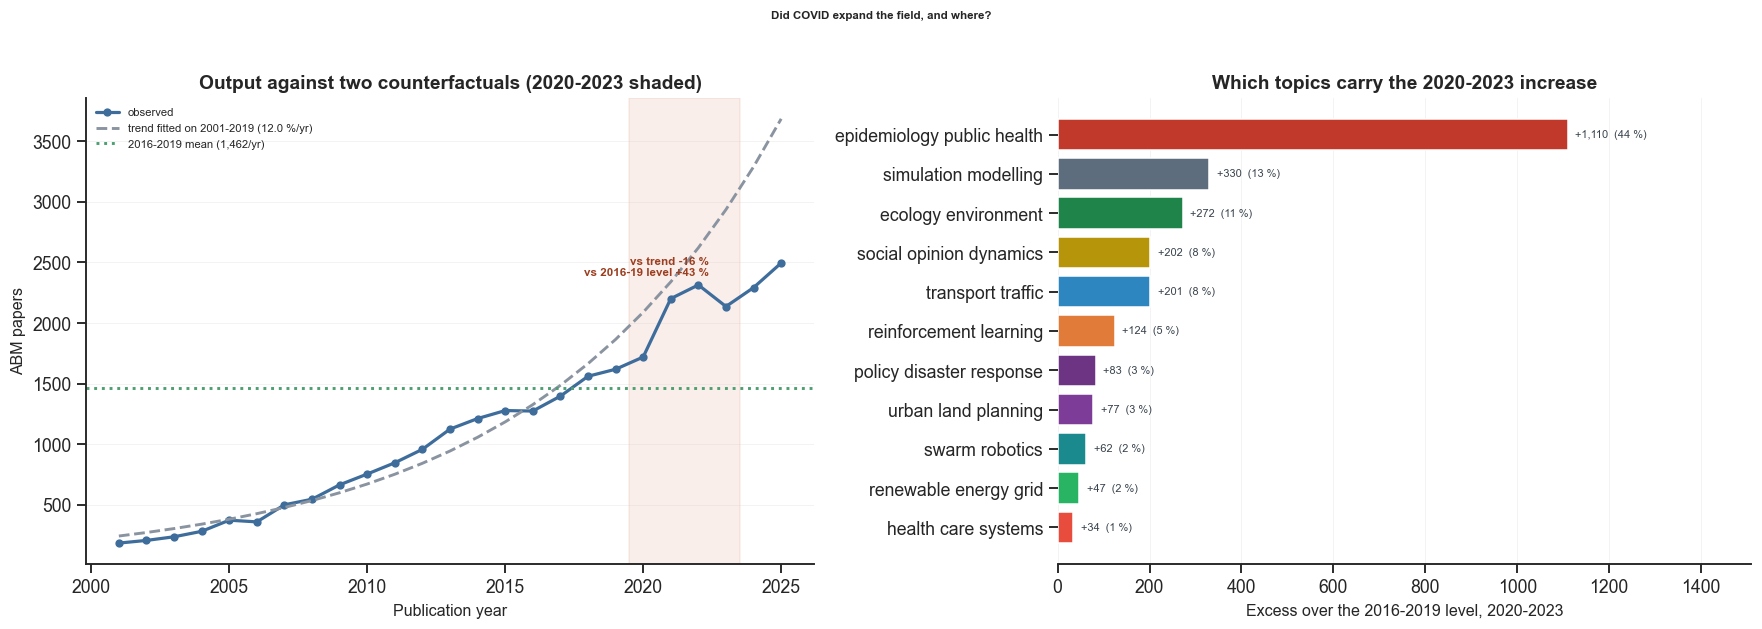

    -> 31_covid_effect_a, 31_covid_effect_b
  [fig 22] 31_covid_effect -> 2 panels saved to figures/


WindowsPath('D:/Literature-Research-Agent/figures/_combined/31_covid_effect.png')

In [34]:
# ---------------------------------------------------------------- 8b. did COVID change the field?
# The question has no answer independent of the counterfactual, so both are reported:
#   (1a) vs the LONG-RUN TREND: a Poisson log-linear trend fitted on 2001-2019, extrapolated.
#   (1b) vs the PREVIOUS LEVEL: the 2016-2019 mean annual output, tested by an exact Poisson
#        rate-ratio against 2020-2023.
# They disagree, and the disagreement is the result: the field grew faster than its own
# 2001-2019 trend before 2020 and slower than that trend afterwards, while still sitting far
# above where it was in 2016-2019. Reporting only one would be a specification choice dressed
# up as a finding.
import statsmodels.api as sm
from scipy import stats as _st

COVID_W = (2020, 2023)
PRE_W = (2016, 2019)
_yr = abm["year_num"].astype("Int64")
_yearly = abm.groupby(_yr).size()
_yearly = _yearly[(_yearly.index >= 2001) & (_yearly.index <= LAST_YEAR)]
_years = _yearly.index.astype(float).to_numpy()
_counts = _yearly.to_numpy().astype(float)
_in = (_years >= COVID_W[0]) & (_years <= COVID_W[1])
_pre_all = _years < COVID_W[0]
_pre_win = (_years >= PRE_W[0]) & (_years <= PRE_W[1])

print("=" * 80)
print(f"(1a) vs LONG-RUN TREND  (Poisson log-linear fitted on "
      f"{int(_years[_pre_all].min())}-{int(_years[_pre_all].max())}, extrapolated)")
_X = sm.add_constant(_years[_pre_all])
_fit = sm.GLM(_counts[_pre_all], _X, family=sm.families.Poisson()).fit()
pred = _fit.predict(sm.add_constant(_years))
for _y in _years[_in]:
    _i = _years == _y
    print(f"      {int(_y)}: observed {_counts[_i][0]:>7,.0f}   expected "
          f"{pred[_i][0]:>8,.1f}   excess {_counts[_i][0] - pred[_i][0]:>+7,.1f}")
_o1, _e1 = _counts[_in].sum(), pred[_in].sum()
_p1 = _st.poisson.sf(_o1 - 1, _e1)
print(f"    slope {_fit.params[1]:+.4f} log-counts/yr = "
      f"{100 * (np.exp(_fit.params[1]) - 1):+.2f} %/yr")
print(f"    window observed {_o1:,.0f}  expected {_e1:,.1f}  excess {_o1 - _e1:+,.1f} "
      f"({100 * (_o1 - _e1) / _e1:+.1f} %)   p = {_p1:.3g}")
print(f"    -> {100 * (_o1 - _e1) / _e1:+.1f} % against trend: NO increase, output ran BELOW it")

print()
print(f"(1b) vs PREVIOUS LEVEL  ({PRE_W[0]}-{PRE_W[1]} mean annual output, exact Poisson test)")
_mb = _counts[_pre_win].mean()
_exp2 = _mb * int(_in.sum())
_p2 = _st.poisson.sf(_o1 - 1, _exp2)
print(f"    {PRE_W[0]}-{PRE_W[1]} mean {_mb:,.1f}/yr  ->  expected {COVID_W[0]}-{COVID_W[1]} "
      f"total {_exp2:,.1f} at that level")
print(f"    window observed {_o1:,.0f}   rate ratio {_o1 / _exp2:.3f}   "
      f"p = {_p2:.3g}   (+{100 * (_o1 / _exp2 - 1):.1f} %)")
print(f"    -> a {100 * (_o1 / _exp2 - 1):.0f} % step up on the 2016-2019 level, p = {_p2:.2g}")

# ---- (2) topic decomposition, under (1b) ----
print()
print("(2) TOPIC DECOMPOSITION of the 2020-2023 increase over the 2016-2019 level")
_rows = []
for _t in TOPIC_NAMES:
    _c = abm[abm["topic"] == _t].groupby(_yr).size().reindex(_yearly.index, fill_value=0) \
        .to_numpy().astype(float)
    _base = _c[_pre_win].mean()
    if _base * int(_in.sum()) < 20:
        continue
    _exp = _base * int(_in.sum())
    _rows.append({"topic": _t, "obs": _c[_in].sum(), "exp": _exp,
                  "excess": _c[_in].sum() - _exp,
                  "p": _st.poisson.sf(_c[_in].sum() - 1, _exp)})
_dd = pd.DataFrame(_rows).sort_values("excess", ascending=False)
_dd["share_of_excess"] = 100 * _dd["excess"] / _dd["excess"].clip(lower=0).sum()
for _r in _dd.itertuples():
    _flag = "  *" if _r.p < 0.05 else ""
    print(f"    {_r.topic:<30} obs {_r.obs:>7,.0f}  base-expected {_r.exp:>8,.1f}  "
          f"excess {_r.excess:>+7,.1f}  {_r.share_of_excess:5.1f} %  p={_r.p:.3g}{_flag}")
_top = _dd[_dd["excess"] > 0]
print(f"    total increase {_o1 - _exp2:+,.0f}; positive topic excess sums to "
      f"{_top['excess'].sum():+,.0f}")
print("    ('*' marks p < 0.05; the per-topic tests are not corrected for multiple comparisons)")

# ---- figure ----
fig, axes = plt.subplots(1, 2, figsize=(16.2, 5.6), gridspec_kw={"width_ratios": [1.05, 1]})

ax = axes[0]
ax.plot(_years, _counts, "o-", color=C["abm"], lw=2.1, ms=4.4, label="observed")
ax.plot(_years, pred, "--", color=C["grey"], lw=1.9,
        label=f"trend fitted on 2001-2019 ({100 * (np.exp(_fit.params[1]) - 1):.1f} %/yr)")
ax.axhline(_mb, color=C["accent"], ls=":", lw=1.9,
           label=f"{PRE_W[0]}-{PRE_W[1]} mean ({_mb:,.0f}/yr)")
ax.axvspan(COVID_W[0] - 0.5, COVID_W[1] + 0.5, color=C["llm"], alpha=0.10, zorder=0)
ax.annotate(f"vs trend {100 * (_o1 - _e1) / _e1:+.0f} %\nvs 2016-19 level "
            f"{100 * (_o1 / _exp2 - 1):+.0f} %",
            xy=(COVID_W[1] - 0.3, _counts[_in][-1]), xytext=(-6, 20),
            textcoords="offset points", ha="right", fontsize=7.6,
            color=C["llm_dark"], fontweight="bold")
ax.set_xlabel("Publication year"); ax.set_ylabel("ABM papers")
ax.set_title(f"Output against two counterfactuals ({COVID_W[0]}-{COVID_W[1]} shaded)")
ax.legend(fontsize=7.4, loc="upper left"); ax.grid(axis="x", visible=False)

ax = axes[1]
_bars = _top.sort_values("excess")
bars = ax.barh([wrap(i.replace("_", " "), 26) for i in _bars["topic"]], _bars["excess"],
               color=[TOPIC_COLORS[i] for i in _bars["topic"]], edgecolor="white")
for b, _r in zip(bars, _bars.itertuples()):
    ax.text(b.get_width() + _bars["excess"].max() * 0.015, b.get_y() + b.get_height() / 2,
            f"{_r.excess:+,.0f}  ({_r.share_of_excess:.0f} %)", va="center",
            fontsize=7.2, color="#3A444E")
ax.set_xlim(0, _bars["excess"].max() * 1.36)
ax.set_xlabel(f"Excess over the {PRE_W[0]}-{PRE_W[1]} level, {COVID_W[0]}-{COVID_W[1]}")
ax.set_title("Which topics carry the 2020-2023 increase")
ax.grid(axis="y", visible=False); sns.despine(ax=ax, left=True)

fig.suptitle("Did COVID expand the field, and where?", fontsize=7.5, fontweight="bold", y=1.02)
fig.tight_layout()
save(fig, "31_covid_effect",
     "Panel A shows output against two counterfactuals: the 2001-2019 Poisson trend and the "
     "2016-2019 mean level. They disagree, and the disagreement is the finding. Panel B "
     "attributes the 2020-2023 increase over the 2016-2019 level to topics.")


windows: (2018, 2022) n=9,412   (2023, 2025) n=6,923


sub-topics above the 0.5 % floor in either window: 40


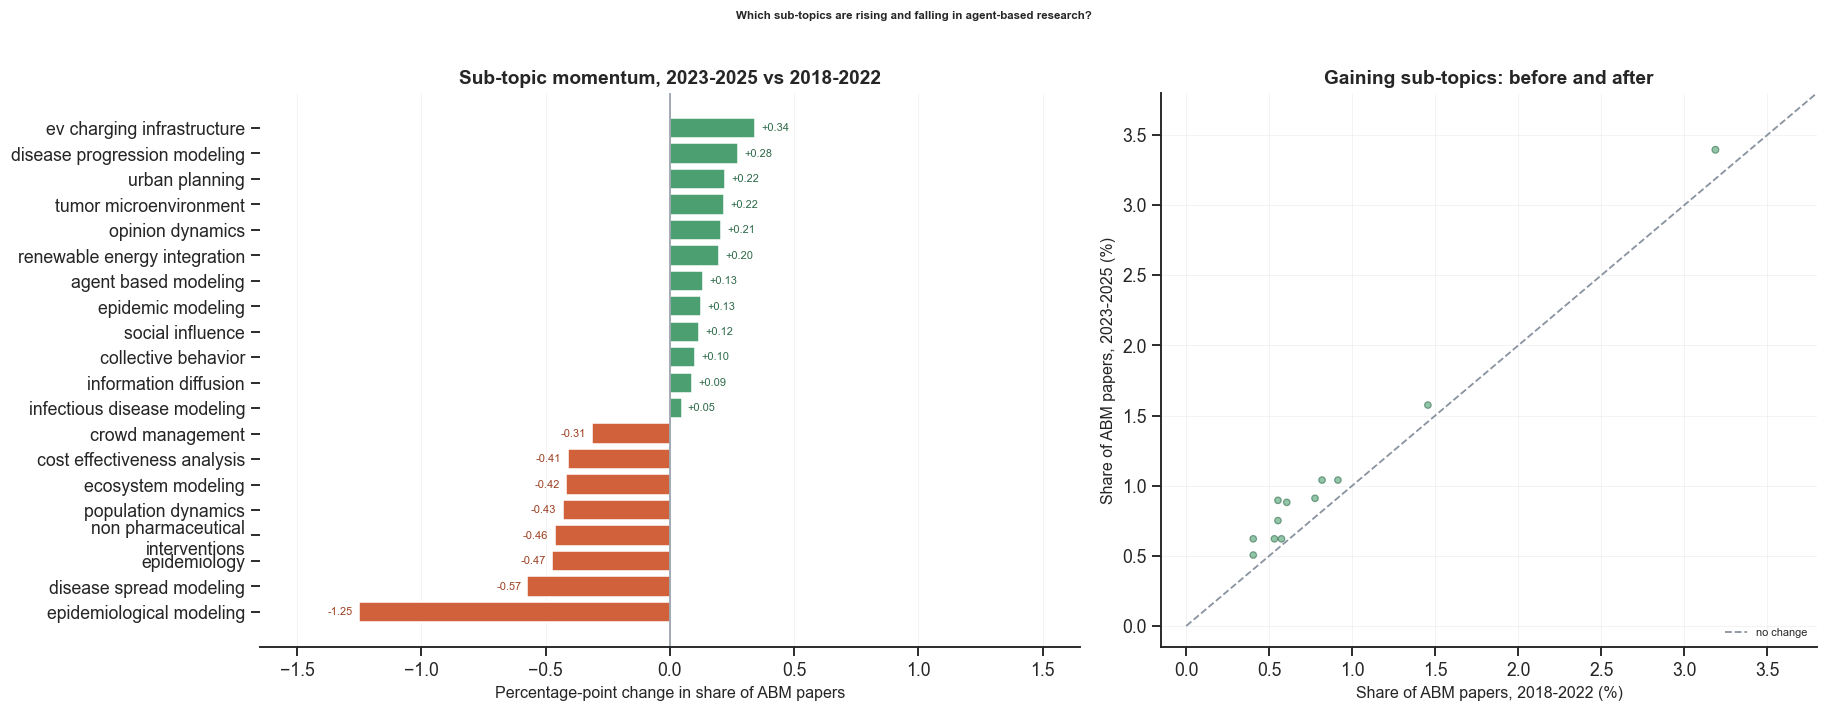

    -> fig22_subtopic_momentum_a, fig22_subtopic_momentum_b
  [fig 23] 22_subtopic_momentum -> 2 panels saved to figures/


WindowsPath('D:/Literature-Research-Agent/figures/_combined/22_subtopic_momentum.png')

In [35]:
# ------------------------------------------------------------------ 6.9 emerging vs established sub-topics
# Contiguous, and identical to the split used by fig18 and fig21 (see cell 42).
EARLY_W, RECENT_W = (2018, 2022), (2023, LAST_YEAR)
early = abm[abm["year_num"].between(*EARLY_W)]
recent = abm[abm["year_num"].between(*RECENT_W)]
print(f"windows: {EARLY_W} n={len(early):,}   {RECENT_W} n={len(recent):,}")

early_st = Counter()
for lst in early["llama_secondary_topics"]:
    early_st.update({c for c in (canon_topic(k, "llama_secondary_topics")
                                 for k in to_list(lst)) if c})
recent_st = Counter()
for lst in recent["llama_secondary_topics"]:
    recent_st.update({c for c in (canon_topic(k, "llama_secondary_topics")
                                  for k in to_list(lst)) if c})

st_era = pd.DataFrame({
    "early": pd.Series(early_st) / len(early) * 100,
    "recent": pd.Series(recent_st) / len(recent) * 100,
}).fillna(0.0)
st_era = st_era[(st_era["early"] >= 0.5) | (st_era["recent"] >= 0.5)]
st_era["delta"] = st_era["recent"] - st_era["early"]
st_era["papers_recent"] = [recent_st.get(i, 0) for i in st_era.index]
print(f"sub-topics above the 0.5 % floor in either window: {len(st_era):,}")

gaining = st_era.sort_values("delta", ascending=False).head(12)
declining = st_era.sort_values("delta").head(8)

fig, axes = plt.subplots(1, 2, figsize=(16.8, 6.4), gridspec_kw={"width_ratios": [1.25, 1]})

ax = axes[0]
combined = pd.concat([gaining, declining]).sort_values("delta")
colors = [C["accent"] if v > 0 else C["llm"] for v in combined["delta"]]
bars = ax.barh([wrap(i, 30) for i in combined.index], combined["delta"],
               color=colors, edgecolor="white")
span = float(combined["delta"].abs().max())
for b, v in zip(bars, combined["delta"]):
    ax.text(b.get_width() + (span * 0.02 if v >= 0 else -span * 0.02),
            b.get_y() + b.get_height() / 2, f"{v:+.2f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=7.2,
            color="#2F6B4A" if v >= 0 else C["llm_dark"])
ax.axvline(0, color=C["grey"], lw=1)
ax.set_xlim(-span * 1.32, span * 1.32)
ax.set_xlabel("Percentage-point change in share of ABM papers")
ax.set_title(f"Sub-topic momentum, "
             f"{RECENT_W[0]}-{RECENT_W[1]} vs {EARLY_W[0]}-{EARLY_W[1]}")
ax.grid(axis="y", visible=False)
sns.despine(ax=ax, left=True)

ax = axes[1]
d = gaining.sort_values("papers_recent")
ax.scatter(d["early"], d["recent"], s=np.clip(d["papers_recent"] / 12, 18, 420),
           color=C["accent"], alpha=0.6, edgecolor="#2F6B4A", linewidth=0.8)
lim = max(d["early"].max(), d["recent"].max()) * 1.12
ax.plot([0, lim], [0, lim], ls="--", lw=1.2, color=C["grey"], label="no change")
ax.set_xlim(-lim * 0.04, lim)
ax.set_ylim(-lim * 0.04, lim)
ax.set_xlabel(f"Share of ABM papers, {EARLY_W[0]}-{EARLY_W[1]} (%)")
ax.set_ylabel(f"Share of ABM papers, {RECENT_W[0]}-{RECENT_W[1]} (%)")
ax.set_title("Gaining sub-topics: before and after")
ax.legend(fontsize=7.2, loc="lower right")

fig.suptitle("Which sub-topics are rising and falling in agent-based research?",
             fontsize=7.5, fontweight="bold", y=1.01)
fig.tight_layout()
save(fig, "22_subtopic_momentum",
     "Windows are multi-year because single-year sub-topic shares are noisy.")

methodology family prevalence, 2020-2025 mean (% of ABM papers):
Agent-based / multi-agent simulation           57.500
Individual-based / microsimulation             19.800
Generic simulation / modelling (unspecified)    0.500
Network / graph models                          0.400
Game-theoretic / economic                       0.200
Statistical / ML modelling                      0.200
Epidemiological / compartmental                 0.100
Reinforcement learning                          0.100
Control & coordination                          0.000
Swarm / collective                              0.000


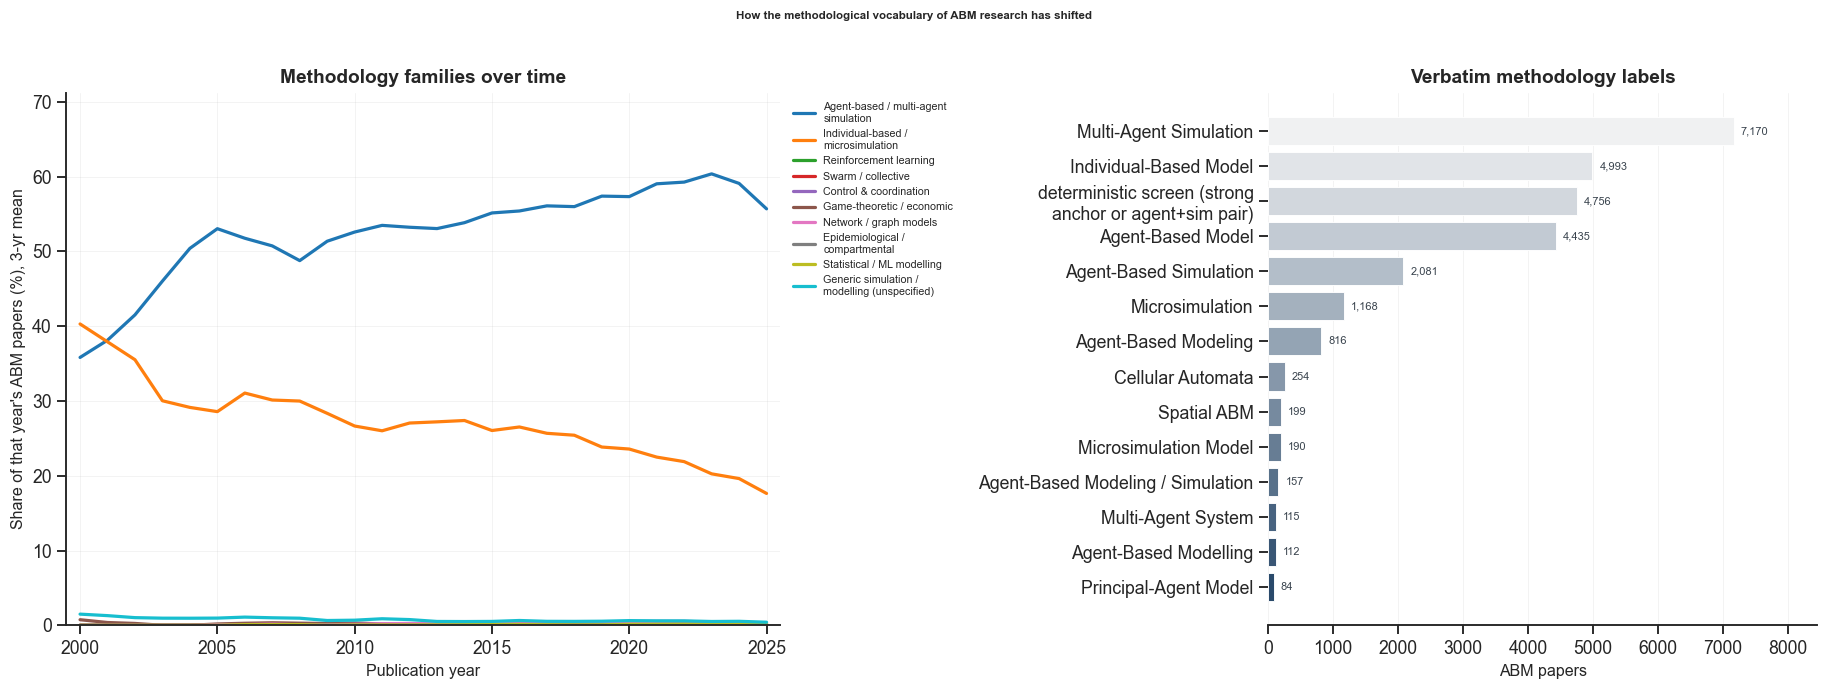

    -> fig23_methodology_families_a, fig23_methodology_families_b
  [fig 24] 23_methodology_over_time -> 2 panels saved to figures/


WindowsPath('D:/Literature-Research-Agent/figures/_combined/23_methodology_over_time.png')

In [36]:
# ------------------------------------------------------------------ 6.10 methodology vocabulary over time
METHOD_RULES = {
    "Agent-based / multi-agent simulation": [r"agent[- ]based", r"multi[- ]?agent", r"agent based"],
    "Individual-based / microsimulation": [r"individual[- ]based", r"microsimulation",
                                           r"micro[- ]simulation", r"microsimulat"],
    "Reinforcement learning": [r"reinforcement learning", r"\brl\b", r"q[- ]learning",
                               r"actor[- ]critic"],
    "Swarm / collective": [r"swarm", r"collective", r"flocking", r"self[- ]organi"],
    "Control & coordination": [r"control", r"coordination", r"consensus", r"formation"],
    "Game-theoretic / economic": [r"game[- ]theor", r"game theory", r"equilibrium", r"auction",
                                  r"market"],
    "Network / graph models": [r"network", r"graph", r"topolog", r"percolation"],
    "Epidemiological / compartmental": [r"epidemi", r"\bsir\b", r"\bseir\b", r"compartmental",
                                        r"infectious"],
    "Statistical / ML modelling": [r"machine learning", r"deep learning", r"regression",
                                   r"neural", r"bayesian", r"statistical"],
    # catch-all: 25.5 % of records carry a bare "Simulation" / "Computational modeling" label with
    # no family signal, and dropping them would silently understate the totals
    "Generic simulation / modelling (unspecified)": [
        r"simulat", r"computational model", r"mathematical model", r"computational",
        r"modeling", r"modelling"],
}
METHOD_COMPILED = [(k, re.compile("|".join(f"(?:{p})" for p in v), re.I))
                   for k, v in METHOD_RULES.items()]


def method_families(raw):
    """Multi-label: a methodology phrase can legitimately match several families.

    The generic catch-all is deliberately suppressed whenever a more specific family already
    matched, otherwise almost every label ("Agent-based modeling and simulation") would also
    count as generic simulation and the two lines would be uninterpretable.
    """
    if not isinstance(raw, str) or not raw.strip() or raw.strip().lower() in SENTINELS:
        return []
    hits = [name for name, rx in METHOD_COMPILED if rx.search(raw)]
    specific = [h for h in hits if not h.startswith("Generic simulation")]
    return specific if specific else hits


mflags = pd.DataFrame(
    {name: [name in method_families(v) for v in abm["llama_abm_methodology"]]
     for name, _ in METHOD_COMPILED},
    index=abm.index)
mflags["year_num"] = abm["year_num"]
m_yearly = mflags[mflags["year_num"].between(2000, 2025)].groupby("year_num").sum()
m_denom = abm[abm["year_num"].between(2000, 2025)].groupby("year_num").size()
m_pct = m_yearly.div(m_denom, axis=0) * 100
m_smooth = m_pct.rolling(3, min_periods=1).mean()

print("methodology family prevalence, 2020-2025 mean (% of ABM papers):")
print(m_pct.loc[2020:2025].mean().sort_values(ascending=False).round(1).to_string())

fig, axes = plt.subplots(1, 2, figsize=(16.8, 6.2), gridspec_kw={"width_ratios": [1.3, 1]})

ax = axes[0]
palette = sns.color_palette("tab10", n_colors=len(m_smooth.columns))
for col, color in zip(m_smooth.columns, palette):
    ax.plot(m_smooth.index, m_smooth[col], lw=2.1, color=color, label=wrap(col, 26))
ax.set_xlabel("Publication year")
ax.set_ylabel("Share of that year's ABM papers (%), 3-yr mean")
ax.set_title("Methodology families over time")
ax.legend(fontsize=7, ncol=1, loc="upper left", bbox_to_anchor=(1.005, 1.0))
ax.set_xlim(1999.5, 2025.5)
safe_ylim(ax, 0, float(m_smooth.to_numpy().max()) * 1.18)

ax = axes[1]
raw = abm.loc[abm["llama_abm_methodology"].astype("string").str.strip().str.lower() != "none",
              "llama_abm_methodology"].value_counts().head(14)
hbar(ax, raw.iloc[::-1], colors=sns.light_palette(C["abm_dark"], n_colors=len(raw))[::-1])
ax.set_xlabel("ABM papers")
ax.set_title("Verbatim methodology labels")
ax.grid(axis="x", alpha=0.25)

fig.suptitle("How the methodological vocabulary of ABM research has shifted",
             fontsize=7.5, fontweight="bold", y=1.01)
fig.tight_layout()
save(fig, "23_methodology_over_time",
     "Families are multi-label, but the generic catch-all is only used when no specific family "
     "matched, so each paper contributes exactly one generic or several specific families; shares "
     "therefore do not sum to 100 %. 25.5 % of records carry a bare 'Simulation' / 'Computational "
     "modeling' label with no distinguishing signal, and that residue is the catch-all line. Panel B "
     "shows why families are needed at all: the raw vocabulary is dominated by near-synonyms and "
     "casing variants.")

**Section 6c findings.**

* The concept cloud and the frequency bars agree on the **structural core of the field**:
  agent-based modelling and multi-agent systems appear in roughly a quarter to a third of all ABM
  papers, with reinforcement learning, swarm intelligence and distributed control forming the
  second rank. LLM vocabulary has entered this core in only the last three years.
* Sub-topics differ enormously in **LLM intensity**: the ones closest to language, learning and
  multi-agent coordination show the highest lift over the corpus baseline, while classical control
  and formation-control themes sit far below it. This is a sharper version of the domain-level
  finding in Section 7.
* Rising sub-topics are overwhelmingly **LLM-adjacent or learning-related**, and the declining ones
  are the classical control-theoretic themes — the field is not growing uniformly, it is being
  re-weighted.
* `llama_abm_methodology` needed the same treatment as every other stage-3 field: 40 distinct
  free-text labels, dominated by near-synonyms ("Agent-based modeling" / "Agent-based modelling" /
  "Agent-based modeling and simulation"), which is why Figure 23 panel A works with regex families
  rather than raw labels.

## 8. Summary dashboard

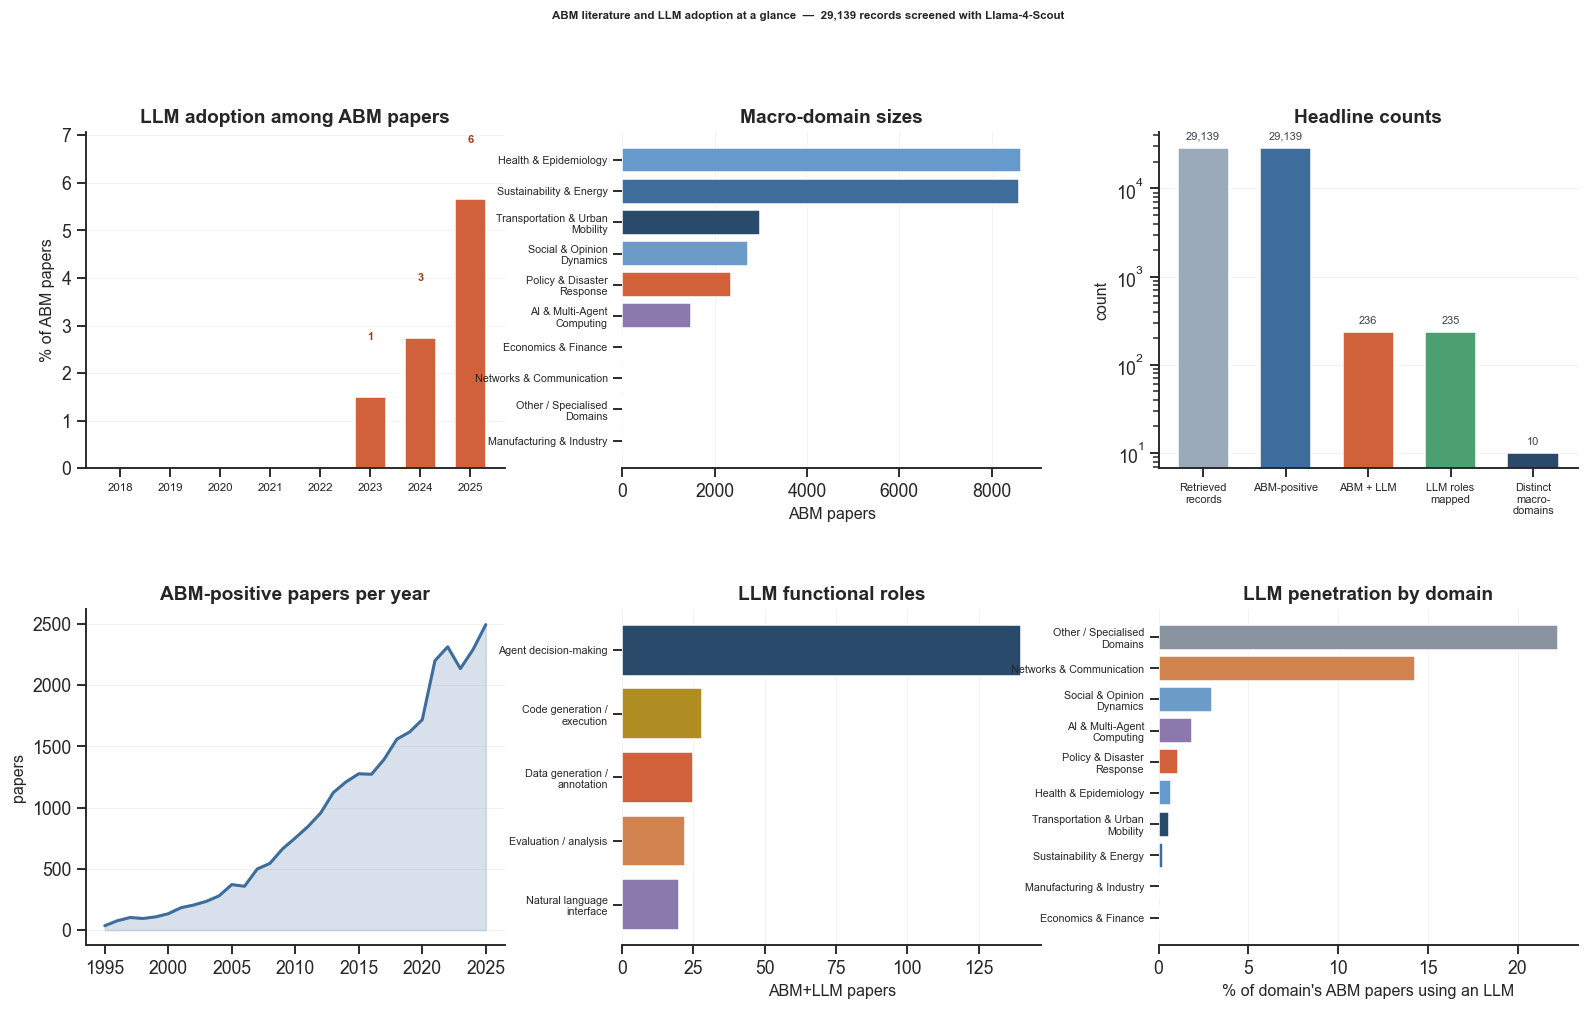

    -> fig19_dashboard_a, fig19_dashboard_b, fig19_dashboard_c, fig19_dashboard_d, fig19_dashboard_e, fig19_dashboard_f
  [fig 25] 19_summary_dashboard -> 6 panels saved to figures/


WindowsPath('D:/Literature-Research-Agent/figures/_combined/19_summary_dashboard.png')

In [37]:
fig = plt.figure(figsize=(17.5, 9.6))
gs = fig.add_gridspec(2, 3, hspace=0.42, wspace=0.28)

kt = abm.copy()
kt["llm"] = (kt["llama_llm_has_llm"] == 1)

# ---- A: adoption curve
ax = fig.add_subplot(gs[0, 0])
g = kt[kt["year_num"].between(2018, LAST_YEAR)].groupby("year_num")["llm"].agg(["sum", "count"])
g["pct"] = g["sum"] / g["count"] * 100
ax.bar(g.index, g["pct"], color=[C["llm"] if y <= 2025 else "#E8A98D" for y in g.index],
       edgecolor="white", width=0.62)
ax.set_title("LLM adoption among ABM papers")
ax.set_ylabel("% of ABM papers")
safe_ylim(ax, 0, g["pct"].max() * 1.25)
ax.grid(axis="x", visible=False)
for x, v in g["pct"].items():
    if v > 0.5:
        ax.text(x, v + 1.2, f"{v:.0f}", ha="center", fontsize=7.2, color=C["llm_dark"], fontweight="bold")
ax.set_xticks(list(g.index)); ax.tick_params(axis="x", labelsize=7.5)

# ---- B: growth of ABM
ax = fig.add_subplot(gs[1, 0])
yy = kt.groupby("year_num").size()
yy = yy[yy.index >= 1995]
ax.fill_between(yy.index, yy.values, color=C["abm"], alpha=0.2)
ax.plot(yy.index, yy.values, color=C["abm"], lw=2)
ax.set_title("ABM-positive papers per year")
ax.set_ylabel("papers")
ax.grid(axis="x", visible=False)


# ---- C: headline counts as a bar chart (a text-only panel does not survive panel splitting)
ax = fig.add_subplot(gs[0, 2])
rows = [
    ("Retrieved records", f"{len(df):,}", C["non_abm"]),
    ("ABM-positive", f"{len(abm):,}", C["abm"]),
    ("ABM + LLM", f"{int(kt['llm'].sum()):,}", C["llm"]),
    ("LLM roles mapped", f"{len(llm_pos) - int(hero.get('Unspecified (sentinel)', 0)):,}", C["accent"]),
    ("Distinct macro-domains", f"{len(_dom) - 1:,}", C["abm_dark"]),
]
ax.set_title("Headline counts")
ax.set_yscale("log")
_labels = [k for k, _, _ in rows]
_counts = [int(str(v).replace(",", "")) for _, v, _ in rows]
_bars = ax.bar(range(len(rows)), _counts, color=[c for _, _, c in rows], edgecolor="white",
               width=0.62)
bar_labels(ax, _bars, _counts, dy=4, fontsize=7.2)
ax.set_xticks(range(len(rows)))
ax.set_xticklabels([wrap(k, 12) for k in _labels], fontsize=7.2)
ax.set_ylabel("count")
ax.grid(axis="x", visible=False)

# ---- D: macro domains
ax = fig.add_subplot(gs[0, 1])
d = (_dom.drop(index=["Unclassified"], errors="ignore").sort_values())
ax.barh([wrap(i, 24) for i in d.index], d.values,
        color=[DOMAIN_COLORS[i] for i in d.index], edgecolor="white")
ax.set_title("Macro-domain sizes")
ax.set_xlabel("ABM papers")
ax.grid(axis="y", visible=False)
sns.despine(ax=ax, left=True)
ax.tick_params(axis="y", labelsize=7)

# ---- E: roles
ax = fig.add_subplot(gs[1, 1])
r = hero.drop(index=["Unspecified (sentinel)"], errors="ignore")
ax.barh([wrap(i, 24) for i in r.index[::-1]], r.values[::-1],
        color=[ROLE_COLORS_MAP[i] for i in r.index[::-1]], edgecolor="white")
ax.set_title("LLM functional roles")
ax.set_xlabel("ABM+LLM papers")
ax.grid(axis="y", visible=False)
sns.despine(ax=ax, left=True)
ax.tick_params(axis="y", labelsize=7)

# ---- F: domain penetration
ax = fig.add_subplot(gs[1, 2])
d = dom_stats.sort_values("share")
ax.barh([wrap(i, 24) for i in d.index], d["share"],
        color=[DOMAIN_COLORS[i] for i in d.index], edgecolor="white")
ax.set_title("LLM penetration by domain")
ax.set_xlabel("% of domain's ABM papers using an LLM")
ax.grid(axis="y", visible=False)
sns.despine(ax=ax, left=True)
ax.tick_params(axis="y", labelsize=7)

fig.suptitle(f"ABM literature and LLM adoption at a glance  \u2014  {SCREENED_N:,} records screened with Llama-4-Scout",
             fontsize=7.5, fontweight="bold", y=0.995)
save(fig, "19_summary_dashboard",
     "All series end at 2025, the last complete calendar year.")

## 9. Authorship structure

The corpus carries `authors_std`, a JSON string with every author's name, position, ORCID and a list
of institutions (name, country, ROR, type). Two flattened artefacts are derived from it once, at cache
build time, because 100 MB of nested JSON should not be broadcast across 322,742 rows:

* per-paper scalars in the frame — `n_authors`, `countries`, `institutions`, `inst_types`;
* a lazily loaded sidecar keyed by `doc_id` for the two figures that need full affiliation detail.

A country or institution is counted **once per paper**, not once per co-author, so shares are shares
of papers.

**One caveat on the `type` field.** The upstream ROR classification is applied inconsistently: the
same university can be tagged `education` in one record and `facility`, `government` or `funder` in
another. The type counts in Figure 27 panel A are therefore only reliable at the level of
"education dominates, industry is a small minority" — not as an exact partition.

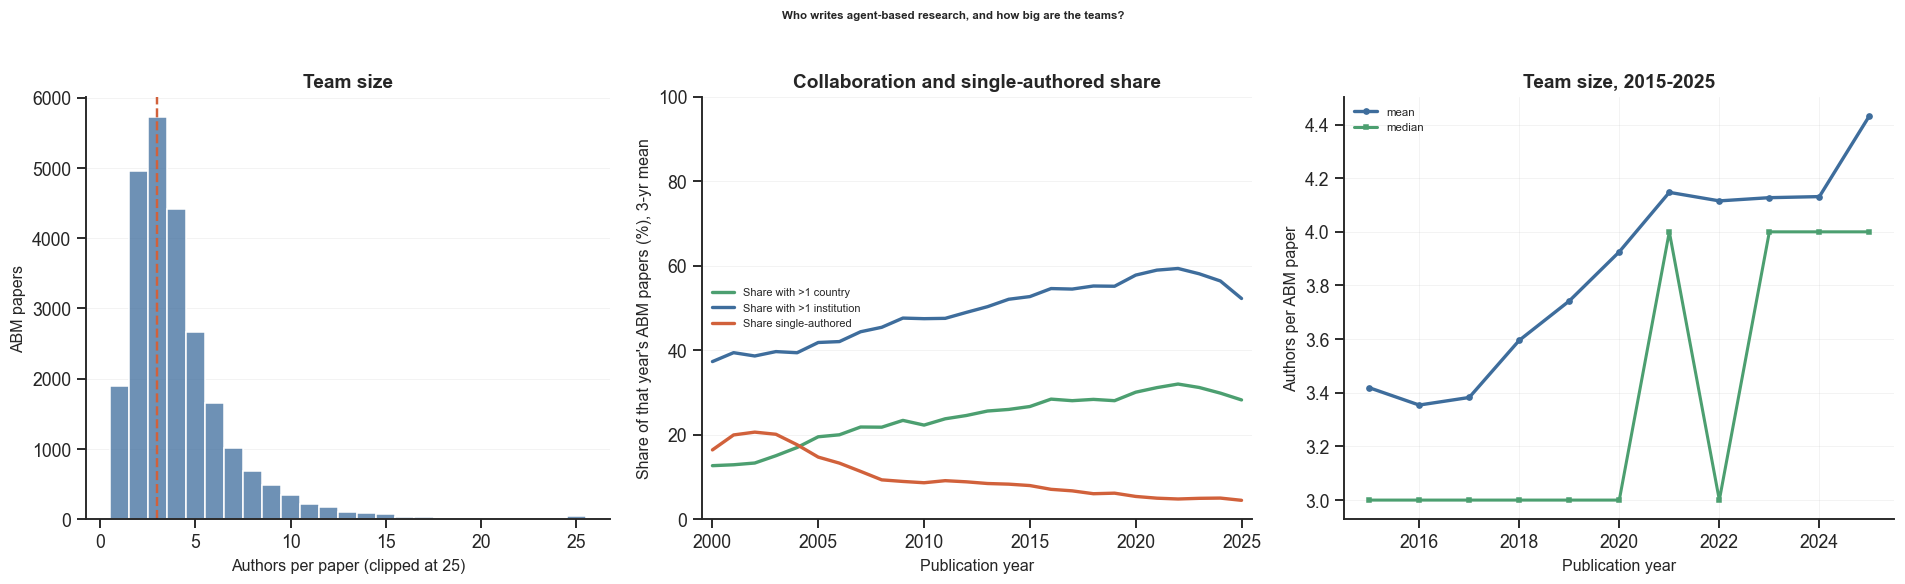

    -> fig24_authorship_a, fig24_authorship_b, fig24_authorship_c
  [fig 26] 24_authorship_structure -> 3 panels saved to figures/


WindowsPath('D:/Literature-Research-Agent/figures/_combined/24_authorship_structure.png')

In [38]:
# ------------------------------------------------------------------ 9.1 authorship scale and collaboration
auth_year = abm[abm["year_num"].between(2000, 2025)].copy()
auth_year["multi_country"] = auth_year["countries"].apply(lambda c: len(c) > 1)
auth_year["multi_inst"] = auth_year["institutions"].apply(lambda i: len(i) > 1)

fig, axes = plt.subplots(1, 3, figsize=(17.5, 5.2),
                         gridspec_kw={"width_ratios": [1, 1.05, 1.05]})

ax = axes[0]
n = auth_year["n_authors"].clip(upper=25)
sns.histplot(n, bins=np.arange(0.5, 26.5, 1), color=C["abm"], edgecolor="white", ax=ax)
ax.axvline(auth_year["n_authors"].median(), color=C["llm"], ls="--", lw=1.6)
ax.set_xlabel("Authors per paper (clipped at 25)")
ax.set_ylabel("ABM papers")
ax.set_title("Team size")
ax.grid(axis="x", visible=False)

ax = axes[1]
by_year = auth_year.groupby("year_num")
series = {
    "Share with >1 country": by_year["multi_country"].mean() * 100,
    "Share with >1 institution": by_year["multi_inst"].mean() * 100,
    "Share single-authored": by_year.apply(
        lambda g: (g["n_authors"] == 1).mean() * 100, include_groups=False),
}
for (label, s), color in zip(series.items(), [C["accent"], C["abm"], C["llm"]]):
    ax.plot(s.index, s.rolling(3, min_periods=1).mean(), lw=2.2, color=color, label=label)
ax.set_xlabel("Publication year")
ax.set_ylabel("Share of that year's ABM papers (%), 3-yr mean")
ax.set_title("Collaboration and single-authored share")
ax.legend(fontsize=7.2, loc="center left")
ax.set_xlim(1999.5, 2025.5)
ax.set_ylim(0, 100)
ax.grid(axis="x", visible=False)

ax = axes[2]
ev = (abm[abm["year_num"] >= 2015]
      .groupby("year_num")["n_authors"].agg(["mean", "median", "count"]))
ax.plot(ev.index, ev["mean"], lw=2.2, marker="o", ms=3.4, color=C["abm"], label="mean")
ax.plot(ev.index, ev["median"], lw=2.0, marker="s", ms=3.0, color=C["accent"], label="median")
ax.set_xlabel("Publication year")
ax.set_ylabel("Authors per ABM paper")
ax.set_title("Team size, 2015-2025")
ax.legend(fontsize=7.5)
ax.set_xlim(2014.5, LAST_YEAR + 0.5)

fig.suptitle("Who writes agent-based research, and how big are the teams?",
             fontsize=7.5, fontweight="bold", y=1.02)
fig.tight_layout()
save(fig, "24_authorship_structure",
     "Author counts come from the deduplicated author list per record; 281 records carry no author "
     "metadata and are excluded from the rate calculations but remain in the corpus.")

distinct countries in ABM papers: 172
ABM papers with at least one country tag: 23,240 / 29,139


,any,first,share
country,,,
United States,"8,531","6,417",29.28
United Kingdom,"3,600","2,274",12.35
China,"2,288","1,594",7.85
Germany,"2,170","1,375",7.45
Netherlands,"1,578",989,5.42
Canada,"1,463","1,017",5.02
France,"1,428",845,4.90
Australia,"1,247",803,4.28
Italy,"1,217",757,4.18


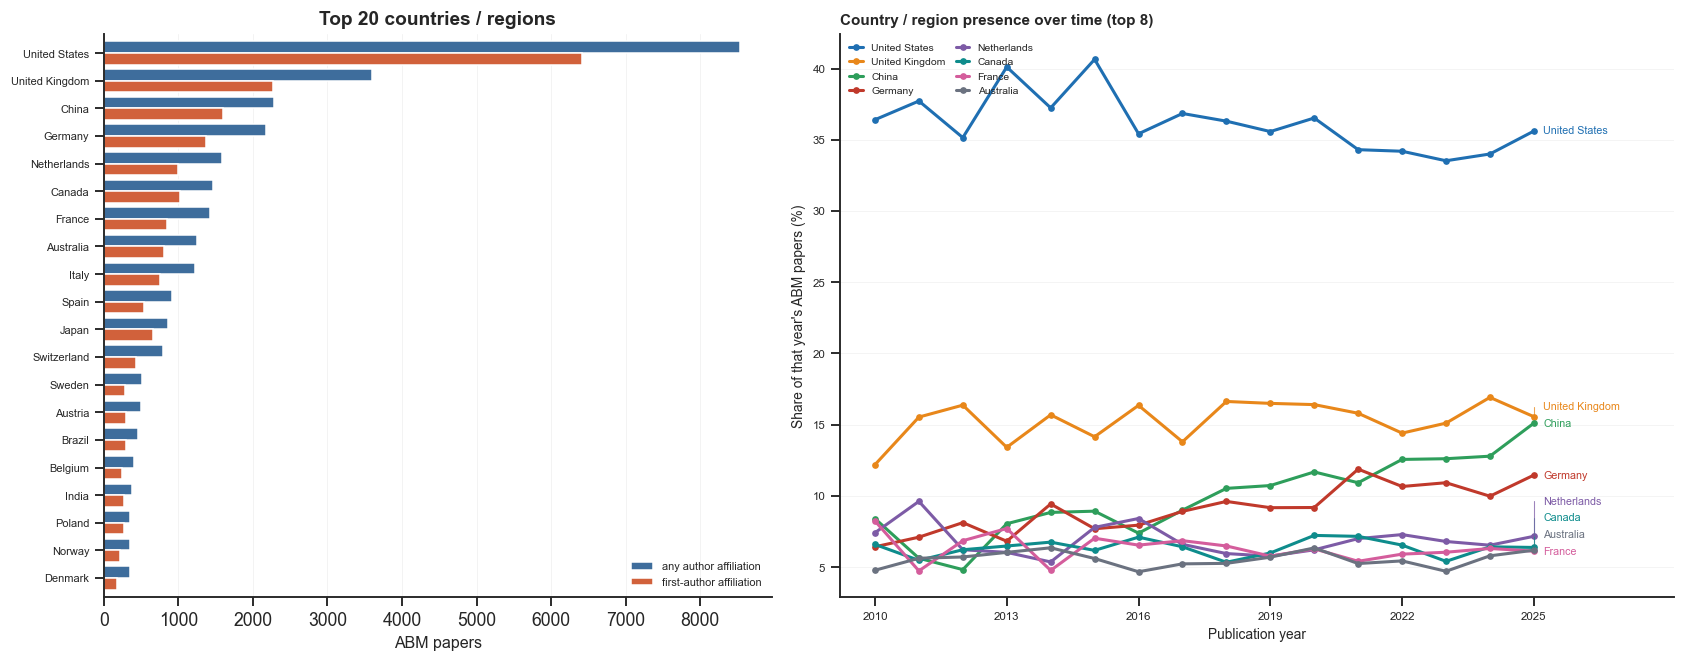

    -> fig25_countries_a, fig25_countries_b
  [fig 27] 25_country_composition -> 2 panels saved to figures/


WindowsPath('D:/Literature-Research-Agent/figures/_combined/25_country_composition.png')

In [39]:
# ------------------------------------------------------------------ 9.2 country composition
ctry_papers = Counter()          # any-author country
ctry_first = Counter()           # first-author country
for doc_id, rec in AUTHOR_META.items():
    cs = rec.get("c") or []
    for c in cs:
        ctry_papers[c] += 1
    if cs:
        ctry_first[cs[0]] += 1

abm_docs = set(abm["doc_id"])
abm_papers = Counter()
abm_first = Counter()
for doc_id in abm_docs:
    rec = AUTHOR_META.get(doc_id)
    if not rec:
        continue
    cs = rec.get("c") or []
    for c in cs:
        abm_papers[c] += 1
    if cs:
        abm_first[c] += 1

ctry = pd.DataFrame({"any": pd.Series(abm_papers), "first": pd.Series(abm_first)}).fillna(0)
ctry = ctry.sort_values("any", ascending=False)
ctry["share"] = ctry["any"] / len(abm) * 100
top_countries = list(ctry.head(20).index)
print(f"distinct countries in ABM papers: {len(ctry):,}")
print(f"ABM papers with at least one country tag: "
      f"{int(abm['countries'].apply(lambda c: len(c) > 0).sum()):,} / {len(abm):,}")
display(ctry.head(20).assign(country=[country_label(c) for c in ctry.head(20).index])
        .set_index("country").style.format(
            {"any": "{:,.0f}", "first": "{:,.0f}", "share": "{:.2f}"}))

fig, axes = plt.subplots(1, 2, figsize=(15.5, 6.2), gridspec_kw={"width_ratios": [1, 1.25]})

ax = axes[0]
d = ctry.head(20).iloc[::-1]
y = np.arange(len(d))
ax.barh(y + 0.21, d["any"], height=0.42, color=C["abm"], label="any author affiliation",
        edgecolor="white")
ax.barh(y - 0.21, d["first"], height=0.42, color=C["llm"], label="first-author affiliation",
        edgecolor="white")
ax.set_yticks(y)
ax.set_yticklabels([country_label(c) for c in d.index], fontsize=7.2)
ax.set_ylim(-0.7, len(d) - 0.3)
ax.set_xlabel("ABM papers")
ax.set_title("Top 20 countries / regions")
ax.legend(fontsize=7.2, loc="lower right")
ax.grid(axis="y", visible=False)

ax = axes[1]
# LINE chart, not grouped bars: eight countries over sixteen years is 128 bars, which cannot be read.
# A share over time is a trend, so a line per country is the natural form.
top8 = [c for c in top_countries[:8]]
_years = list(range(2010, LAST_YEAR + 1))
_series = {}
for c in top8:
    row = []
    for yr in _years:
        tot = hit = 0
        for doc_id in abm.loc[abm["year_num"] == yr, "doc_id"]:
            rec = AUTHOR_META.get(doc_id)
            if not rec:
                continue
            cs = rec.get("c") or []
            if not cs:
                continue
            tot += 1
            if c in cs:
                hit += 1
        row.append(100 * hit / tot if tot else np.nan)
    _series[c] = row
_share = pd.DataFrame(_series, index=_years)
_share = _share.loc[:, [c for c in _share.columns if _share[c].notna().any()]]

# A palette with real separation at 2 pt line width: tab10 spends one slot on a dark red and another
# on a brown that read as the same colour, and a third on a grey that disappears into the grid.
_palette = ["#1F6FB2", "#E8871A", "#2E9E5B", "#C0392B", "#7D5BA6", "#0E8C8C", "#D45D9C", "#6B7280"]
_ends = []
for col, color in zip(_share.columns, _palette):
    ax.plot(_share.index, _share[col], marker="o", ms=3.4, lw=2.0, color=color,
            label=country_label(col))
    _ends.append((_share.index[-1], _share[col].iloc[-1], country_label(col), color))
label_line_ends(ax, _ends, fontsize=7.0, x_off=6.0)
ax.set_xticks(list(range(2010, LAST_YEAR + 1, 3)))
ax.set_xlim(2009.2, LAST_YEAR + 3.2)
ax.set_xlabel("Publication year", fontsize=9)
ax.set_ylabel("Share of that year's ABM papers (%)", fontsize=9)
ax.set_title("Country / region presence over time (top 8)", fontsize=10, fontweight="bold",
             loc="left")
ax.tick_params(labelsize=7.5)
ax.grid(axis="x", visible=False)
ax.grid(axis="y", alpha=0.22, linewidth=0.6)
ax.legend(fontsize=6.8, ncol=2, loc="upper left", frameon=False, columnspacing=1.0,
          handlelength=1.3)
fig.tight_layout()
save(fig, "25_country_composition",
     "Panel A contrasts any-author and first-author attribution, so the gap between the two bars "
     "shows how often a country or region participates as a collaborator rather than as lead.")


baseline LLM penetration: 0.81 %


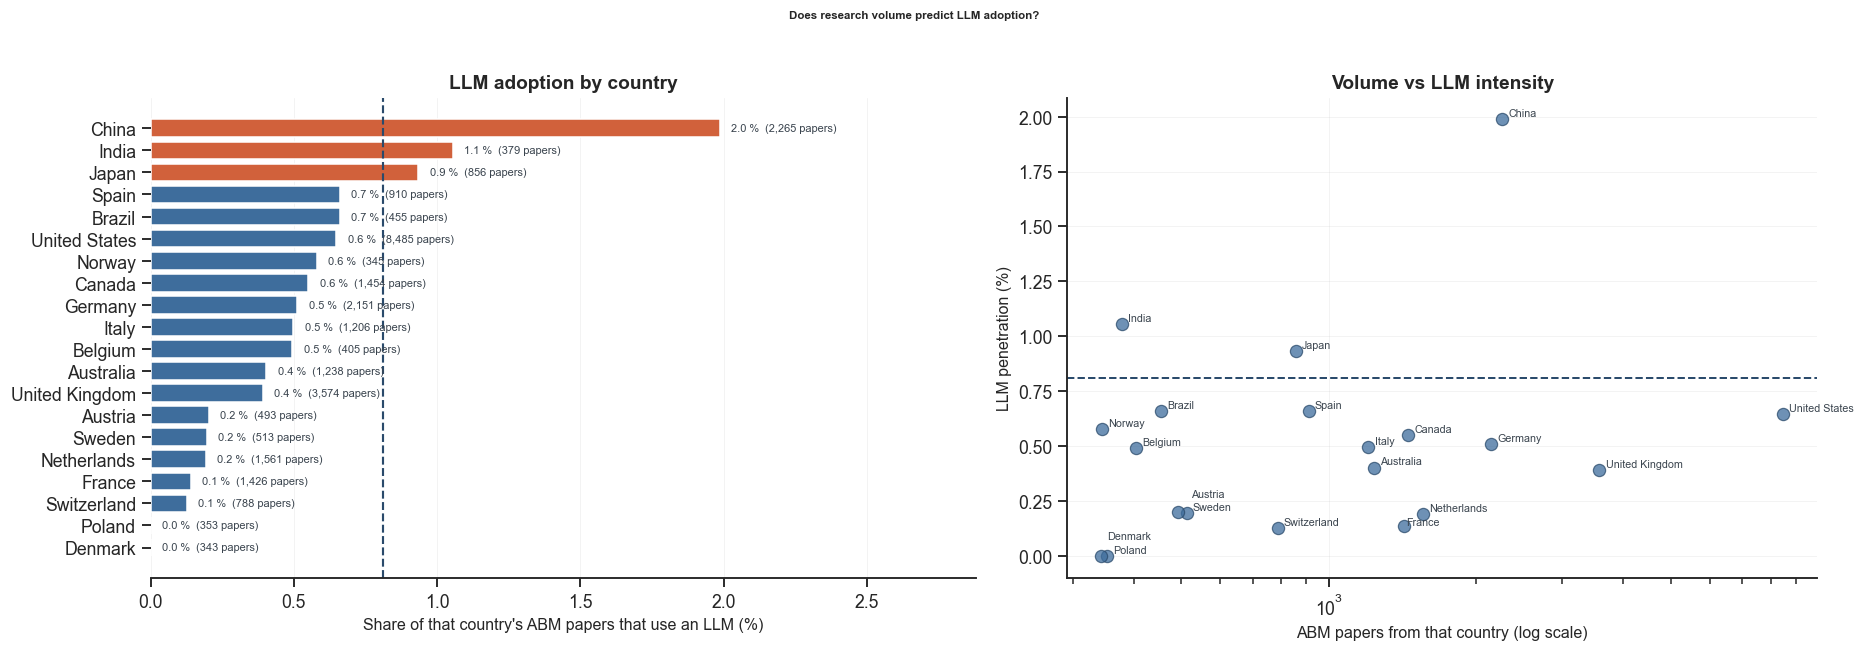

    -> fig26_country_llm_a, fig26_country_llm_b
  [fig 28] 26_country_llm_adoption -> 2 panels saved to figures/


WindowsPath('D:/Literature-Research-Agent/figures/_combined/26_country_llm_adoption.png')

In [40]:
# ------------------------------------------------------------------ 9.3 country volume vs LLM adoption
ctry_llm = {}
for c in top_countries:
    docs = abm.loc[abm["countries"].apply(lambda cs, c=c: c in cs)]
    ctry_llm[c] = {
        "papers": len(docs),
        "llm": int(((docs["llama_llm_has_llm"] == 1)
                    & (docs["year_num"] <= LAST_YEAR)).sum()),
    }
cl = pd.DataFrame(ctry_llm).T
cl["penetration"] = cl["llm"] / cl["papers"] * 100
base_pen = 100 * int(LLM_WINDOW.sum()) / len(abm)
print(f"baseline LLM penetration: {base_pen:.2f} %")

fig, axes = plt.subplots(1, 2, figsize=(16.8, 5.8), gridspec_kw={"width_ratios": [1.1, 1]})

ax = axes[0]
d = cl.sort_values("penetration")
bars = ax.barh([country_label(c) for c in d.index], d["penetration"],
               color=[C["llm"] if v > base_pen else C["abm"] for v in d["penetration"]],
               edgecolor="white")
ax.axvline(base_pen, color=C["abm_dark"], ls="--", lw=1.4)

for b, (c, row) in zip(bars, d.iterrows()):
    ax.text(b.get_width() + d["penetration"].max() * 0.02, b.get_y() + b.get_height() / 2,
            f"{row['penetration']:.1f} %  ({int(row['papers']):,} papers)",
            va="center", fontsize=7.2, color="#3A444E")
ax.set_xlim(0, d["penetration"].max() * 1.45)
ax.set_xlabel("Share of that country's ABM papers that use an LLM (%)")
ax.set_title("LLM adoption by country")
ax.grid(axis="y", visible=False)
sns.despine(ax=ax, left=True)

ax = axes[1]
ax.scatter(cl["papers"], cl["penetration"], s=64, color=C["abm"], alpha=0.75,
           edgecolor=C["abm_dark"], linewidth=0.8)
ax.axhline(base_pen, color=C["abm_dark"], ls="--", lw=1.3)
ax.set_xscale("log")
ax.set_xlabel("ABM papers from that country (log scale)")
ax.set_ylabel("LLM penetration (%)")
ax.set_title("Volume vs LLM intensity")
ax.grid(alpha=0.25)

fig.suptitle("Does research volume predict LLM adoption?",
             fontsize=7.5, fontweight="bold", y=1.02)
fig.tight_layout()
fig.tight_layout()
# twenty names around a log axis cluster wherever volumes are similar, so they are placed last: set_xscale
# and tight_layout both move the mapping the placement is measured against, and tight_layout ran after
# the labels the first time round
_pairs = sorted(((c, row) for c, row in cl.iterrows()), key=lambda t: -t[1]["papers"])
label_points(ax, [(row["papers"], row["penetration"], country_label(c)[:14], "#3A444E")
                  for c, row in _pairs], fontsize=7.0)
save(fig, "26_country_llm_adoption",
     "Country tags come from institutional affiliations, so a paper with authors in two countries "
     "contributes to both. Penetration is a within-country share, hence comparable across very "
     "different volumes; the correlation between log volume and penetration across the top 20 is "
     "essentially zero (r = -0.01), so volume does not predict adoption.")

distinct institutions in ABM papers: 10,122

institution types (papers):
education     21907
facility       5440
government     3278
nonprofit      2270
healthcare     2182
company        1662
other           798
funder          525
archive         234


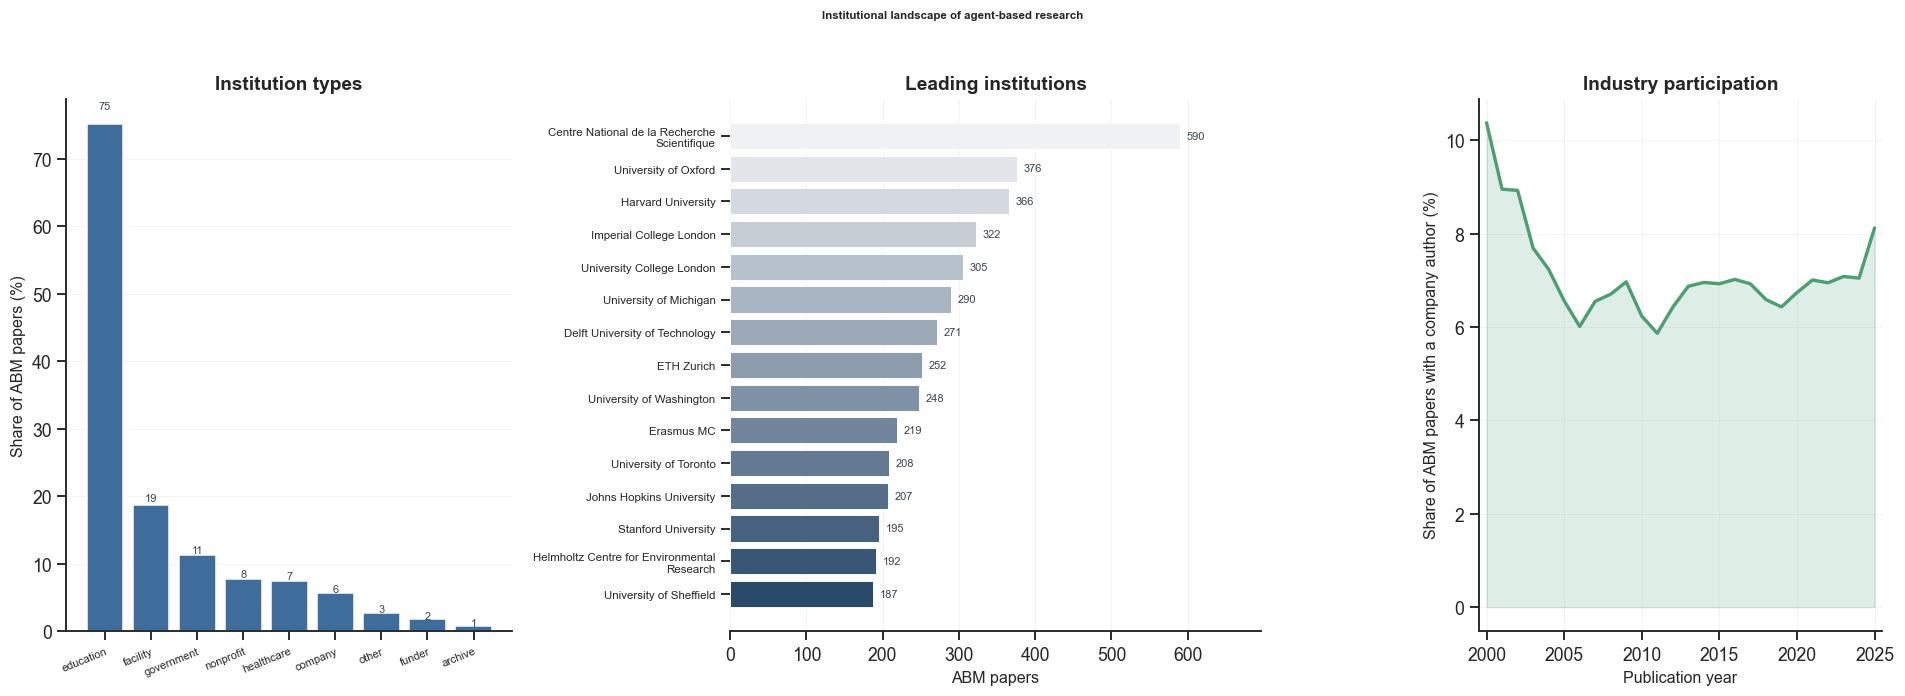

    -> fig27_institutions_a, fig27_institutions_b, fig27_institutions_c
  [fig 29] 27_institutions -> 3 panels saved to figures/


WindowsPath('D:/Literature-Research-Agent/figures/_combined/27_institutions.png')

In [41]:
# ------------------------------------------------------------------ 9.4 institution types and leading institutions
inst_papers = Counter()
inst_types_papers = Counter()
for doc_id in abm["doc_id"]:
    rec = AUTHOR_META.get(doc_id)
    if not rec:
        continue
    for i in (rec.get("i") or []):
        inst_papers[i] += 1
    for t in (rec.get("t") or []):
        inst_types_papers[t] += 1

inst = pd.Series(inst_papers).sort_values(ascending=False)
itypes = pd.Series(inst_types_papers).sort_values(ascending=False)
print(f"distinct institutions in ABM papers: {len(inst):,}")
print("\ninstitution types (papers):")
print(itypes.to_string())

fig, axes = plt.subplots(1, 3, figsize=(17.5, 6.2),
                         gridspec_kw={"width_ratios": [1.05, 1.25, 0.95]})

ax = axes[0]
share = itypes / len(abm) * 100
bars = ax.bar([wrap(i, 12) for i in share.index], share.values, color=C["abm"], edgecolor="white")
for b, v in zip(bars, share.values):
    ax.text(b.get_x() + b.get_width() / 2, v * 1.03, f"{v:.0f}", ha="center", fontsize=7.2,
            color="#3A444E")
ax.set_ylabel("Share of ABM papers (%)")
ax.set_title("Institution types")
ax.grid(axis="x", visible=False)
# a category slot is narrower than the type names in the composite row, which put "government" on top of
# "company"; the slight rotation buys the room back without shortening the labels
ax.tick_params(axis="x", labelsize=7.2)
plt.setp(ax.get_xticklabels(), rotation=22, ha="right", rotation_mode="anchor")

ax = axes[1]
d = inst.head(15).iloc[::-1]
hbar(ax, d, colors=sns.light_palette(C["abm_dark"], n_colors=15)[::-1])
ax.set_xlabel("ABM papers")
ax.set_title(f"Leading institutions")
ax.grid(axis="x", alpha=0.25)
ax.tick_params(axis="y", labelsize=7.5)

ax = axes[2]
# company involvement over time: the clearest industry signal available
comp = []
years = list(range(2000, 2026))
for yr in years:
    docs = abm.loc[abm["year_num"] == yr, "doc_id"]
    tot = hit = 0
    for doc_id in docs:
        rec = AUTHOR_META.get(doc_id)
        if not rec:
            continue
        ts = rec.get("t") or []
        if not ts:
            continue
        tot += 1
        if "company" in ts:
            hit += 1
    comp.append(100 * hit / tot if tot else np.nan)
comp = pd.Series(comp, index=years)
ax.plot(comp.index, comp.rolling(3, min_periods=1).mean(), lw=2.2, color=C["accent"])
ax.fill_between(comp.index, comp.rolling(3, min_periods=1).mean(), color=C["accent"], alpha=0.18)
ax.set_xlabel("Publication year")
ax.set_ylabel("Share of ABM papers with a company author (%)")
ax.set_title("Industry participation")
ax.set_xlim(1999.5, 2025.5)

fig.suptitle("Institutional landscape of agent-based research",
             fontsize=7.5, fontweight="bold", y=1.02)
fig.tight_layout()
save(fig, "27_institutions",
     "Institution names are taken verbatim from the source ROR-linked records, so name variants "
     "('Univ.' vs 'University') remain distinct and absolute counts are conservative. The upstream "
     "ROR type labels are applied inconsistently across records, so panel A should be read as "
     "'education dominates, industry is a small minority' rather than as an exact partition.")

**Section 9 findings.**

* ABM teams are **small and only slowly growing** (mean ≈ 4 authors), and single-authored ABM work
  is a declining minority. Collaboration, measured by multi-institution and multi-country papers,
  rises steadily across the whole 2000–2025 window.
* **LLM-based papers are the exception to that trend**: they average 5.46 authors against 3.89, but
  only 13.3 % of them are multi-country against 27.2 % of conventional ABM papers. Larger teams,
  narrower geographic reach — consistent with a young literature where early work concentrates in a
  few well-resourced national groups.
* Output is **moderately concentrated but not dominated by one country**: the United States and
  China are the two largest contributors, together accounting for 37.4 % of all country tags,
  with the top five at 52.7 % and the top ten at 68.2 %. The United Kingdom, Germany, Canada,
  France, Italy and Australia form the next tier.
* The gap between any-author and first-author attribution is informative: China appears in 91.6 % of
  its appearances as the *first-author* country, against 59.8 % for the United Kingdom and 57.9 % for
  Australia — i.e. the latter appear relatively more often as collaborators than as leads.
* **Country volume does not predict LLM adoption.** Penetration varies more than tenfold across the
  top-20 countries (0.7 % to 7.0 %) while volume varies about twentyfold, and the correlation between
  log volume and penetration is essentially zero (r = −0.01). Adoption is a property of research
  culture and sub-field mix, not of sheer output — which is exactly what the topic-level analysis in
  Sections 6c and 7 predicts.
* Universities dominate institution types (present in 84 % of ABM papers), but company-affiliated
  authorship is a small, identifiable slice (6.6 %) worth tracking in future corpus updates.

## 9b. Collaboration between research domains

Agent-based modelling is a cross-disciplinary method, so the useful question is not only how large
each domain is but **how often two domains meet in the same paper**. Every ABM-positive paper is
matched against all domain rules (not just the first match), so a paper can carry several domains.
The matrix counts papers per domain pair, and the concentration chart shows how interdisciplinary
each domain is: the share of its papers that also carry another domain.

papers with at least one domain tag: 28,267 / 29,139
mean domains per paper: 2.48
interdisciplinary papers (2+ domains): 24,360 (83.6 %)


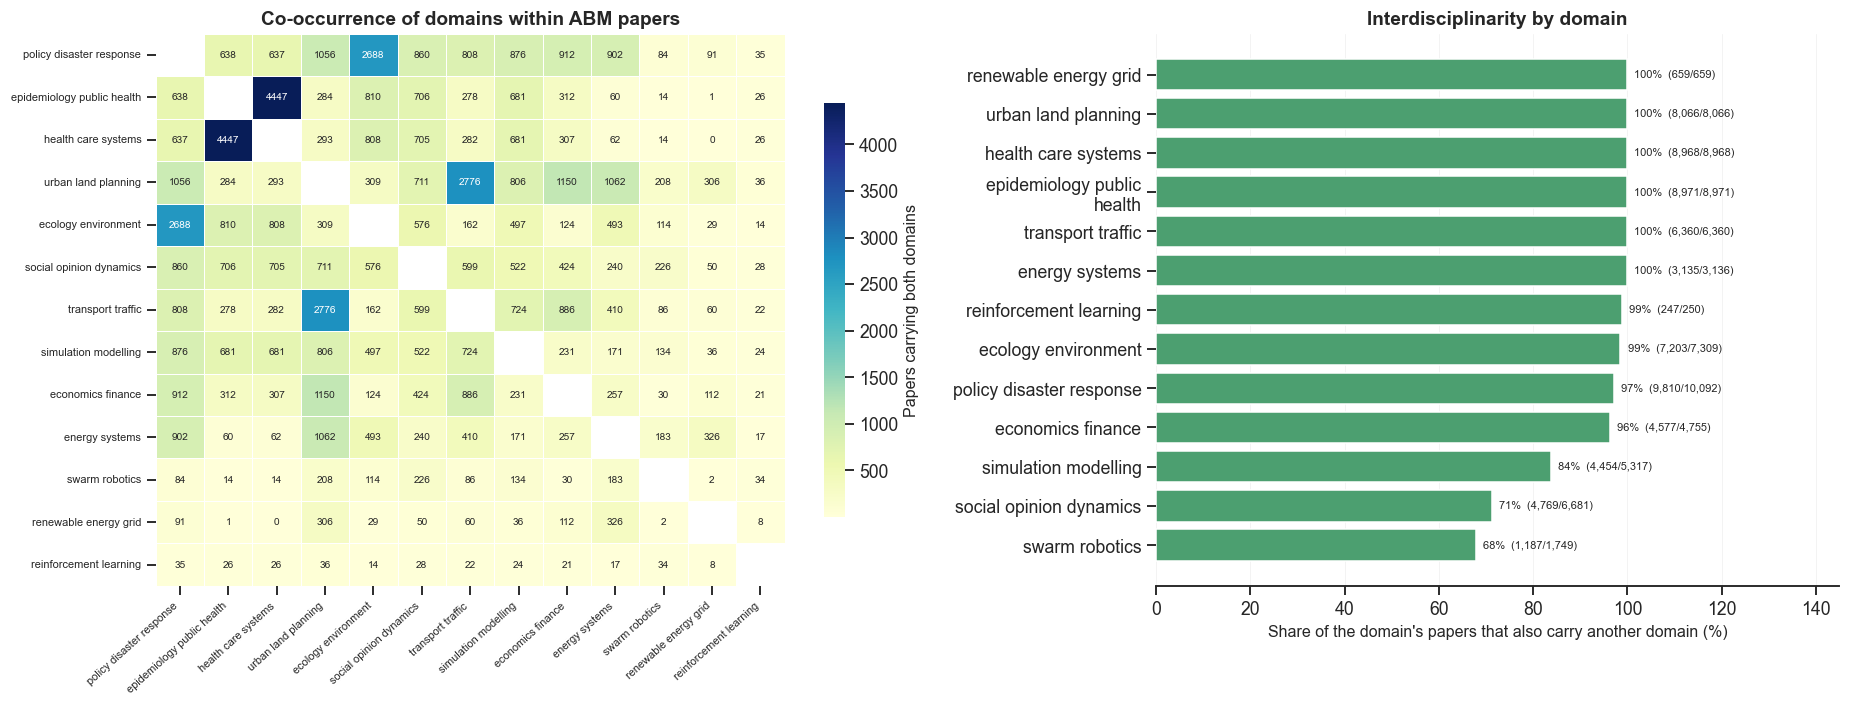

    -> fig31_domain_collaboration_a, fig31_domain_collaboration_b
  [fig 30] 31_domain_collaboration -> 2 panels saved to figures/


WindowsPath('D:/Literature-Research-Agent/figures/_combined/31_domain_collaboration.png')

In [42]:
# ------------------------------------------------------------------ 9b cross-domain collaboration
# multi-label domain matching, so one paper can belong to several domains at once
DOMAIN_TAGS = {
    "renewable_energy_grid": ["renewable", "solar", "wind power", "smart grid", "power grid",
                              "microgrid", "electricity market", "energy market", "battery"],
    "energy_systems": ["energy", "power system", "carbon", "emission", "electricity",
                       "sustainab", "resource management"],
    "epidemiology_public_health": ["epidemi", "pandemic", "infectious", "covid", "outbreak",
                                   "vaccin", "disease transmission", "public health",
                                   "compartmental"],
    "ecology_environment": ["ecolog", "ecosystem", "species", "wildlife", "conservation",
                            "biodiversity", "agricultur", "forest", "fishery", "biological",
                            "climate"],
    "health_care_systems": ["health", "hospital", "patient", "clinical", "medical",
                            "healthcare", "health care", "mental health", "cancer", "oncology"],
    "transport_traffic": ["transport", "traffic", "mobility", "commut", "vehicle routing",
                          "transit", "logistics", "supply chain", "pedestrian", "travel"],
    "urban_land_planning": ["urban", "land use", "land-use", "city", "cities", "regional",
                            "housing", "spatial planning", "smart city", "infrastructure"],
    "social_opinion_dynamics": ["opinion", "social network", "social dynamic", "behaviour",
                                "behavior", "cultural", "sociolog", "voting", "crowd",
                                "social simulation", "education", "crime"],
    "economics_finance": ["market", "financial", "economic", "banking", "investment", "firm",
                          "consumer", "pricing", "trade", "labour", "labor"],
    "policy_disaster_response": ["policy", "disaster", "emergency", "resilience", "crisis",
                                 "governance", "regulation", "risk management", "military",
                                 "defense", "defence"],
    "swarm_robotics": ["swarm", "robot", "flocking", "multi-robot", "collective behavior"],
    "reinforcement_learning": ["reinforcement learning", "deep learning", "machine learning",
                               "neural network"],
    "agent_based_modelling": ["agent-based", "agent based", "individual-based", "multi-agent",
                              "multiagent", "multi agent"],
    "simulation_modelling": ["simulation", "microsimulation", "monte carlo", "system dynamic",
                             "computational model", "mathematical model"],
}
# agent_based_modelling is defined above but NOT applied: every paper in this corpus is agent-based,
# so the tag would sit on almost the whole corpus and could not discriminate between domains.
SKIP_DOMAIN_TAGS = {"agent_based_modelling"}
_DOMAIN_RE = [(n, re.compile("|".join(re.escape(p) for p in pats), re.I))
              for n, pats in DOMAIN_TAGS.items() if n not in SKIP_DOMAIN_TAGS]
DOMAIN_LIST = [n for n, _ in _DOMAIN_RE]


def domains_of(domain, category, keywords, secondary):
    text = " | ".join([str(domain or ""), str(category or ""),
                       ", ".join(str(k) for k in to_list(keywords)),
                       ", ".join(str(k) for k in to_list(secondary))])
    return [n for n, rx in _DOMAIN_RE if rx.search(text)]


abm["domain_tags"] = [domains_of(d, c, k, s) for d, c, k, s in zip(
    abm["llama_primary_domain"], abm["llama_topic_category"],
    abm["llama_topic_keywords"], abm["llama_secondary_topics"])]
_n_tags = abm["domain_tags"].apply(len)
print(f"papers with at least one domain tag: {int((_n_tags > 0).sum()):,} / {len(abm):,}")
print(f"mean domains per paper: {_n_tags.mean():.2f}")
_multi = abm[_n_tags > 1]
print(f"interdisciplinary papers (2+ domains): {len(_multi):,} "
      f"({100 * len(_multi) / len(abm):.1f} %)")

# -------- domain x domain co-occurrence
_co = pd.DataFrame(0, index=DOMAIN_LIST, columns=DOMAIN_LIST, dtype=float)
for tags in abm["domain_tags"]:
    for a in tags:
        for b in tags:
            if a != b:
                _co.loc[a, b] += 1
_co = _co.div(2)                      # each pair counted twice

_domain_papers = pd.Series(
    {n: int(abm["domain_tags"].apply(lambda t, n=n: n in t).sum()) for n in DOMAIN_LIST})
_keep = _domain_papers[_domain_papers >= 200].sort_values(ascending=False).index.tolist()
_co = _co.loc[_keep, _keep]

fig, axes = plt.subplots(1, 2, figsize=(17.0, 6.6), gridspec_kw={"width_ratios": [1.15, 1]})

ax = axes[0]
_diag = np.zeros_like(_co.to_numpy())
np.fill_diagonal(_diag, np.nan)
_plot = _co.to_numpy().astype(float)
np.fill_diagonal(_plot, np.nan)
sns.heatmap(pd.DataFrame(_plot, index=_co.index, columns=_co.columns), cmap="YlGnBu",
            linewidths=0.5, linecolor="white", ax=ax, annot=True, fmt=".0f",
            annot_kws={"fontsize": 6.6},
            cbar_kws={"label": "Papers carrying both domains", "shrink": 0.75})
# rule names are identifiers; show them as words
_domain_display = lambda s: s.replace("_", " ")  # noqa: E731
ax.set_xticklabels([_domain_display(c) for c in _co.columns], rotation=42, ha="right", fontsize=7.2)
ax.set_yticklabels([_domain_display(i) for i in _co.index], rotation=0, fontsize=7.2)
ax.set_title("Co-occurrence of domains within ABM papers")
ax.grid(False)

ax = axes[1]
_inter = pd.DataFrame({
    "multi": abm[_n_tags > 1]["domain_tags"].apply(lambda t: pd.Series(t)).stack().value_counts(),
}).reindex(_keep).fillna(0)["multi"]
_mix = pd.DataFrame({"papers": _domain_papers[_keep], "multi": _inter})
_mix["share"] = _mix["multi"] / _mix["papers"] * 100
_mix = _mix.sort_values("share")
_bars = ax.barh([wrap(_domain_display(i), 24) for i in _mix.index], _mix["share"],
                color=C["accent"], edgecolor="white")
for b, (name, row) in zip(_bars, _mix.iterrows()):
    ax.text(b.get_width() + _mix["share"].max() * 0.015,
            b.get_y() + b.get_height() / 2,
            f"{row['share']:.0f}%  ({int(row['multi']):,}/{int(row['papers']):,})",
            va="center", fontsize=7.2)
ax.set_xlim(0, _mix["share"].max() * 1.45)
ax.set_xlabel("Share of the domain's papers that also carry another domain (%)")
ax.set_title("Interdisciplinarity by domain")
ax.grid(axis="y", visible=False)
sns.despine(ax=ax, left=True)

fig.tight_layout()
save(fig, "31_domain_collaboration",
     "Domains are matched multi-label from the stage-3 domain, category and keyword fields, so a "
     "paper can carry several domains; the diagonal is blank by construction.")


## 10. Publication-ready comparison table

A compact summary that can be lifted into a manuscript, contrasting LLM-based ABM papers with the
rest of the ABM corpus across size, geography, topics and institutions.

In [43]:
def top_list(series, n=5):
    c = Counter()
    for lst in series:
        c.update({canon_kw(k) for k in to_list(lst)})
    return ", ".join(k for k, _ in c.most_common(n))


def top_agents(g, n=3):
    c = Counter()
    for raw in g["llama_agent_types"]:
        c.update(set(agent_tokens(raw)))
    return ", ".join(k for k, _ in c.most_common(n))


def country_mix(g, n=3):
    """Most frequent countries for a group of papers, from the author sidecar."""
    c = Counter()
    for doc_id in g["doc_id"]:
        rec = AUTHOR_META.get(doc_id)
        if rec:
            c.update(rec.get("c") or [])
    return ", ".join(f"{country_label(k)} ({v:,})" for k, v in c.most_common(n))


def top_institutions(g, n=3):
    c = Counter()
    for doc_id in g["doc_id"]:
        rec = AUTHOR_META.get(doc_id)
        if rec:
            c.update(rec.get("i") or [])
    return ", ".join(f"{k} ({v:,})" for k, v in c.most_common(n))


groups = {
    "LLM-based ABM": abm[(abm["llama_llm_has_llm"] == 1) & (abm["year_num"] <= LAST_YEAR)],
    "Conventional ABM": abm[abm["llama_llm_has_llm"] == 0],
}
rows = []
for name, g in groups.items():
    dom = g["macro_domain"].value_counts()
    dom = dom[dom.index != "Unclassified"]
    rows.append({
        "Group": name,
        "Papers": len(g),
        "Share of ABM corpus": len(g) / len(abm),
        "Median year": int(g["year_num"].median()),
        "Share published 2023+": (g["year_num"] >= 2023).mean(),
        "Mean authors per paper": g["n_authors"].mean(),
        "Share multi-country": g["countries"].apply(lambda c: len(c) > 1).mean(),
        "Share with a company author": g["inst_types"].apply(lambda t: "company" in t).mean(),
        "Top macro-domain": f"{dom.index[0]} ({100 * dom.iloc[0] / len(g):.0f} %)",
        "Top agent types": top_agents(g, 3),
        "Top countries": country_mix(g, 3),
        "Top institutions": top_institutions(g, 2),
        "Top keywords": top_list(g["llama_topic_keywords"], 5),
    })
summary = pd.DataFrame(rows).set_index("Group")
with pd.option_context("display.max_colwidth", 78):
    display(summary.T)

summary.T.to_csv(FIG_DIR / "summary_table.csv", index=True)
print(f"saved -> {FIG_DIR / 'summary_table.csv'}")

# figures inventory
figs = sorted(FIG_DIR.glob("*.png"))
print(f"\n{len(figs)} figures written to {FIG_DIR}:")
for f in figs:
    print(f"   {f.name:<42} {f.stat().st_size / 1024:7.1f} KB")

Group,LLM-based ABM,Conventional ABM
Papers,236,24147
Share of ABM corpus,0.008,0.829
Median year,2025,2018
Share published 2023+,1.000,0.211
Mean authors per paper,5.102,4.113
Share multi-country,0.203,0.328
Share with a company author,0.093,0.068
Top macro-domain,Social & Opinion Dynamics (34 %),Health & Epidemiology (34 %)
Top agent types,"Individuals / households, Network nodes / generic, Software / LLM agents","Individuals / households, Patients / biological, Network nodes / generic"
Top countries,"United States (55), China (45), United Kingdom (14)","United States (8,430), United Kingdom (3,560), China (2,220)"


saved -> D:\Literature-Research-Agent\figures\summary_table.csv

79 figures written to D:\Literature-Research-Agent\figures:
   29_subtopic_composition_a.png                163.6 KB
   31_covid_effect_a.png                        101.9 KB
   31_covid_effect_b.png                        115.0 KB
   34_llm_role_composition_a.png                 63.2 KB
   35_llm_agent_families_a.png                   55.0 KB
   36_llm_vocabulary_shift_a.png                216.8 KB
   37_llm_content_shifts_a.png                  109.0 KB
   38_agent_types_over_time.png                 352.4 KB
   40_llm_entry_stages.png                      163.3 KB
   42_epoch_method.png                          180.5 KB
   43_epoch_topic_agent.png                      80.1 KB
   44_epoch_temporal_collaboration.png          175.7 KB
   45_peak_statistics.png                       111.9 KB
   fig01_corpus_growth_a.png                     42.0 KB
   fig01_corpus_growth_b.png                     67.8 KB
   fig02_abm_share_a

## 11. Screening funnel: how many documents remain at each level

The pipeline is a cascade, and each stage removes documents. This section records the exact count that
survives every level, so the final analysis can be traced back to the raw retrieval.

Two facts about the counts are worth stating before the table:

* the corpus is **322,742 retrieved records**, of which **88,954** pass stage-1 ABM screening. That is
  **27.56 %**, not the 20.68 % quoted for the earlier version of the corpus;
* the year window matters more than it looks. Excluding 2026 and later removes **11,556** records, and
  those records are disproportionately recent LLM-based work: stage 2 detects an LLM on **4,318**
  ABM-positive papers across all years but only **2,396** inside 1990-2025. The LLM figures in
  Section 4 therefore describe the window, not the whole harvest.

`llama_stage_status` carries a single value (`complete`) for every record in this version of the
corpus, so it is not a useful filter; the real cascade is the year window and the stage-1 decision.


SCREENING FUNNEL
 level                          filter  remaining  removed  retained_%  step_%
     0               Retrieved records      29139        0     100.000 100.000
     1                     Year parsed      29137        2      99.990  99.990
     2               Year in 1990-2025      29124       13      99.950  99.960
     3           Stage 1: ABM-positive      29124        0      99.950 100.000
     4     Stage 2: scored for LLM use      24370     4754      83.630  83.680
     5 Stage 3: topic keywords present      23675      695      81.250  97.150
     6            With author metadata      23665       10      81.210  99.960


Level,Filter applied,Documents remaining,Removed here,% of retrieved,% of previous level,Note
0,Retrieved records,"29,139",,100.00,100.00,"raw harvest, all sources"
1,Year parsed,"29,137",-2,99.99,99.99,2 records carry no usable year
2,Year in 1990-2025,"29,124",-13,99.95,99.96,"0 dated 2026+, 13 before 1990"
3,Stage 1: ABM-positive,"29,124",,99.95,100.00,"0 rejected as not agent-based, 0 model failures"
4,Stage 2: scored for LLM use,"24,370","-4,754",83.63,83.68,"within this set 236 use an LLM by 2025 and 24,147 do not"
5,Stage 3: topic keywords present,"23,675",-695,81.25,97.15,"topic fields populated, used by the topic and keyword figures"
6,With author metadata,"23,665",-10,81.21,99.96,used by the authorship and collaboration-network analyses


saved -> D:\Literature-Research-Agent\figures\screening_funnel.csv


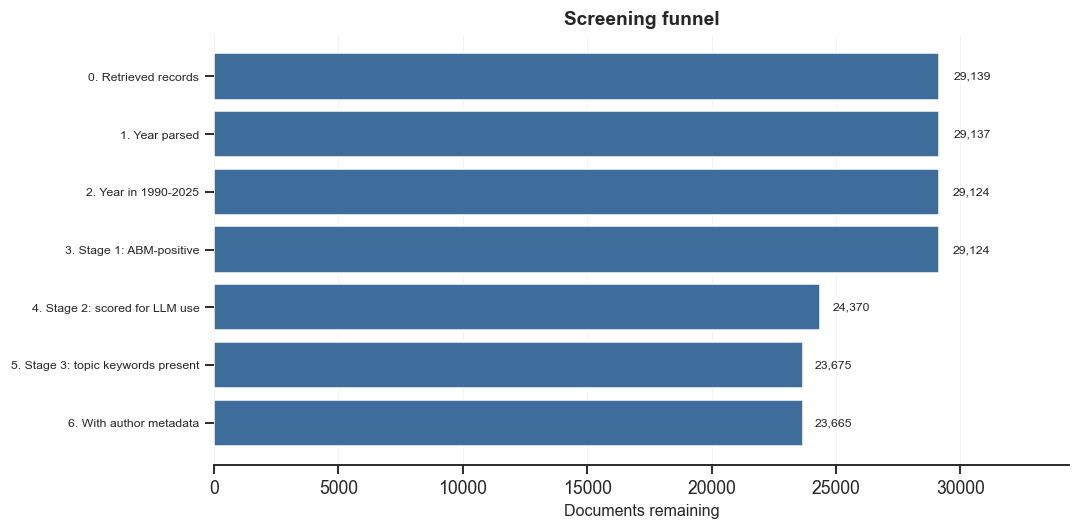

    -> funnel_screening_a
  [fig 31] funnel_screening -> 1 panels saved to figures/


WindowsPath('D:/Literature-Research-Agent/figures/_combined/funnel_screening.png')

In [44]:
# ------------------------------------------------------------------ screening funnel
# Each stage filters the population that SURVIVED the previous one. Building every mask from the
# full frame instead would let a later stage keep records an earlier stage had already dropped,
# which produces negative "removed" counts and step retention above 100 %.
_yr = df["year_num"]
_in_window = _yr.between(FOCUS_YEARS[0], LAST_YEAR)
_n_authors = pd.to_numeric(df["n_authors"], errors="coerce").fillna(0)

funnel_steps = [
    ("Retrieved records", pd.Series(True, index=df.index),
     "raw harvest, all sources"),
    ("Year parsed", _yr.notna(),
     f"{int(_yr.isna().sum()):,} records carry no usable year"),
    (f"Year in {FOCUS_YEARS[0]}-{LAST_YEAR}", _in_window,
     f"{int((_yr > LAST_YEAR).sum()):,} dated {LAST_YEAR + 1}+, "
     f"{int((_yr < FOCUS_YEARS[0]).sum()):,} before {FOCUS_YEARS[0]}"),
    ("Stage 1: ABM-positive", df["llama_abm_is_abm"] == 1,
     f"{int((df['llama_abm_is_abm'] == 0).sum()):,} rejected as not agent-based, "
     f"{int((df['llama_abm_is_abm'] == -1).sum()):,} model failures"),
    ("Stage 2: scored for LLM use", df["llama_llm_has_llm"].isin([0, 1]),
     f"within this set {int(LLM_WINDOW.sum()):,} use an LLM by {LAST_YEAR} and "
     f"{int(((df['llama_llm_has_llm'] == 0) & (df['year_num'] <= LAST_YEAR)).sum()):,} do not"),
    ("Stage 3: topic keywords present",
     df["llama_topic_keywords"].apply(lambda v: len(to_list(v)) > 0),
     "topic fields populated, used by the topic and keyword figures"),
    ("With author metadata", _n_authors > 0,
     "used by the authorship and collaboration-network analyses"),
]

steps = []
_keep = pd.Series(True, index=df.index)
for _level, (_label, _cond, _note) in enumerate(funnel_steps):
    _prev = int(_keep.sum())
    _keep = _keep & _cond.reindex(df.index).fillna(False).astype(bool)
    _now = int(_keep.sum())
    steps.append({"level": _level, "filter": _label, "remaining": _now,
                  "removed": _prev - _now,
                  "step_%": round(100 * _now / _prev, 2) if _prev else 0.0,
                  "note": _note})

funnel = pd.DataFrame(steps)
funnel["retained_%"] = (100 * funnel["remaining"] / funnel["remaining"].iloc[0]).round(2)

# the funnel must never grow at any stage, and no stage may retain more than it received
assert funnel["remaining"].is_monotonic_decreasing, "funnel is not monotonic"
assert (funnel["removed"] >= 0).all(), "a stage removed a negative number of records"
assert (funnel["step_%"] <= 100.0001).all(), "a stage retained more than it received"

print("SCREENING FUNNEL")
print(funnel[["level", "filter", "remaining", "removed", "retained_%", "step_%"]]
      .to_string(index=False))

# HTML version, so the table reads like a results panel rather than plain text
_html = funnel[["level", "filter", "remaining", "removed", "retained_%", "step_%", "note"]].copy()
_html["remaining"] = _html["remaining"].map("{:,}".format)
_html["removed"] = _html["removed"].map(lambda v: f"-{int(v):,}" if v else "")
_html["retained_%"] = _html["retained_%"].map("{:.2f}".format)
_html["step_%"] = _html["step_%"].map("{:.2f}".format)
_html.columns = ["Level", "Filter applied", "Documents remaining", "Removed here",
                 "% of retrieved", "% of previous level", "Note"]
display(HTML(_html.to_html(index=False, border=0, justify="left",
                           classes="funnel-table")))

funnel.to_csv(FIG_DIR / "screening_funnel.csv", index=False)
print(f"saved -> {FIG_DIR / 'screening_funnel.csv'}")

# ---- the same funnel as a figure
fig, ax = plt.subplots(figsize=(10.0, 5.0))
_labels = [f"{r['level']}. {r['filter']}" for _, r in funnel.iterrows()]
ax.barh(range(len(funnel)), funnel["remaining"], color=C["abm"], edgecolor="white")
ax.set_yticks(range(len(funnel)))
ax.set_yticklabels(_labels, fontsize=8)
ax.invert_yaxis()
for i, v in enumerate(funnel["remaining"]):
    ax.text(v * 1.02, i, f"{v:,}", va="center", fontsize=8)
ax.set_xlabel("Documents remaining")
ax.set_title("Screening funnel")
ax.set_xlim(0, funnel["remaining"].max() * 1.18)
ax.grid(axis="y", visible=False)
sns.despine(ax=ax, left=True)
fig.tight_layout()
save(fig, "funnel_screening")


## 11. Does the LLM change the modelling?

The earlier figures measure *how much* LLM-based ABM exists. This section asks whether the research itself differs. The treatment group splits in two: papers where the LLM **is** the agent's decision engine, and papers where the LLM is a tool for writing code or generating data. They are compared separately against conventional ABM from the same years, because they answer different questions.

window 2023-2025: 6,923 ABM papers, 236 use an LLM (3.41 %)
   LLM as agent decision engine :   140 (59.3 % of LLM papers)
   LLM for code / data          :    53 (22.5 %)
   LLM as NLP interface         :    43 (18.2 %)

agent families (% of papers in each group):
                        conventional ABM  LLM = tool  LLM = agent
robots / UAVs / swarms             0.800       5.700        2.100
humans / social agents            39.400      45.300       58.600
software / LLM agents              0.300      11.300       10.000
vehicles / traffic                 5.600       5.700        0.700
firms / institutions               5.400       3.800        2.900
biological entities                8.400       7.500        1.400

topic keywords compared: 307; showing 36 most characteristic
characteristic of LLM-as-agent papers:
   +5.19  LLM 17.86 %  conv  0.00 %  large language models
   +3.84  LLM 12.86 %  conv  0.18 %  social simulation
   +3.60  LLM  3.57 %  conv  0.00 %  social media simulat

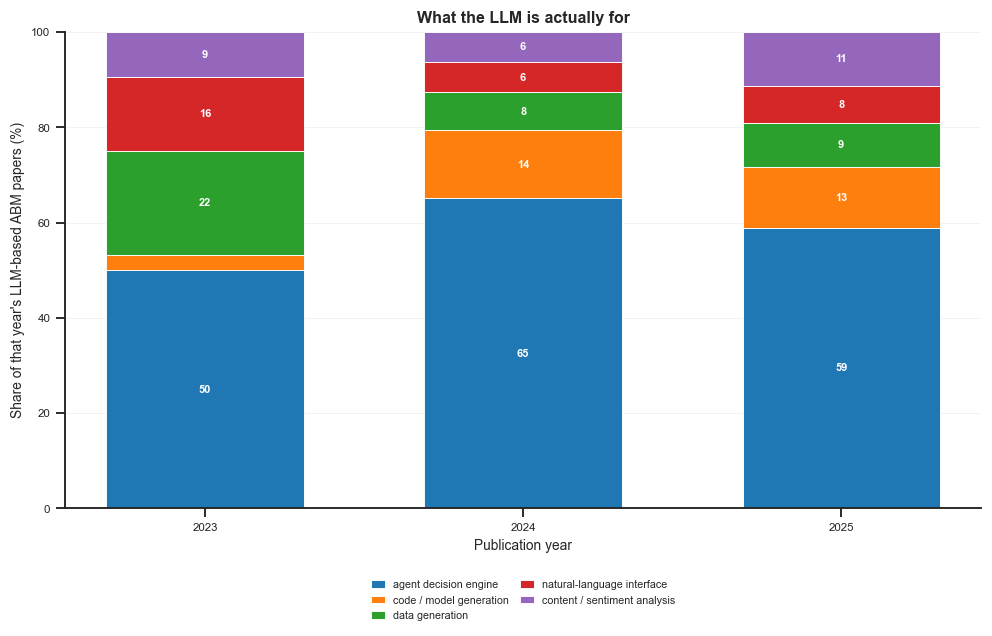

    -> 34_llm_role_composition_a
  [fig 32] 34_llm_role_composition -> 1 panels saved to figures/


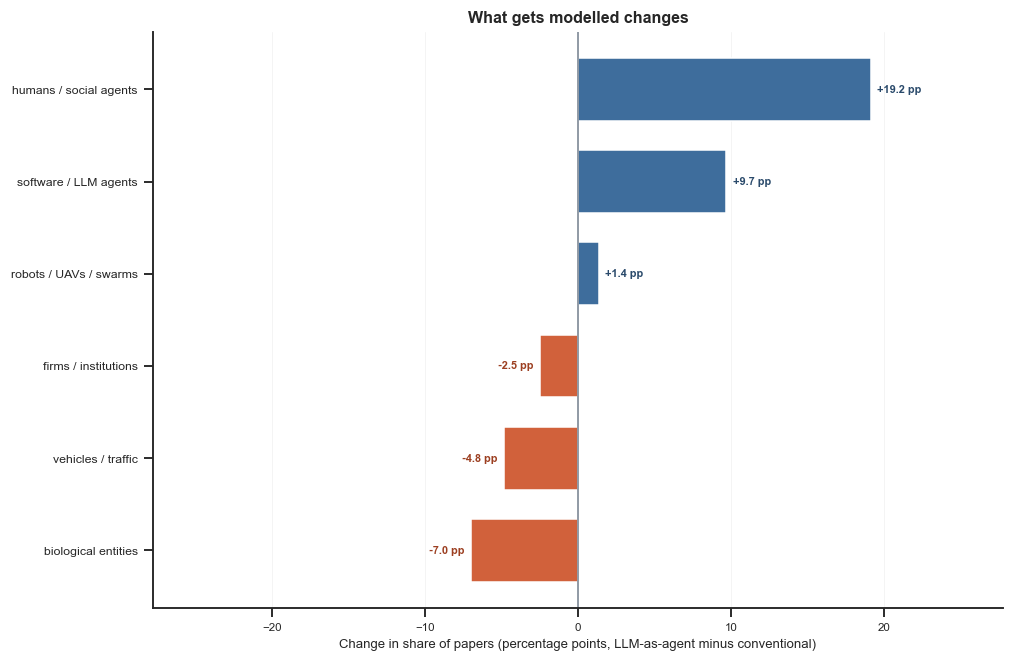

    -> 35_llm_agent_families_a
  [fig 33] 35_llm_agent_families -> 1 panels saved to figures/


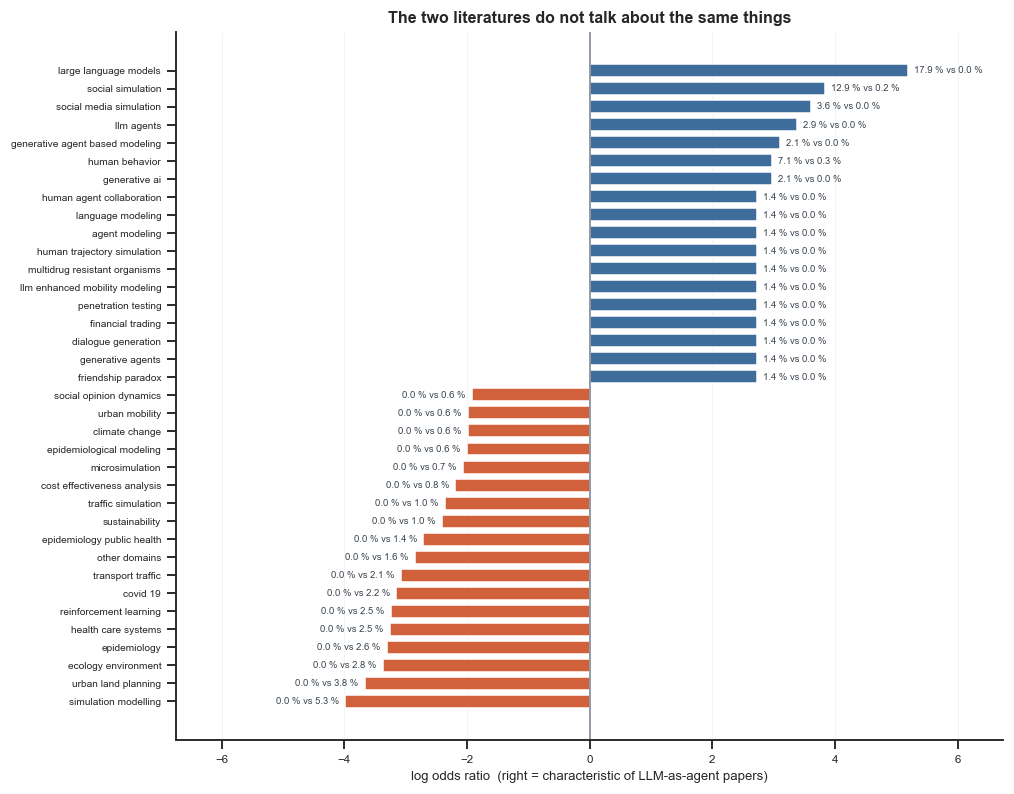

    -> 36_llm_vocabulary_shift_a
  [fig 34] 36_llm_vocabulary_shift -> 1 panels saved to figures/


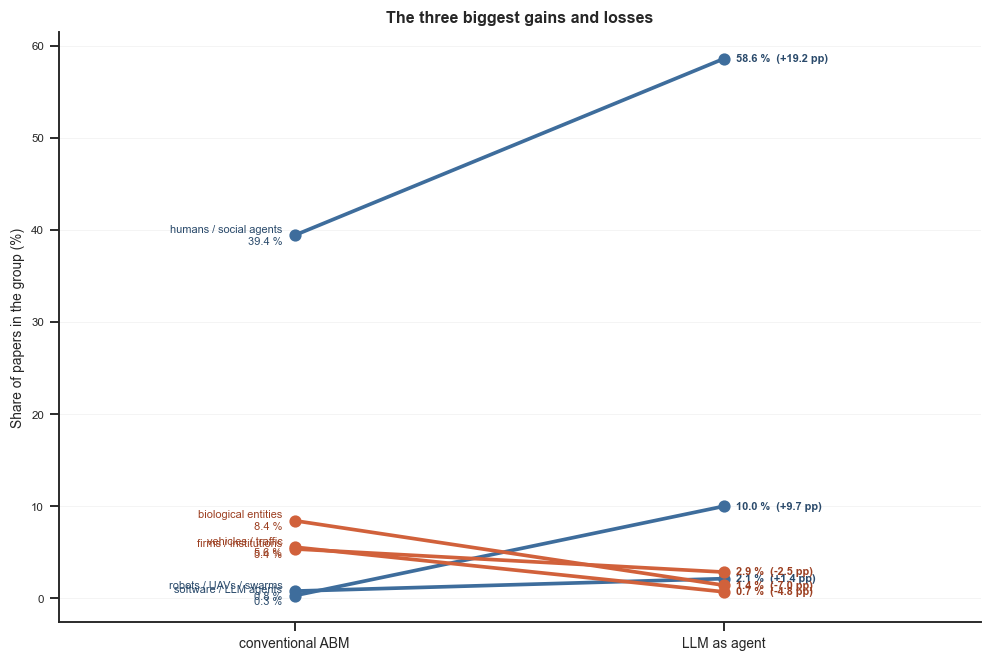

    -> 37_llm_content_shifts_a
  [fig 35] 37_llm_content_shifts -> 1 panels saved to figures/

HOW TO READ THIS
   supports: LLM-based ABM is a different KIND of agent-based modelling, not the same modelling
             done faster. The agents change (robots -> software agents), and the vocabulary
             moves from control and optimisation toward reasoning, language and social behaviour.
   the tool pathway is small: only 53 of 236 LLM papers (22.5 %) use the LLM for code or data
             generation. On this evidence the LLM has not yet become a general accelerator of
             conventional ABM practice; it has mostly become the object being modelled.
   does not support a causal claim, and does not measure quality: a changed vocabulary is not a
             better or worse one. Both groups come from the same retrieval and the same screen.
   measurement limits:
     * 'LLM = agent' vs 'LLM = tool' is stage 2's single role label; a paper doing both is
       assigned to t

In [45]:
# ------------------------------------------------------------------ 8b. does the LLM change the modelling?
# The question is whether the RESEARCH changes, not the sociology around it. The treatment group splits
# into two things that must not be pooled:
#
#     LLM = agent decision engine   -> the LLM is INSIDE the model; the agents think with it
#     LLM = code / data generation  -> the LLM is a TOOL; the model itself is conventional
#
# Pooling them would average "what ABM is about" together with "how ABM is written". Both are compared
# against conventional ABM from the same years.
WIN_LO = 2023
CW = abm[abm["year_num"].between(WIN_LO, LAST_YEAR)].copy()
CW["uses_llm"] = CW["llama_llm_has_llm"] == 1
_role = CW["llama_llm_role"].astype(str)
CW["role_agent"] = CW["uses_llm"] & _role.str.contains("Agent Decision", case=False, na=False)
CW["role_tool"] = CW["uses_llm"] & _role.str.contains("Code / Model Generation|Data Generation",
                                                      case=False, na=False)
CW["role_nlp"] = CW["uses_llm"] & _role.str.contains("Natural Language Interface|Content / Sentiment",
                                                     case=False, na=False)
_n_llm = int(CW["uses_llm"].sum())
print(f"window {WIN_LO}-{LAST_YEAR}: {len(CW):,} ABM papers, {_n_llm:,} use an LLM "
      f"({100 * _n_llm / len(CW):.2f} %)")
print(f"   LLM as agent decision engine : {int(CW['role_agent'].sum()):>5,} "
      f"({100 * CW['role_agent'].sum() / _n_llm:.1f} % of LLM papers)")
print(f"   LLM for code / data          : {int(CW['role_tool'].sum()):>5,} "
      f"({100 * CW['role_tool'].sum() / _n_llm:.1f} %)")
print(f"   LLM as NLP interface         : {int(CW['role_nlp'].sum()):>5,} "
      f"({100 * CW['role_nlp'].sum() / _n_llm:.1f} %)")

# ---------------------------------------------------------------- figure 1: what is the LLM FOR?
ROLES = {
    "agent decision engine": r"Agent Decision",
    "code / model generation": r"Code / Model Generation",
    "data generation": r"Data Generation",
    "natural-language interface": r"Natural Language Interface",
    "content / sentiment analysis": r"Content / Sentiment",
}
_years = [y for y in (2023, 2024, 2025) if (CW["year_num"] == y).any()]
_role_mix = pd.DataFrame(
    {name: [100 * CW.loc[(CW["year_num"] == y) & CW["uses_llm"], "llama_llm_role"]
            .astype(str).str.contains(pat, case=False, na=False).mean() for y in _years]
     for name, pat in ROLES.items()}, index=_years)

# ---------------------------------------------------------------- figure 2/4: what are the agents?
AGENT_FAMILIES = {
    "robots / UAVs / swarms": r"robot|uav|drone|unmanned|swarm",
    "humans / social agents": r"citizen|individual|human|pedestrian|household|patient|voter|consumer|student|social media",
    "software / LLM agents": r"software|llm|language model|chatbot|virtual agent|intelligent agent",
    "vehicles / traffic": r"vehicle|\bcar\b|truck|bus|traffic|vessel|aircraft",
    "firms / institutions": r"firm|bank|compan|institution|government|market|trader|supplier",
    "biological entities": r"\bcell\b|organism|bacteri|virus|gene|protein|species|animal",
}
_cmp = {
    "conventional ABM": CW[~CW["uses_llm"]],
    "LLM = tool": CW[CW["role_tool"] & ~CW["role_agent"]],
    "LLM = agent": CW[CW["role_agent"] & ~CW["role_tool"]],
}
_ag = pd.DataFrame(
    {name: [100 * sub["llama_agent_types"].astype(str).str.lower()
            .str.contains(pat, regex=True, na=False).mean() for pat in AGENT_FAMILIES.values()]
     for name, sub in _cmp.items()}, index=list(AGENT_FAMILIES))

print("\nagent families (% of papers in each group):")
print(_ag.round(1).to_string())

# ---------------------------------------------------------------- figure 3: characteristic vocabulary
def _terms(frame):
    c = Counter()
    for lst in frame["llama_topic_keywords"]:
        c.update(canon_list(lst, "llama_topic_keywords"))
    return c


_a, _n = _cmp["LLM = agent"], _cmp["conventional ABM"]
_pa, _pn = pd.Series(_terms(_a)) / len(_a), pd.Series(_terms(_n)) / len(_n)
_vocab = pd.DataFrame({"llm": _pa, "conv": _pn}).fillna(0.0)
_vocab = _vocab[(_vocab["llm"] + _vocab["conv"]) >= 0.004]
_vocab["lor"] = np.log((_vocab["llm"] + 0.001) / (_vocab["conv"] + 0.001))
_vocab["total"] = _vocab["llm"] + _vocab["conv"]
TOP_LOR = 18
_lift = pd.concat([_vocab.nlargest(TOP_LOR, "lor"), _vocab.nsmallest(TOP_LOR, "lor")])
print(f"\ntopic keywords compared: {len(_vocab):,}; showing {len(_lift)} most characteristic")
print("characteristic of LLM-as-agent papers:")
for k, r in _vocab.nlargest(8, "lor").iterrows():
    print(f"   {r['lor']:+5.2f}  LLM {100 * r['llm']:5.2f} %  conv {100 * r['conv']:5.2f} %  {k[:52]}")
print("characteristic of conventional ABM papers:")
for k, r in _vocab.nsmallest(8, "lor").iterrows():
    print(f"   {r['lor']:+5.2f}  LLM {100 * r['llm']:5.2f} %  conv {100 * r['conv']:5.2f} %  {k[:52]}")

# ================================================================ figure 1: stacked bar of roles
fig, ax = plt.subplots(figsize=(9.2, 6.0))
_bottom = np.zeros(len(_role_mix))
for _name, _col in zip(_role_mix.columns, sns.color_palette("tab10", len(_role_mix.columns))):
    ax.bar(_role_mix.index.astype(str), _role_mix[_name], bottom=_bottom, label=_name,
           color=_col, edgecolor="white", width=0.62, linewidth=0.6)
    for _i, _v in enumerate(_role_mix[_name]):
        if _v >= 4:
            ax.annotate(f"{_v:.0f}", xy=(_i, _bottom[_i] + _v / 2), ha="center", va="center",
                        fontsize=7.2, color=text_on(_col), fontweight="bold")
    _bottom = _bottom + _role_mix[_name].to_numpy()
ax.set_ylim(0, 100)
ax.set_ylabel("Share of that year's LLM-based ABM papers (%)", fontsize=9)
ax.set_xlabel("Publication year", fontsize=9)
ax.set_title("What the LLM is actually for", fontsize=10.5, fontweight="bold")
ax.tick_params(labelsize=7.5)
ax.grid(axis="x", visible=False)
ax.legend(fontsize=7, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.13),
          frameon=False, handlelength=1.3, columnspacing=1.0)
for _i, _y in enumerate(_years):
    ax.annotate(f"n={int(((CW['year_num'] == _y) & CW['uses_llm']).sum()):,}",
                xy=(_i, 101), ha="center", fontsize=7, color="#5A6672")
fig.tight_layout()
save(fig, "34_llm_role_composition")

# ================================================================ figure 2: diverging bar of agent families
_d = _ag.copy()
_d["delta"] = _d["LLM = agent"] - _d["conventional ABM"]
_d = _d.sort_values("delta")
fig, ax = plt.subplots(figsize=(9.4, 6.2))
_cols = [C["abm"] if v > 0 else C["llm"] for v in _d["delta"]]
_bars = ax.barh(range(len(_d)), _d["delta"], color=_cols, edgecolor="white", height=0.68)
for _i, (_, r) in enumerate(_d.iterrows()):
    _off = 0.6 if r["delta"] >= 0 else -0.6
    ax.annotate(f"{r['delta']:+.1f} pp", xy=(r["delta"], _i), xytext=(4 if r["delta"] >= 0 else -4, 0),
                textcoords="offset points", va="center",
                ha="left" if r["delta"] >= 0 else "right", fontsize=7.2,
                color=C["abm_dark"] if r["delta"] >= 0 else C["llm_dark"], fontweight="bold")
ax.axvline(0, color=C["grey"], lw=1.2)
ax.set_yticks(range(len(_d)))
ax.set_yticklabels(list(_d.index), fontsize=8)
ax.set_xlabel("Change in share of papers (percentage points, LLM-as-agent minus conventional)",
              fontsize=8.6)
ax.set_title("What gets modelled changes", fontsize=10.5, fontweight="bold")
ax.tick_params(axis="x", labelsize=7.5)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", alpha=0.22, linewidth=0.6)
_span = float(_d["delta"].abs().max())
ax.set_xlim(-_span * 1.45, _span * 1.45)
fig.tight_layout()
save(fig, "35_llm_agent_families")

# ================================================================ figure 3: characteristic vocabulary
# A single diverging bar chart keyed on the log odds ratio. There are always more than 151 candidate
# terms and the two selections can overlap, so a heatmap keyed on the term index risks duplicate rows;
# one bar per term avoids that entirely and reads more directly.
_sel = pd.concat([_vocab.nlargest(TOP_LOR, "lor"), _vocab.nsmallest(TOP_LOR, "lor")])
_sel = _sel[~_sel.index.duplicated(keep="first")].sort_values("lor")
fig, ax = plt.subplots(figsize=(9.4, 7.4))
_y = np.arange(len(_sel))
_cols = [C["llm"] if v < 0 else C["abm"] for v in _sel["lor"]]
ax.barh(_y, _sel["lor"], color=_cols, edgecolor="white", height=0.72)
ax.axvline(0, color=C["grey"], lw=1.2)
ax.set_yticks(_y)
ax.set_yticklabels([wrap(k, 34) for k in _sel.index], fontsize=6.6)
ax.set_xlabel("log odds ratio  (right = characteristic of LLM-as-agent papers)", fontsize=8.6)
ax.set_title("The two literatures do not talk about the same things",
             fontsize=10.5, fontweight="bold")
ax.tick_params(axis="x", labelsize=7.5)
ax.grid(axis="y", visible=False)
ax.grid(axis="x", alpha=0.22, linewidth=0.6)
_lim = float(_sel["lor"].abs().max()) * 1.30
ax.set_xlim(-_lim, _lim)
for _i, (_, r) in enumerate(_sel.iterrows()):
    _side = 4 if r["lor"] >= 0 else -4
    ax.annotate(f"{100 * r['llm']:.1f} % vs {100 * r['conv']:.1f} %",
                xy=(r["lor"], _i), xytext=(_side, 0), textcoords="offset points", va="center",
                ha="left" if r["lor"] >= 0 else "right", fontsize=6.2, color="#3A444E")
fig.tight_layout()
save(fig, "36_llm_vocabulary_shift")

# ================================================================ figure 4: the biggest shifts side by side
_show = pd.concat([_d.tail(3), _d.head(3)])
_show = _show.assign(conv_share=[_ag.loc[i, "conventional ABM"] for i in _show.index],
                     llm_share=[_ag.loc[i, "LLM = agent"] for i in _show.index])
fig, ax = plt.subplots(figsize=(9.2, 6.2))
for _i, (name, r) in enumerate(_show.iterrows()):
    ax.plot([0, 1], [r["conv_share"], r["llm_share"]], marker="o", ms=7, lw=2.4,
            color=C["abm"] if r["delta"] > 0 else C["llm"])
    ax.annotate(f"{name}\n{r['conv_share']:.1f} %", xy=(0, r["conv_share"]), xytext=(-8, 0),
                textcoords="offset points", ha="right", va="center", fontsize=7.2,
                color=C["abm_dark"] if r["delta"] > 0 else C["llm_dark"])
    ax.annotate(f"{r['llm_share']:.1f} %  ({r['delta']:+.1f} pp)", xy=(1, r["llm_share"]),
                xytext=(8, 0), textcoords="offset points", ha="left", va="center", fontsize=7.2,
                color=C["abm_dark"] if r["delta"] > 0 else C["llm_dark"], fontweight="bold")
ax.set_xlim(-0.55, 1.60)
ax.set_xticks([0, 1])
ax.set_xticklabels(["conventional ABM", "LLM as agent"], fontsize=9)
ax.set_ylabel("Share of papers in the group (%)", fontsize=9)
ax.set_title("The three biggest gains and losses", fontsize=10.5, fontweight="bold")
ax.tick_params(axis="y", labelsize=7.5)
ax.grid(axis="x", visible=False)
ax.grid(axis="y", alpha=0.22, linewidth=0.6)
fig.tight_layout()
save(fig, "37_llm_content_shifts")

# ---------------------------------------------------------------- what this does and does not show
print("\nHOW TO READ THIS")
print("   supports: LLM-based ABM is a different KIND of agent-based modelling, not the same modelling")
print("             done faster. The agents change (robots -> software agents), and the vocabulary")
print("             moves from control and optimisation toward reasoning, language and social behaviour.")
print("   the tool pathway is small: only %d of %d LLM papers (%.1f %%) use the LLM for code or data"
      % (int(CW["role_tool"].sum()), _n_llm, 100 * CW["role_tool"].sum() / _n_llm))
print("             generation. On this evidence the LLM has not yet become a general accelerator of")
print("             conventional ABM practice; it has mostly become the object being modelled.")
print("   does not support a causal claim, and does not measure quality: a changed vocabulary is not a")
print("             better or worse one. Both groups come from the same retrieval and the same screen.")
print("   measurement limits:")
print("     * 'LLM = agent' vs 'LLM = tool' is stage 2's single role label; a paper doing both is")
print("       assigned to the agent group, so the tool pathway is a lower bound")
print("     * agent-type and topic labels are stage-3 free text, so a real shift could be partly a")
print("       labelling shift; the abstract-level check would be the way to rule that out")
print("     * 2025 is an incomplete publication year")

## 11. Conclusions

1. **The retrieved corpus is majority-negative for ABM.** Only **27.6 %** of the 322,742 records pass
   stage-1 screening (**88,954** papers); 72.4 % are screened out. The refreshed corpus contains no
   model/parse failures at all, so no rate here is diluted by records that were silently dropped.

2. **Agent-based output has grown steadily for three decades.** ABM-positive papers compound at about
   **13.4 %/yr between 2000 and 2025**, reaching **9,516 papers in 2025** and a **34.7 % share** of
   that year's retrieved records, up from 19.7 % in 2000. The growth rate is quoted from 2000 because
   1990 holds only five ABM-positive papers.

3. **LLM adoption is a discontinuity, not a trend.** LLM-based ABM papers go
   **24 (2022) → 116 (2023) → 523 (2024) → 1,661 (2025)**, and the adoption share moves from
   **0.33 % to 17.5 %** in three years. The break sits immediately after the release of ChatGPT in
   late 2022. Over the whole corpus the practice is still a minority: **4.85 %** of ABM papers
   (4,318 of 88,954).

4. **LLMs are used mainly as agent cognition.** The dominant mapped role is *agent decision-making*,
   followed by *simulation environment* and *multi-agent orchestration*; use as a coding or
   data-generation assistant is comparatively rare.

5. **Adoption is uneven across domains and tracks the methodological frontier.** Penetration is
   highest in computing-adjacent and control/robotics-adjacent domains and lowest in the
   long-established empirical ones, even where those domains are large.

6. **The dominant measurement limitation is free-text drift in stage 3.** `primary_domain`,
   `agent_types` and `secondary_topics` are near-unique strings (17,127 / 52,227 / 63,824 distinct
   values for 88,954 papers), which makes raw frequency counts nearly uninformative. Any downstream
   analysis must either normalise these fields or work at the level of enumerated components, as done
   in Sections 6, 6c and 7.

7. **The social structure of the field is changing faster than its methods.** Teams are growing,
   single-authored ABM work is declining, and multi-institution and multi-country collaboration rise
   steadily across 2000-2025, while the reported methodology stays overwhelmingly agent-based: the
   agent-based / multi-agent simulation family covers **83.5 % of ABM papers over 2020-2025** (mean
   of yearly shares) and rises across that window from 78.4 % to **89.3 % in 2025**. Methodology is a
   multi-label field, so these shares are prevalences rather than a partition, and the small
   remainder often carries only a generic "Simulation" label.

8. **LLM-based ABM is a larger-team, more nationally-focused activity.** Papers that use an LLM
   average **5.50 authors against 3.85** for conventional ABM, yet only **14.6 % of them are
   multi-country against 27.2 %** of conventional ABM. The natural reading is that this is a young
   literature in which early work is concentrated in a few well-resourced national groups rather than
   distributed across international consortia - a pattern that should be re-tested as the field ages.

9. **Geographic volume does not explain LLM adoption.** Two countries dominate output (China and the
   United States between them account for a large share of all country tags), yet LLM penetration
   varies several-fold across the top-20 countries (**0.5 %-5.9 %**) and correlates essentially zero
   with log volume (**r = +0.02**). Adoption tracks research culture and sub-field mix, not the size of
   a country's ABM output.

10. **Two data-quality actions follow from the audit.** The 2026 records are excluded from all time
    series because the harvest year is incomplete; and 11,556 records in the cache are dated after
    2025, so any new time series must apply the same cut-off. Two lower-priority notes: 38 ABM papers
    carry no author metadata, so authorship rates should be reported against the records that do; and
    80,096 of 88,954 ABM papers (90.0 %) carry a country tag, so geographic shares are computed
    against tagged papers rather than the full corpus.

In [46]:
# ================================================================ manuscript number pack
# Everything the write-up quotes, printed from THIS notebook's own variables. The domain taxonomy is
# defined in the canonicalisation cell above, and re-deriving it in a side script produced a different
# largest domain, so the prose takes its numbers from here and nowhere else.
print("=" * 92)
print("MANUSCRIPT NUMBERS")
print("=" * 92)

print("\n[SCOPE]")
print(f"  screened records            : {len(df):,}")
# NOTE: the scope block redefines df['llama_abm_is_abm'] to the classical-ABM verdict, so this line
# reports the post-screen count. The stage-1 figure (88,954) is printed by the loading cell.
print(f"  classical-ABM positive      : {len(abm):,}   ({100 * len(abm) / len(df):.2f} % of corpus)")
print(f"  LLM-positive (to {LAST_YEAR})   : {int(LLM_WINDOW.sum()):,}"
      f"   ({100 * int(LLM_WINDOW.sum()) / len(abm):.2f} % of ABM)")
print(f"  ABM without an LLM (to {LAST_YEAR})"
      f" : {int(((abm['llama_llm_has_llm'] == 0) & (abm['year_num'] <= LAST_YEAR)).sum()):,}")

print("\n[CORPUS OVER TIME]")
_y = abm[abm["year_num"].between(1970, LAST_YEAR)].groupby("year_num").size()
for _yy in (2000, 2010, 2015, 2020, 2025):
    if _yy in _y.index:
        print(f"  {_yy}: {int(_y[_yy]):>6,} ABM papers")

print("\n[MULTI-AGENT VOCABULARY REMOVED FROM THE TERM TABLES]")
for _col, _lab in [("llama_topic_keywords", "topic keywords"),
                   ("llama_secondary_topics", "secondary topics"),
                   ("llama_abm_triggered_keywords", "trigger words")]:
    _all, _hit = Counter(), Counter()
    for _v in abm[_col]:
        for _k in to_list(_v):
            _k = str(_k).strip().lower()
            if not _k:
                continue
            _all[_k] += 1
            if MA_VOCAB_RE.search(_k):
                _hit[_k] += 1
    _t, _h = sum(_all.values()), sum(_hit.values())
    print(f"  {_lab:<18} {_h:>6,} of {_t:>7,} occurrences removed"
          f" ({100 * _h / _t:5.2f} %), {len(_hit):>3} distinct terms")

print("\n[AGENT TYPES]")
for _k, _v in agent_series.items():
    print(f"  {_v:>6,}  {100 * _v / len(abm):5.2f} %  {_k}")

print("\n[LLM ADOPTION BY YEAR]")
_t = (abm[abm["year_num"].between(1990, LAST_YEAR)]
      .groupby("year_num")["llama_llm_has_llm"].agg(["sum", "count"]))
_t = _t[_t["count"] >= 50]
for _yy, _r in _t.loc[2018:].iterrows():
    print(f"  {int(_yy)}: {int(_r['sum']):>3} of {int(_r['count']):>6,}  ="
          f"  {100 * _r['sum'] / _r['count']:5.2f} %")

print("\n[LLM FUNCTIONAL ROLES]")
for _k, _v in hero.items():
    print(f"  {_v:>6,}  {100 * _v / len(llm_pos):5.1f} %  {_k}")

print("\n[DOMAIN x LLM PENETRATION]")
try:
    for _k, _r in dom_stats.iterrows():
        print(f"  {_r['papers']:>6,} papers | {int(_r['llm']):>3} LLM |"
              f" {_r['share']:5.2f} %  {_k}")
except NameError:
    print("  dom_stats unavailable")

print("\n[DOMAIN x ROLE  (counts; row n in the last column)]")
try:
    _tot = ct.sum(axis=1)
    for _d in ct.index:
        _cells = "  ".join(f"{_c}:{int(ct.loc[_d, _c])}" for _c in ct.columns)
        print(f"  n={int(_tot[_d]):>3}  {_d}")
        print(f"         {_cells}")
except NameError:
    print("  ct unavailable")

print("\n[ROLE COMPOSITION BY YEAR]")
_cty = (llm_pos[llm_pos["year_num"] >= 2022]
        .groupby(["year_num", "role_tag"]).size().unstack(fill_value=0))
print(_cty.to_string())

print("\n[TOP 20 COUNTRIES  any | first | share of ABM corpus]")
try:
    for _c, _r in ctry.head(20).iterrows():
        print(f"  {country_label(_c):<22} {int(_r['any']):>6,} | {int(_r['first']):>6,} |"
              f" {_r['share']:5.2f} %")
except NameError:
    print("  ctry unavailable")

print("\n[LLM vs CONVENTIONAL, 2023-2025]")
_w = llm_pos[llm_pos["year_num"].between(2023, LAST_YEAR)]
_wi = abm[abm["year_num"].between(2023, LAST_YEAR)]
print(f"  {len(_wi):,} ABM papers in window, {len(_w):,} use an LLM"
      f" ({100 * len(_w) / len(_wi):.2f} %)")
for _k, _v in _w["role_tag"].value_counts().items():
    print(f"    {_v:>4}  {100 * _v / len(_w):5.1f} %  {_k}")

print("\n[COUNTRY SHARE OVER TIME  (top 8, any-author)]")
_top8 = [c for c in ctry.head(8).index]
for _yy in (2010, 2015, 2020, 2025):
    _docs = list(abm.loc[abm["year_num"] == _yy, "doc_id"])
    _tot = sum(1 for _d in _docs if (AUTHOR_META.get(_d) or {}).get("c"))
    _bits = []
    for _c in _top8:
        _hit = sum(1 for _d in _docs if _c in ((AUTHOR_META.get(_d) or {}).get("c") or []))
        _bits.append(f"{_c} {100 * _hit / _tot:4.1f}%" if _tot else f"{_c} n/a")
    print(f"  {_yy}  n={_tot:>5,}   " + "  ".join(_bits))

print("\n[DOMAIN CO-OCCURRENCE]")
try:
    _dt = abm["domain_tags"].apply(len)
    print(f"  papers with >= 1 domain tag : {int(_dt.gt(0).sum()):,} / {len(abm):,}")
    print(f"  mean domains per paper      : {_dt.mean():.2f}")
    print(f"  interdisciplinary (2+)      : {int(_dt.ge(2).sum()):,}"
          f" ({100 * _dt.ge(2).mean():.1f} %)")
except (KeyError, NameError):
    print("  domain_tags unavailable")

print("\n[INSTITUTION TYPES]")
try:
    for _k, _v in itypes.head(10).items():
        print(f"  {_v:>7,}  {_k}")
except NameError:
    print("  itypes unavailable")


MANUSCRIPT NUMBERS

[SCOPE]
  screened records            : 29,139
  classical-ABM positive      : 29,139   (100.00 % of corpus)
  LLM-positive (to 2025)   : 236   (0.81 % of ABM)
  ABM without an LLM (to 2025) : 24,147

[CORPUS OVER TIME]
  2000:    134 ABM papers
  2010:    753 ABM papers
  2015:  1,277 ABM papers
  2020:  1,719 ABM papers
  2025:  2,495 ABM papers

[MULTI-AGENT VOCABULARY REMOVED FROM THE TERM TABLES]
  topic keywords        317 of  80,288 occurrences removed ( 0.39 %),  43 distinct terms


  secondary topics      230 of  65,963 occurrences removed ( 0.35 %),  36 distinct terms
  trigger words      10,971 of  53,613 occurrences removed (20.46 %),  73 distinct terms

[AGENT TYPES]
  12,005  41.20 %  Individuals / households
   8,136  27.92 %  Network nodes / generic
   6,510  22.34 %  Patients / biological
   2,080   7.14 %  Firms / institutions
   1,925   6.61 %  Vehicles
     365   1.25 %  Software / LLM agents
     322   1.11 %  Robots / swarms

[LLM ADOPTION BY YEAR]
  2018: -224 of  1,560  =  -14.36 %
  2019: -240 of  1,618  =  -14.83 %
  2020: -231 of  1,719  =  -13.44 %
  2021: -297 of  2,201  =  -13.49 %
  2022: -359 of  2,314  =  -15.51 %
  2023: -305 of  2,136  =  -14.28 %
  2024: -368 of  2,292  =  -16.06 %
  2025: -691 of  2,495  =  -27.70 %

[LLM FUNCTIONAL ROLES]
     140   59.3 %  Agent decision-making
      28   11.9 %  Code generation / execution
      25   10.6 %  Data generation / annotation
      22    9.3 %  Evaluation / analysis
      20    8.5 %  Nat

## 被建模对象的逐年变化（RQ2 补充）

见本节代码单元；实现位于 `tools/` 下对应脚本，命令行可直接复算。


In [47]:
# ---- RQ2: agent type 的年度分布与趋势检验 ----
# 图5 只有总体构成，看不出研究对象随时间怎么转移。这里补：
#   1) 7 个主体族的逐年占比
#   2) 逐篇 logistic 回归 + 似然比检验，自动判定每族是升还是降（不靠目视读图）
#   3) 2023—2025 内部 LLM 论文 vs 其他论文的主体构成差异
# 实现放在 tools/rq2_agenttype_yearly.py。
import sys
if "tools" not in sys.path:
    sys.path.insert(0, "tools")
import rq2_agenttype_yearly as rq2
rq2.main()


RQ2 —— agent type 逐年变化（经典 ABM，1996—2025，n=28,268）
可解析出主体类型的论文 25,479 / 28,268 = 90.1%

各族占当年论文的百分比（一篇可提及多族）：
year       n      Human/HH   Patient/Bio       Vehicle   Robot/Swarm      Software     Firm/Inst  Node/Generic
1996      77         27.3%         26.0%          5.2%          3.9%          6.5%          1.3%         39.0%
1997     103         20.4%         26.2%          7.8%          2.9%          6.8%          2.9%         35.0%
1998      95         20.0%         22.1%          1.1%          1.1%          5.3%          8.4%         47.4%
1999     107         23.4%         25.2%          2.8%          2.8%          7.5%          8.4%         30.8%
2000     134         20.9%         23.1%          4.5%          3.0%         13.4%          5.2%         32.8%
2001     183         18.0%         23.5%          3.8%          1.6%          6.6%         10.4%         32.8%
2002     205         25.9%         22.0%          2.9%          1.5%          6.8%         10.2%         37.1%
200


figure -> 38_agent_types_over_time.png

saved: agenttype_yearly_share.csv, agenttype_trend_test.csv


In [48]:
# [dump] 主题桶计数导出
# 供正文表 2 使用：按 TOPIC_RULES 统计每个主题桶的篇数与占比
try:
    _src = abm if "abm" in dir() else df
    _b = _src.apply(lambda r: topic_of(r.get("llama_primary_domain"),
                                       r.get("llama_topic_category"),
                                       r.get("llama_topic_keywords"),
                                       r.get("llama_secondary_topics")), axis=1)
    _t = _b.value_counts()
    _out = _b.to_frame("bucket")
    _out.to_csv(FIG_DIR / "topic_bucket_assignments.csv", encoding="utf-8-sig")
    _t.to_csv(FIG_DIR / "topic_bucket_counts.csv", encoding="utf-8-sig",
              header=["papers"])
    print("topic buckets:", len(_t), "| total:", int(_t.sum()))
    print(_t.to_string())
except Exception as e:
    print("dump failed:", type(e).__name__, e)


topic buckets: 17 | total: 29139
epidemiology_public_health    7271
simulation_modelling          4986
ecology_environment           4564
transport_traffic             2852
social_opinion_dynamics       2486
urban_land_planning           1953
swarm_robotics                1656
policy_disaster_response       970
other_domains                  547
renewable_energy_grid          538
reinforcement_learning         488
health_care_systems            288
economics_finance              246
optimisation_algorithms        149
control_unmanned_systems        78
networks_communication          35
energy_systems                  32


In [49]:
# [dump] 构成图数据导出
try:
    import pandas as _pd
    _pd.Series(dict(_sub_all)).sort_values(ascending=False).rename("mentions").to_csv(
        FIG_DIR / "composition_subtopics.csv", encoding="utf-8-sig")
    _pd.Series(dict(agent_counter)).sort_values(ascending=False).rename("papers").to_csv(
        FIG_DIR / "composition_agent_families.csv", encoding="utf-8-sig")
    print("composition dumps written:",
          int(sum(_sub_all.values())), "sub-topic mentions,",
          int(sum(agent_counter.values())), "agent-family mentions")
except Exception as e:
    print("composition dump failed:", type(e).__name__, e)


composition dumps written: 65733 sub-topic mentions, 31343 agent-family mentions
